In [7]:
import glob
from Bio import SeqIO
from Bio.Seq import Seq
import os
import re
import pandas as pd
from collections import defaultdict

# Xueling's 4 envs

### calculate performance for "all10folds_of_best_repeat"

#### excluding tie cases

In [12]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_4_envs/prediction_results")
gt_excel_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_new_data_pred_vs_gt_labels.xlsx")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "Xueling_4_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Virus name mapping from prediction files to GT file
# ------------------------------------------------------------------------------
virus_name_mapping = {
    '02A1.CM.2004.T257_31.EU513185': 'CRF02_AG_257',
    '02_AG.CM.2004.271.EU513197': 'CRF02_AG_271', 
    '02_AG.CI.1999.928_28.EU513199': 'CRF02_AG_928',
    'B.US.1999.AD17.GU331254': 'AD17 (B)'
}

# ------------------------------------------------------------------------------
# 3) Load ground-truth from Excel file
# ------------------------------------------------------------------------------
print("Loading ground truth data from Excel file...")
gt_df = pd.read_excel(gt_excel_file, sheet_name='pred_vs_gt')
gt_df = gt_df[['Antibody', 'Virus', 'Threshold', 'Experimental GT Label']].copy()

# Clean the GT Label column
gt_df['Experimental GT Label'] = gt_df['Experimental GT Label'].str.strip().str.lower()

print(f"Loaded ground truth data for {len(gt_df)} Antibody-Virus-Threshold pairs")
print(f"Unique antibodies in GT: {gt_df['Antibody'].nunique()}")
print(f"Unique viruses in GT: {gt_df['Virus'].nunique()}")
print(f"Unique thresholds in GT: {gt_df['Threshold'].nunique()}")
print(f"GT Label distribution: {gt_df['Experimental GT Label'].value_counts().to_dict()}")

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_xueling_4_envs_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0])  # Keep full virus ID
                    state = row['State'].strip()
                    
                    # Map the virus ID to the name used in GT file
                    mapped_virus = virus_name_mapping.get(virus_id, virus_id)
                    virus_predictions[mapped_virus].append(state)
                    
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")
print(f"Unique viruses in predictions: {pred_df['Virus'].nunique()}")

# Print which mapped viruses were found
found_mapped_viruses = set(pred_df['Virus']).intersection(set(virus_name_mapping.values()))
print(f"Mapped viruses found in predictions: {found_mapped_viruses}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with Ground Truth labels (including Threshold in the merge)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    gt_df,
    on=['Antibody', 'Virus', 'Threshold'],  # Now including Threshold in the merge
    how='inner'
)

print(f"After merging with GT: {len(merged)} rows")

# Rename the GT label column for consistency
merged = merged.rename(columns={'Experimental GT Label': 'GT Label'})

# ------------------------------------------------------------------------------
# 6) Calculate metrics (excluding tie cases) - MIXED ALL ANTIBODIES
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary (ensure consistent case)
merged_filtered['GT_bin'] = merged_filtered['GT Label'].str.strip().str.lower().map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].str.strip().str.lower().map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics - now grouped by Threshold only (all antibodies mixed together)
records = []
for thr in thresholds:
    # Get all data for this threshold across all antibodies
    threshold_data = merged_filtered[merged_filtered['Threshold'] == thr]
    
    if len(threshold_data) == 0:
        continue
        
    gt = threshold_data['GT_bin'].values
    pred = threshold_data['Pred_bin'].values

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')
    
    # Additional metrics
    precision = sk.precision_score(gt, pred, zero_division=0)
    recall = sk.recall_score(gt, pred, zero_division=0)
    f1 = sk.f1_score(gt, pred, zero_division=0)
    
    # Count statistics
    total_instances = len(gt)
    sensitive_predictions = sum(pred)
    resistant_predictions = total_instances - sensitive_predictions
    actual_sensitive = sum(gt)
    actual_resistant = total_instances - actual_sensitive

    records.append({
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Total_Instances': total_instances,
        'Predicted_Sensitive': sensitive_predictions,
        'Predicted_Resistant': resistant_predictions,
        'Actual_Sensitive': actual_sensitive,
        'Actual_Resistant': actual_resistant
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 7) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with voting stats
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (mixed antibodies per threshold)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"Results saved to: {output_xlsx}")
print(f"Final merged data: {len(merged)} rows")
print(f"Metrics calculated for {len(metrics_df)} thresholds (all antibodies mixed)")

# Print summary
print("\nMetrics Summary (All Antibodies Mixed):")
for _, row in metrics_df.iterrows():
    print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}, "
          f"F1={row['F1_Score']:.3f}, N={row['Total_Instances']}")

Loading ground truth data from Excel file...
Loaded ground truth data for 120 Antibody-Virus-Threshold pairs
Unique antibodies in GT: 10
Unique viruses in GT: 4
Unique thresholds in GT: 3
GT Label distribution: {'sensitive': 67, 'resistant': 53}
Total predictions collected: 120
Unique viruses in predictions: 4
Mapped viruses found in predictions: {'CRF02_AG_257', 'AD17 (B)', 'CRF02_AG_271', 'CRF02_AG_928'}
Merging predictions with ground truth data...
After merging with GT: 120 rows
Results saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_4_envs/prediction_results/Xueling_4_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx
Final merged data: 120 rows
Metrics calculated for 3 thresholds (all antibodies mixed)

Metrics Summary (All Antibodies Mixed):
Threshold 0.2: ACC=0.700, MCC=0.453, AUC=0.736, F1=0.667, N=40.0
Threshold 1.0: ACC=0.923, MCC=0.851, AUC=0.912, F1=0.936, N=39.0
Threshold 50.0: ACC=0.950, MCC=0.867, AUC=0.933, F1=0.967, N=40.0


/tmp/ipykernel_369006/3585817337.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].str.strip().str.lower().map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_369006/3585817337.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].str.strip().str.lower().map({'sensitive': 1, 'resistant': 0}).astype(int)


# Xueling's 30_Env_SGA_PCR data

## Preprocess and clean raw data files

In [2]:
# Set the directory path
directory = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR"

# Change to the directory (optional)
os.chdir(directory)

# Convert all .gb files to .fasta
gb_files = glob.glob("*.gb")

for gb_file in gb_files:
    fasta_file = gb_file.replace(".gb", ".fasta")
    
    # Convert using SeqIO
    count = SeqIO.convert(gb_file, "genbank", fasta_file, "fasta")
    print(f"Converted {gb_file} to {fasta_file} ({count} sequences)")

Converted 344_m1 n=20.gb to 344_m1 n=20.fasta (21 sequences)
Converted AD414_m2_env SGA align n=20.gb to AD414_m2_env SGA align n=20.fasta (20 sequences)
Converted 415_m2_m6_m9_m13.gb to 415_m2_m6_m9_m13.fasta (119 sequences)
Converted 360_m6_m13.gb to 360_m6_m13.fasta (65 sequences)
Converted 355_m2 n=19.gb to 355_m2 n=19.fasta (20 sequences)
Converted 342_m5 n=33.gb to 342_m5 n=33.fasta (34 sequences)
Converted 358_m2_m7 n=35.gb to 358_m2_m7 n=35.fasta (72 sequences)
Converted 414_m9 n=31.gb to 414_m9 n=31.fasta (31 sequences)


/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/Bio/GenBank/Scanner.py:1448: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AD344_m1_1       2607 bp\n'
  warnings.warn("Malformed LOCUS line found - is this "
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/Bio/GenBank/__init__.py:995: BiopythonParserWarning: GenBank TITLE line without REFERENCE line.
  warnings.warn("GenBank TITLE line without REFERENCE line.",
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/Bio/GenBank/Scanner.py:1152: BiopythonParserWarning: Blank line in sequence data
  warnings.warn("Blank line in sequence data",
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/Bio/GenBank/Scanner.py:1448: BiopythonParserWarning: Malformed LOCUS line found - is this correct?
:'LOCUS       AD344_m1_2       2607 bp\n'
  warnings.warn("Malformed LOCUS line found - is this "
/home/yujieq/.conda/envs/deep_learning/lib/python3.8

In [3]:
def rename_fasta_files(directory):
    """Rename fasta files by removing everything after ' n='"""
    os.chdir(directory)
    fasta_files = glob.glob("*.fasta")
    
    for fasta_file in fasta_files:
        if " n=" in fasta_file:
            new_filename = re.sub(r' n=.*\.fasta$', '.fasta', fasta_file)
            os.rename(fasta_file, new_filename)
            print(f"✓ Renamed {fasta_file} to {new_filename}")

def clean_sequence_ids(record):
    """Clean sequence IDs by removing blanks and bp information"""
    record.id = re.sub(r'\s+\d+bp$', '', record.id)
    record.description = ''
    return record

def replace_tildes_in_sequences(record):
    """Replace ~ with - in sequences"""
    # Convert Seq to string, replace, then convert back to Seq object
    seq_str = str(record.seq)
    seq_str = seq_str.replace('~', '-')
    record.seq = Seq(seq_str)
    return record

def process_fasta_sequences(directory):
    """Process all sequences in fasta files"""
    os.chdir(directory)
    fasta_files = glob.glob("*.fasta")
    
    for fasta_file in fasta_files:
        try:
            records = []
            for record in SeqIO.parse(fasta_file, "fasta"):
                record = clean_sequence_ids(record)
                record = replace_tildes_in_sequences(record)
                records.append(record)
            
            # Overwrite file with processed sequences
            SeqIO.write(records, fasta_file, "fasta")
            print(f"✓ Processed sequences in {fasta_file}")
            
        except Exception as e:
            print(f"✗ Error processing sequences in {fasta_file}: {str(e)}")

def main_processing(directory):
    """Main function to process all fasta files"""
    original_dir = os.getcwd()
    
    try:
        os.chdir(directory)
        
        # Step 1: Rename files
        rename_fasta_files(directory)
        
        # Step 2: Process sequences
        process_fasta_sequences(directory)
        
        print("✓ All processing completed successfully!")
                
    finally:
        os.chdir(original_dir)


In [5]:
main_processing(directory)

✓ Renamed 344_m1 n=20.fasta to 344_m1.fasta
✓ Renamed 342_m5 n=33.fasta to 342_m5.fasta
✓ Renamed 414_m9 n=31.fasta to 414_m9.fasta
✓ Renamed 358_m2_m7 n=35.fasta to 358_m2_m7.fasta
✓ Renamed AD414_m2_env SGA align n=20.fasta to AD414_m2_env SGA align.fasta
✓ Renamed 355_m2 n=19.fasta to 355_m2.fasta
✓ Processed sequences in 342_m5.fasta
✓ Processed sequences in 344_m1.fasta
✓ Processed sequences in 358_m2_m7.fasta
✓ Processed sequences in AD414_m2_env SGA align.fasta
✓ Processed sequences in 414_m9.fasta
✓ Processed sequences in 360_m6_m13.fasta
✓ Processed sequences in 358_m13.fasta
✓ Processed sequences in 355_m2.fasta
✓ Processed sequences in 342_m5_aa.fasta
✓ Processed sequences in 415_m2_m6_m9_m13.fasta
✓ Processed sequences in 360_m13.fasta
✓ All processing completed successfully!


In [6]:
def clean_aa_sequences(directory):
    """Clean amino acid sequences by removing gaps (-) and stop codons (*)"""
    os.chdir(directory)
    aa_files = glob.glob("*_aa.fasta")
    
    if not aa_files:
        print("No *_aa.fasta files found in the directory")
        return
    
    for aa_file in aa_files:
        try:
            records = []
            for record in SeqIO.parse(aa_file, "fasta"):
                # Convert sequence to string, remove gaps and stop codons
                seq_str = str(record.seq)
                seq_str = seq_str.replace('-', '').replace('*', '')
                
                # Update the sequence
                record.seq = Seq(seq_str)
                records.append(record)
            
            # Overwrite file with cleaned sequences
            SeqIO.write(records, aa_file, "fasta")
            print(f"✓ Cleaned sequences in {aa_file}")
            
        except Exception as e:
            print(f"✗ Error cleaning sequences in {aa_file}: {str(e)}")

def main_clean_aa_sequences(directory):
    """Main function to clean amino acid sequences"""
    original_dir = os.getcwd()
    
    try:
        os.chdir(directory)
        clean_aa_sequences(directory)
        print("✓ All amino acid sequence cleaning completed successfully!")
                
    finally:
        os.chdir(original_dir)


In [10]:
main_clean_aa_sequences(directory)

✓ Cleaned sequences in 414_m9_aa.fasta
✓ Cleaned sequences in 355_m2_aa.fasta
✓ Cleaned sequences in 360_m13_aa.fasta
✓ Cleaned sequences in AD414_m2_env_SGA_align_aa.fasta
✓ Cleaned sequences in 344_m1_aa.fasta
✓ Cleaned sequences in 358_m13_aa.fasta
✓ Cleaned sequences in 342_m5_aa.fasta
✓ Cleaned sequences in 358_m2_m7_aa.fasta
✓ Cleaned sequences in 360_m6_m13_aa.fasta
✓ Cleaned sequences in 415_m2_m6_m9_m13_aa.fasta
✓ All amino acid sequence cleaning completed successfully!


## Calculate majority votes from the 10-fold predictions (under cutoff 0.2, only 8 final models for CH01 and 9 final models for 8ANC195; under other thresholds, all 10 final models) & Compare with the single prediction with the majority vote

Generate comparison files for each antibody

Identify disagreements

In [22]:
thres = 0.2

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8"
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1 - 3BNC117
Processing 344_m1 - PGDM1400


In [2]:
thres = 1

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8"
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1 - 3BNC117
Processing 344_m1 - PGDM1400


In [3]:
thres = 50

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8"
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1 - 3BNC117
Processing 344_m1 - PGDM1400


## Same as previous - i.e. to calculate majority votes from the 10-fold predictions (under cutoff 0.2, only 8 final models for CH01 and 9 final models for 8ANC195; under other thresholds, all 10 final models)

BUT instead, we DON'T compare with the single prediction because we already found (from CATNAP 384 strains) that performance of "all10folds_of_best_repeat" better than "best1_of100"

In [4]:
thres = 50

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return majority voted results"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directory for this specific sample (only all10folds now)
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    expected_count = 10
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    if not all10_files:
        print(f"Error: No files found for {sample_name}-{antibody}")
        return []
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_results = []
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        total_votes = len(states)
        
        # Determine majority prediction
        if sensitive_count > resistant_count:
            majority_pred = 'sensitive'
            confidence = sensitive_count / total_votes
        elif resistant_count > sensitive_count:
            majority_pred = 'resistant'
            confidence = resistant_count / total_votes
        else:
            # Tie case
            majority_pred = 'sensitive/resistant'
            confidence = 0.5
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Majority_Prediction': majority_pred,
            'Sensitive_Votes': sensitive_count,
            'Resistant_Votes': resistant_count,
            'Total_Votes': total_votes,
            'Confidence': round(confidence, 3)
        }
        
        majority_results.append(instance_data)
    
    return majority_results

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8", 'VRC07-523-W54-LS.v3'
    ]
    
    # Process all samples and antibodies
    all_majority_results = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                majority_results = process_sample_predictions(sample, antibody, sample_output_dir)
                all_majority_results.extend(majority_results)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframe
    majority_df = pd.DataFrame(all_majority_results)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"majority_voted_results_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All majority voted results
        majority_df.to_excel(writer, sheet_name='All Majority Results', index=False)
        
        # Tab 2: Summary by sample and antibody
        if len(majority_df) > 0:
            summary_stats = majority_df.groupby(['Sample', 'Antibody']).agg({
                'Virus_ID': 'count',
                'Confidence': 'mean'
            }).reset_index()
            summary_stats.columns = ['Sample', 'Antibody', 'Total_Viruses', 'Average_Confidence']
            summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
            summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        
        # Tab 3: Prediction counts
        if len(majority_df) > 0:
            prediction_counts = majority_df.groupby(['Sample', 'Antibody', 'Majority_Prediction']).size().reset_index()
            prediction_counts.columns = ['Sample', 'Antibody', 'Prediction', 'Count']
            prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
    
    print(f"Saved majority voted results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    if len(majority_df) > 0:
        total_instances = len(majority_df)
        print(f"Total virus instances: {total_instances}")
        print(f"Total samples processed: {majority_df['Sample'].nunique()}")
        print(f"Total antibodies processed: {majority_df['Antibody'].nunique()}")
        
        # Print prediction distribution
        print("\n=== PREDICTION DISTRIBUTION ===")
        pred_dist = majority_df['Majority_Prediction'].value_counts()
        for pred, count in pred_dist.items():
            percentage = (count / total_instances) * 100
            print(f"{pred}: {count} ({percentage:.1f}%)")
        
        # Print average confidence
        avg_confidence = majority_df['Confidence'].mean()
        print(f"\nAverage confidence: {avg_confidence:.3f}")
        
        # Print sample and antibody counts
        print("\n=== VIRUS COUNTS BY SAMPLE ===")
        sample_counts = majority_df.groupby('Sample')['Virus_ID'].count().sort_values(ascending=False)
        for sample, count in sample_counts.items():
            print(f"{sample}: {count} viruses")
            
        print("\n=== VIRUS COUNTS BY ANTIBODY ===")
        antibody_counts = majority_df.groupby('Antibody')['Virus_ID'].count().sort_values(ascending=False)
        for antibody, count in antibody_counts.items():
            print(f"{antibody}: {count} viruses")
    else:
        print("No data processed.")

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 342_m5 - VRC07-523-W54-LS.v3
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1

In [5]:
thres = 1

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return majority voted results"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directory for this specific sample (only all10folds now)
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    expected_count = 10
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    if not all10_files:
        print(f"Error: No files found for {sample_name}-{antibody}")
        return []
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_results = []
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        total_votes = len(states)
        
        # Determine majority prediction
        if sensitive_count > resistant_count:
            majority_pred = 'sensitive'
            confidence = sensitive_count / total_votes
        elif resistant_count > sensitive_count:
            majority_pred = 'resistant'
            confidence = resistant_count / total_votes
        else:
            # Tie case
            majority_pred = 'sensitive/resistant'
            confidence = 0.5
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Majority_Prediction': majority_pred,
            'Sensitive_Votes': sensitive_count,
            'Resistant_Votes': resistant_count,
            'Total_Votes': total_votes,
            'Confidence': round(confidence, 3)
        }
        
        majority_results.append(instance_data)
    
    return majority_results

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8", 'VRC07-523-W54-LS.v3'
    ]
    
    # Process all samples and antibodies
    all_majority_results = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                majority_results = process_sample_predictions(sample, antibody, sample_output_dir)
                all_majority_results.extend(majority_results)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframe
    majority_df = pd.DataFrame(all_majority_results)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"majority_voted_results_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All majority voted results
        majority_df.to_excel(writer, sheet_name='All Majority Results', index=False)
        
        # Tab 2: Summary by sample and antibody
        if len(majority_df) > 0:
            summary_stats = majority_df.groupby(['Sample', 'Antibody']).agg({
                'Virus_ID': 'count',
                'Confidence': 'mean'
            }).reset_index()
            summary_stats.columns = ['Sample', 'Antibody', 'Total_Viruses', 'Average_Confidence']
            summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
            summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        
        # Tab 3: Prediction counts
        if len(majority_df) > 0:
            prediction_counts = majority_df.groupby(['Sample', 'Antibody', 'Majority_Prediction']).size().reset_index()
            prediction_counts.columns = ['Sample', 'Antibody', 'Prediction', 'Count']
            prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
    
    print(f"Saved majority voted results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    if len(majority_df) > 0:
        total_instances = len(majority_df)
        print(f"Total virus instances: {total_instances}")
        print(f"Total samples processed: {majority_df['Sample'].nunique()}")
        print(f"Total antibodies processed: {majority_df['Antibody'].nunique()}")
        
        # Print prediction distribution
        print("\n=== PREDICTION DISTRIBUTION ===")
        pred_dist = majority_df['Majority_Prediction'].value_counts()
        for pred, count in pred_dist.items():
            percentage = (count / total_instances) * 100
            print(f"{pred}: {count} ({percentage:.1f}%)")
        
        # Print average confidence
        avg_confidence = majority_df['Confidence'].mean()
        print(f"\nAverage confidence: {avg_confidence:.3f}")
        
        # Print sample and antibody counts
        print("\n=== VIRUS COUNTS BY SAMPLE ===")
        sample_counts = majority_df.groupby('Sample')['Virus_ID'].count().sort_values(ascending=False)
        for sample, count in sample_counts.items():
            print(f"{sample}: {count} viruses")
            
        print("\n=== VIRUS COUNTS BY ANTIBODY ===")
        antibody_counts = majority_df.groupby('Antibody')['Virus_ID'].count().sort_values(ascending=False)
        for antibody, count in antibody_counts.items():
            print(f"{antibody}: {count} viruses")
    else:
        print("No data processed.")

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 342_m5 - VRC07-523-W54-LS.v3
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1

In [6]:
thres = 0.2

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return majority voted results"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directory for this specific sample (only all10folds now)
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Xueling_30_Env_SGA_PCR_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    if not all10_files:
        print(f"Error: No files found for {sample_name}-{antibody}")
        return []
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_results = []
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        total_votes = len(states)
        
        # Determine majority prediction
        if sensitive_count > resistant_count:
            majority_pred = 'sensitive'
            confidence = sensitive_count / total_votes
        elif resistant_count > sensitive_count:
            majority_pred = 'resistant'
            confidence = resistant_count / total_votes
        else:
            # Tie case
            majority_pred = 'sensitive/resistant'
            confidence = 0.5
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Majority_Prediction': majority_pred,
            'Sensitive_Votes': sensitive_count,
            'Resistant_Votes': resistant_count,
            'Total_Votes': total_votes,
            'Confidence': round(confidence, 3)
        }
        
        majority_results.append(instance_data)
    
    return majority_results

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thres}"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
        "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
        "AD414_m2_env_SGA_align"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8", 'VRC07-523-W54-LS.v3'
    ]
    
    # Process all samples and antibodies
    all_majority_results = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample)
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                majority_results = process_sample_predictions(sample, antibody, sample_output_dir)
                all_majority_results.extend(majority_results)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframe
    majority_df = pd.DataFrame(all_majority_results)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"majority_voted_results_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All majority voted results
        majority_df.to_excel(writer, sheet_name='All Majority Results', index=False)
        
        # Tab 2: Summary by sample and antibody
        if len(majority_df) > 0:
            summary_stats = majority_df.groupby(['Sample', 'Antibody']).agg({
                'Virus_ID': 'count',
                'Confidence': 'mean'
            }).reset_index()
            summary_stats.columns = ['Sample', 'Antibody', 'Total_Viruses', 'Average_Confidence']
            summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
            summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        
        # Tab 3: Prediction counts
        if len(majority_df) > 0:
            prediction_counts = majority_df.groupby(['Sample', 'Antibody', 'Majority_Prediction']).size().reset_index()
            prediction_counts.columns = ['Sample', 'Antibody', 'Prediction', 'Count']
            prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
    
    print(f"Saved majority voted results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    if len(majority_df) > 0:
        total_instances = len(majority_df)
        print(f"Total virus instances: {total_instances}")
        print(f"Total samples processed: {majority_df['Sample'].nunique()}")
        print(f"Total antibodies processed: {majority_df['Antibody'].nunique()}")
        
        # Print prediction distribution
        print("\n=== PREDICTION DISTRIBUTION ===")
        pred_dist = majority_df['Majority_Prediction'].value_counts()
        for pred, count in pred_dist.items():
            percentage = (count / total_instances) * 100
            print(f"{pred}: {count} ({percentage:.1f}%)")
        
        # Print average confidence
        avg_confidence = majority_df['Confidence'].mean()
        print(f"\nAverage confidence: {avg_confidence:.3f}")
        
        # Print sample and antibody counts
        print("\n=== VIRUS COUNTS BY SAMPLE ===")
        sample_counts = majority_df.groupby('Sample')['Virus_ID'].count().sort_values(ascending=False)
        for sample, count in sample_counts.items():
            print(f"{sample}: {count} viruses")
            
        print("\n=== VIRUS COUNTS BY ANTIBODY ===")
        antibody_counts = majority_df.groupby('Antibody')['Virus_ID'].count().sort_values(ascending=False)
        for antibody, count in antibody_counts.items():
            print(f"{antibody}: {count} viruses")
    else:
        print("No data processed.")

if __name__ == "__main__":
    main()

Processing 342_m5 - 561_01_18
Processing 342_m5 - N6
Processing 342_m5 - PGT121
Processing 342_m5 - VRC01
Processing 342_m5 - SF12
Processing 342_m5 - 10-1074
Processing 342_m5 - PGT145
Processing 342_m5 - M1214_N1
Processing 342_m5 - 3BNC117
Processing 342_m5 - PGDM1400
Processing 342_m5 - VRC38.01
Processing 342_m5 - PG9
Processing 342_m5 - 8ANC195
Processing 342_m5 - 35O22
Processing 342_m5 - VRC34.01
Processing 342_m5 - PGT135
Processing 342_m5 - b12
Processing 342_m5 - VRC-PG04
Processing 342_m5 - PGT151
Processing 342_m5 - CH01
Processing 342_m5 - DH270.6
Processing 342_m5 - 4E10
Processing 342_m5 - PGT128
Processing 342_m5 - HJ16
Processing 342_m5 - VRC26.25
Processing 342_m5 - VRC-CH31
Processing 342_m5 - 10E8
Processing 342_m5 - VRC07-523-W54-LS.v3
Processing 344_m1 - 561_01_18
Processing 344_m1 - N6
Processing 344_m1 - PGT121
Processing 344_m1 - VRC01
Processing 344_m1 - SF12
Processing 344_m1 - 10-1074
Processing 344_m1 - PGT145
Processing 344_m1 - M1214_N1
Processing 344_m1

## Use curated_data_epitope_with_all_lineage model to calculate performance using "5folds_1_repeat"

In [4]:
import pandas as pd
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results")
# antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
#            'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
#            '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
#            'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400']

thresholds = [0.2, 1, 50]

# List of samples
samples = [
    "342_m5", "344_m1", "355_m2", "358_m2_m7", "358_m13", 
    "360_m6_m13", "360_m13", "414_m9", "415_m2_m6_m9_m13", 
    "AD414_m2_env_SGA_align"
]

# Single output file for all antibodies
output_xlsx = base_out_dir / "Xueling_30_Env_SGA_PCR_curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data

# ------------------------------------------------------------------------------
# 3) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        for sample in samples:
            base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Xueling_30_Env_SGA_PCR/prediction_results/threshold_{thr}"
            sample_output_dir = Path(base_dir) / sample / "5folds_1_repeat"
            
            if not sample_output_dir.exists():
                print(f"⚠️  Missing sample directory: {sample_output_dir}")
                continue

            # Handle edge cases
            expected_count = 5
            pattern = f"Predicted_threshold{thr}_Xueling_30_Env_SGA_PCR_{sample}_*_{antibody}.txt"
            pred_files = glob.glob(str(sample_output_dir / pattern))
            
            if len(pred_files) < expected_count:
                print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr} sample {sample}, expected {expected_count}")

            # Collect all predictions for this antibody
            virus_predictions = defaultdict(list)
            
            for pred_file in pred_files:
                try:
                    dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                    # Files have header: Virus_ID, Prediction, Ground_Truth, State
                    for _, row in dfp.iterrows():
                        virus_id = str(row[0])
                        state = row['State'].strip()
                        virus_predictions[virus_id].append(state)
                except Exception as e:
                    print(f"Error reading {pred_file}: {e}")
                    continue

            # Calculate majority rule for each virus with detailed vote counts
            for virus_id, states in virus_predictions.items():
                sensitive_count = states.count('sensitive')
                resistant_count = states.count('resistant')
                total_votes = len(states)
                
                # Determine majority prediction and confidence
                if sensitive_count > resistant_count:
                    majority_label = 'sensitive'
                    confidence = sensitive_count / total_votes
                elif resistant_count > sensitive_count:
                    majority_label = 'resistant'
                    confidence = resistant_count / total_votes
                else:
                    majority_label = 'sensitive/resistant'  # Tie
                    confidence = 0.5
                
                pred_frames.append({
                    'Sample': sample,
                    'Antibody': antibody,
                    'Virus': virus_id,
                    'Threshold': float(thr),
                    'Predicted Label': majority_label,
                    'Sensitive_Votes': sensitive_count,
                    'Resistant_Votes': resistant_count,
                    'Total_Votes': total_votes,
                    'Confidence': round(confidence, 3)
                })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(pred_df)

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 4) Combine all data and save to single Excel file with stats
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='All Majority Results', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
        
        # Tab 2: Summary by sample, antibody and threshold
        summary_stats = combined_pred_vs_gt.groupby(['Sample', 'Antibody', 'Threshold']).agg({
            'Virus': 'count',
            'Confidence': 'mean'
        }).reset_index()
        summary_stats.columns = ['Sample', 'Antibody', 'Threshold', 'Total_Viruses', 'Average_Confidence']
        summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
        summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        print(f"✅ Saved summary stats: {len(summary_stats)} rows")
        
        # Tab 3: Prediction counts by sample, antibody and threshold
        prediction_counts = combined_pred_vs_gt.groupby(['Sample', 'Antibody', 'Threshold', 'Predicted Label']).size().reset_index()
        prediction_counts.columns = ['Sample', 'Antibody', 'Threshold', 'Prediction', 'Count']
        prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
        print(f"✅ Saved prediction counts: {len(prediction_counts)} rows")
        
        # Tab 4: Virus counts by sample and antibody
        virus_counts = combined_pred_vs_gt.groupby(['Sample', 'Antibody'])['Virus'].nunique().reset_index()
        virus_counts.columns = ['Sample', 'Antibody', 'Unique_Viruses']
        virus_counts = virus_counts.sort_values(['Sample', 'Unique_Viruses'], ascending=[True, False])
        virus_counts.to_excel(writer, sheet_name='Virus Counts', index=False)
        print(f"✅ Saved virus counts: {len(virus_counts)} rows")
        
        # Tab 5: Resistant vs Sensitive counts by Sample and Threshold (across all antibodies)
        sample_threshold_counts = combined_pred_vs_gt.groupby(['Sample', 'Threshold', 'Predicted Label']).size().reset_index()
        sample_threshold_counts.columns = ['Sample', 'Threshold', 'Prediction', 'Count']
        sample_threshold_counts.to_excel(writer, sheet_name='Sample_Threshold_Counts', index=False)
        print(f"✅ Saved sample-threshold counts: {len(sample_threshold_counts)} rows")
        
        # Tab 6: Resistant vs Sensitive counts by Antibody and Threshold (across all samples)
        antibody_threshold_counts = combined_pred_vs_gt.groupby(['Antibody', 'Threshold', 'Predicted Label']).size().reset_index()
        antibody_threshold_counts.columns = ['Antibody', 'Threshold', 'Prediction', 'Count']
        antibody_threshold_counts.to_excel(writer, sheet_name='Antibody_Threshold_Counts', index=False)
        print(f"✅ Saved antibody-threshold counts: {len(antibody_threshold_counts)} rows")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 5) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len(all_pred_vs_gt_data)}")

if all_pred_vs_gt_data:
    combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
    total_instances = len(combined_pred_vs_gt)
    print(f"Total virus instances: {total_instances}")
    print(f"Total unique viruses: {combined_pred_vs_gt['Virus'].nunique()}")
    print(f"Total antibodies processed: {combined_pred_vs_gt['Antibody'].nunique()}")
    print(f"Total samples processed: {combined_pred_vs_gt['Sample'].nunique()}")
    
    # Print prediction distribution
    print("\n=== PREDICTION DISTRIBUTION ===")
    pred_dist = combined_pred_vs_gt['Predicted Label'].value_counts()
    for pred, count in pred_dist.items():
        percentage = (count / total_instances) * 100
        print(f"{pred}: {count} ({percentage:.1f}%)")
    
    # Print average confidence
    avg_confidence = combined_pred_vs_gt['Confidence'].mean()
    print(f"\nAverage confidence: {avg_confidence:.3f}")
    
    # Print virus counts by sample
    print("\n=== VIRUS COUNTS BY SAMPLE ===")
    sample_counts = combined_pred_vs_gt.groupby('Sample')['Virus'].nunique().sort_values(ascending=False)
    for sample, count in sample_counts.items():
        print(f"{sample}: {count} unique viruses")
        
    # Print virus counts by antibody
    print("\n=== VIRUS COUNTS BY ANTIBODY ===")
    antibody_counts = combined_pred_vs_gt.groupby('Antibody')['Virus'].nunique().sort_values(ascending=False)
    for antibody, count in antibody_counts.items():
        print(f"{antibody}: {count} unique viruses")
        
    # Print virus counts by threshold
    print("\n=== VIRUS COUNTS BY THRESHOLD ===")
    threshold_counts = combined_pred_vs_gt.groupby('Threshold')['Virus'].nunique()
    for threshold, count in threshold_counts.items():
        print(f"Threshold {threshold}: {count} unique viruses")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")


Processing antibody: 561_01_18
Total predictions collected for 561_01_18: 1371
✅ Completed processing 561_01_18

Processing antibody: N6
Total predictions collected for N6: 1371
✅ Completed processing N6

Processing antibody: PGT121
Total predictions collected for PGT121: 1371
✅ Completed processing PGT121

Processing antibody: VRC01
Total predictions collected for VRC01: 1371
✅ Completed processing VRC01

Processing antibody: SF12
Total predictions collected for SF12: 1371
✅ Completed processing SF12

Processing antibody: 10-1074
Total predictions collected for 10-1074: 1371
✅ Completed processing 10-1074

Processing antibody: PGT145
Total predictions collected for PGT145: 1371
✅ Completed processing PGT145

Processing antibody: M1214_N1
Total predictions collected for M1214_N1: 1371
✅ Completed processing M1214_N1

Processing antibody: 3BNC117
Total predictions collected for 3BNC117: 1371
✅ Completed processing 3BNC117

Processing antibody: PGDM1400
Total predictions collected for P

# Test CATNAP 384 strains after July 2024

In [3]:
import glob
from Bio import SeqIO
from Bio.Seq import Seq
import os
import re
import pandas as pd
from collections import defaultdict

## Creating resistancy freq calcs from the predictions of deep_hiv final models

In [ ]:
import os
import glob
import pandas as pd
from collections import defaultdict

AB_LIST = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']

def process_threshold_results(thresholds, input_dir, output_xlsx):
    # Create a dictionary to hold data for each threshold
    threshold_data = {str(t): defaultdict(int) for t in thresholds}

    # First pass: collect all unique strains across all files
    all_strains = set()
    
    # Process each threshold
    for threshold in thresholds:
        files = []
        for antibody in AB_LIST: 
            file_path = os.path.join(input_dir, f"threshold_{threshold}/all10folds_of_best_repeat", f"Predicted_threshold{threshold}_CATNAP_384_strains_*_{antibody}.txt")
            if os.path.exists(file_path):
                files.append(file_path)
            else:
                print(f"Warning: File not found for antibody {antibody} at {file_path}")
        
        for file in files:
            try:
                df = pd.read_csv(file, sep='\t', header=None, 
                                names=['strain', 'prediction', 'ground_truth', 'label'])
                all_strains.update(df['strain'].unique())
            except Exception as e:
                print(f"Error reading {file}: {str(e)}")
    
    # Second pass: process each threshold with complete strain list
    for threshold in thresholds:
        print(f"Processing threshold {threshold}...")
        files = []
        for antibody in AB_LIST: 
            file_path = os.path.join(input_dir, f"Predicted_threshold{threshold}_CATNAPstrains_{antibody}.txt")
            if os.path.exists(file_path):
                files.append(file_path)
            else:
                print(f"Warning: File not found for antibody {antibody} at {file_path}")
        
        if not files:
            print(f"No files found for threshold {threshold}")
            continue
        
        # Initialize all strains with 0 counts
        strain_counts = {strain: 0 for strain in all_strains}
        total_antibodies = len(files)
        
        for file in files:
            try:
                df = pd.read_csv(file, sep='\t', header=None, 
                                names=['strain', 'prediction', 'ground_truth', 'label'])
                
                # Count resistant strains
                resistant_strains = df[df['label'] == 'resistant']['strain']
                for strain in resistant_strains:
                    strain_counts[strain] += 1
                    
            except Exception as e:
                print(f"Error processing {file}: {str(e)}")
                continue
        
        # Convert counts to frequency (percentage)
        for strain in all_strains:
            threshold_data[str(threshold)][strain] = (strain_counts[strain] / total_antibodies) * 100

    # Create Excel writer
    with pd.ExcelWriter(output_xlsx) as writer:
        for threshold, data in threshold_data.items():
            # Convert to DataFrame and sort
            df = pd.DataFrame(list(data.items()), columns=['Strain', 'Resistance Frequency (%)'])
            df = df.sort_values('Resistance Frequency (%)', ascending=False)
            
            # Write to Excel sheet
            sheet_name = f"Threshold {threshold}"
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # # Auto-adjust column widths
            # worksheet = writer.sheets[sheet_name]
            # for idx, col in enumerate(df.columns):
            #     max_len = max(df[col].astype(str).map(len).max(), len(col)) + 2
            #     worksheet.set_column(idx, idx, max_len)
    
    print(f"Results saved to {output_xlsx}")

if __name__ == "__main__":
    # Configuration
    INPUT_DIR = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains"
    OUTPUT_XLSX = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/resistance_frequencies_CATNAP_384_strains.xlsx"
    THRESHOLDS = [0.2, 1, 50]  # Add/remove thresholds as needed
    
    # Run processing
    process_threshold_results(THRESHOLDS, INPUT_DIR, OUTPUT_XLSX)

## for ALL predictions (384 strains * each of the 28 antibodies, which includes the predictions where a particular virus-abs pair doesn’t have ground truth label ), the % of predicted label agreement

In [6]:
thres = 0.2

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "CATNAP_384_strains"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8", 'VRC07-523-W54-LS.v3'
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample, f"threshold_{thres}")
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing CATNAP_384_strains - 561_01_18
Processing CATNAP_384_strains - N6
Processing CATNAP_384_strains - PGT121
Processing CATNAP_384_strains - VRC01
Processing CATNAP_384_strains - SF12
Processing CATNAP_384_strains - 10-1074
Processing CATNAP_384_strains - PGT145
Processing CATNAP_384_strains - M1214_N1
Processing CATNAP_384_strains - 3BNC117
Processing CATNAP_384_strains - PGDM1400
Processing CATNAP_384_strains - VRC38.01
Processing CATNAP_384_strains - PG9
Processing CATNAP_384_strains - 8ANC195
Processing CATNAP_384_strains - 35O22
Processing CATNAP_384_strains - VRC34.01
Processing CATNAP_384_strains - PGT135
Processing CATNAP_384_strains - b12
Processing CATNAP_384_strains - VRC-PG04
Processing CATNAP_384_strains - PGT151
Processing CATNAP_384_strains - CH01
Processing CATNAP_384_strains - DH270.6
Processing CATNAP_384_strains - 4E10
Processing CATNAP_384_strains - PGT128
Processing CATNAP_384_strains - HJ16
Processing CATNAP_384_strains - VRC26.25
Processing CATNAP_384_stra

In [25]:
thres = 1

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "CATNAP_384_strains"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8"
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample, f"threshold{thres}")
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing CATNAP_384_strains - 561_01_18
Processing CATNAP_384_strains - N6
Processing CATNAP_384_strains - PGT121
Processing CATNAP_384_strains - VRC01
Processing CATNAP_384_strains - SF12
Processing CATNAP_384_strains - 10-1074
Processing CATNAP_384_strains - PGT145
Processing CATNAP_384_strains - M1214_N1
Processing CATNAP_384_strains - 3BNC117
Processing CATNAP_384_strains - PGDM1400
Processing CATNAP_384_strains - VRC38.01
Processing CATNAP_384_strains - PG9
Processing CATNAP_384_strains - 8ANC195
Processing CATNAP_384_strains - 35O22
Processing CATNAP_384_strains - VRC34.01
Processing CATNAP_384_strains - PGT135
Processing CATNAP_384_strains - b12
Processing CATNAP_384_strains - VRC-PG04
Processing CATNAP_384_strains - PGT151
Processing CATNAP_384_strains - CH01
Processing CATNAP_384_strains - DH270.6
Processing CATNAP_384_strains - 4E10
Processing CATNAP_384_strains - PGT128
Processing CATNAP_384_strains - HJ16
Processing CATNAP_384_strains - VRC26.25
Processing CATNAP_384_stra

In [26]:
thres = 50

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return both agreements and disagreements"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directories for this specific sample
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    best1_dir = os.path.join(sample_output_dir, "best1_of100")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    # For CH01, we expect 8 files, for 8ANC195 we expect 9 files, for others 10 files
    expected_count = 8 if antibody == "CH01" else (9 if antibody == "8ANC195" else 10)
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    # Get the single prediction file from best1
    best1_pattern = f"Predicted_threshold{thres}_{sample_name}_best1_of100_{antibody}.txt"
    best1_files = glob.glob(os.path.join(best1_dir, best1_pattern))
    
    if not best1_files:
        print(f"Error: No best1 file found for {sample_name}-{antibody}")
        return [], []
    
    best1_file = best1_files[0]
    
    # Read the single prediction from best1 - no header, so specify column positions
    best1_df = pd.read_csv(best1_file, sep='\t', header=None)
    best1_df.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']  # Add column names
    best1_predictions = dict(zip(best1_df['Virus_ID'], best1_df['State']))
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_predictions = {}
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        
        if sensitive_count > resistant_count:
            majority_predictions[virus_id] = 'sensitive'
        elif resistant_count > sensitive_count:
            majority_predictions[virus_id] = 'resistant'
        else:
            # Tie case
            majority_predictions[virus_id] = 'sensitive/resistant'
    
    # Create lists for agreements and disagreements
    agreements = []
    disagreements = []
    
    for virus_id in sorted(best1_predictions.keys()):
        single_pred = best1_predictions[virus_id]
        majority_pred = majority_predictions.get(virus_id, 'N/A')
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Single_Prediction': single_pred,
            'Majority_Prediction': majority_pred
        }
        
        # Check for disagreement (excluding tie cases)
        if majority_pred not in ['sensitive/resistant', 'N/A'] and single_pred != majority_pred:
            disagreements.append(instance_data)
        else:
            agreements.append(instance_data)
    
    return agreements, disagreements

def main():
    # Define base directory
    base_dir = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "CATNAP_384_strains"
    ]
    
    # List of antibodies
    antibodies = [
        "561_01_18", "N6", "PGT121", "VRC01", "SF12", "10-1074", "PGT145", "M1214_N1", 
        "3BNC117", "PGDM1400", "VRC38.01", "PG9", "8ANC195", "35O22", "VRC34.01", 
        "PGT135", "b12", "VRC-PG04", "PGT151", "CH01", "DH270.6", "4E10", "PGT128", 
        "HJ16", "VRC26.25", "VRC-CH31", "10E8"
    ]
    
    # Process all samples and antibodies
    all_agreements = []
    all_disagreements = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample, f"threshold{thres}")
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                agreements, disagreements = process_sample_predictions(sample, antibody, sample_output_dir)
                all_agreements.extend(agreements)
                all_disagreements.extend(disagreements)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframes
    agreements_df = pd.DataFrame(all_agreements)
    disagreements_df = pd.DataFrame(all_disagreements)
    
    # Add agreement status column
    if len(agreements_df) > 0:
        agreements_df['Agreement_Status'] = 'Agreement'
    if len(disagreements_df) > 0:
        disagreements_df['Agreement_Status'] = 'Disagreement'
    
    # Combine all instances
    all_instances_df = pd.concat([agreements_df, disagreements_df], ignore_index=True)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"all_disagreements_table_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All instances (both agreement and disagreement)
        all_instances_df.to_excel(writer, sheet_name='All Instances', index=False)
        
        # Tab 2: Only disagreements
        disagreements_df.to_excel(writer, sheet_name='Disagreements Only', index=False)
        
        # Tab 3: Only agreements
        agreements_df.to_excel(writer, sheet_name='Agreements Only', index=False)
        
        # Tab 4: Disagreements by sample
        sample_counts = disagreements_df['Sample'].value_counts().reset_index()
        sample_counts.columns = ['Sample', 'Count']
        sample_counts.to_excel(writer, sheet_name='By Sample', index=False)
        
        # Tab 5: Disagreements by antibody
        antibody_counts = disagreements_df['Antibody'].value_counts().reset_index()
        antibody_counts.columns = ['Antibody', 'Count']
        antibody_counts.to_excel(writer, sheet_name='By Antibody', index=False)
    
    print(f"Saved complete results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    total_instances = len(all_instances_df)
    disagreement_count = len(disagreements_df)
    agreement_count = len(agreements_df)
    print(f"Total instances: {total_instances}")
    print(f"Agreement instances: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreement instances: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    
    # Print sample and antibody counts
    print("\n=== DISAGREEMENTS BY SAMPLE ===")
    print(sample_counts.to_string(index=False))
    
    print("\n=== DISAGREEMENTS BY ANTIBODY ===")
    print(antibody_counts.to_string(index=False))

if __name__ == "__main__":
    main()

Processing CATNAP_384_strains - 561_01_18
Processing CATNAP_384_strains - N6
Processing CATNAP_384_strains - PGT121
Processing CATNAP_384_strains - VRC01
Processing CATNAP_384_strains - SF12
Processing CATNAP_384_strains - 10-1074
Processing CATNAP_384_strains - PGT145
Processing CATNAP_384_strains - M1214_N1
Processing CATNAP_384_strains - 3BNC117
Processing CATNAP_384_strains - PGDM1400
Processing CATNAP_384_strains - VRC38.01
Processing CATNAP_384_strains - PG9
Processing CATNAP_384_strains - 8ANC195
Processing CATNAP_384_strains - 35O22
Processing CATNAP_384_strains - VRC34.01
Processing CATNAP_384_strains - PGT135
Processing CATNAP_384_strains - b12
Processing CATNAP_384_strains - VRC-PG04
Processing CATNAP_384_strains - PGT151
Processing CATNAP_384_strains - CH01
Processing CATNAP_384_strains - DH270.6
Processing CATNAP_384_strains - 4E10
Processing CATNAP_384_strains - PGT128
Processing CATNAP_384_strains - HJ16
Processing CATNAP_384_strains - VRC26.25
Processing CATNAP_384_stra

## Calculate 384 strains (from July 2024 to June 1 2025) performance

### create ground truth file for the 384 new data in CATNAP as of June 1 2025

In [12]:
from Bio import SeqIO
import os

def find_missing_sequences():
    # Define file paths
    jun_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_jun1_25.fasta"
    main_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa.fasta"
    output_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_384_more_to_add_jun1_25.fasta"
    
    # Read sequence IDs from the main file
    main_ids = set()
    with open(main_file, "r") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            main_ids.add(record.id)
    
    # Find sequences in jun file that aren't in main file
    missing_records = []
    with open(jun_file, "r") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id not in main_ids:
                missing_records.append(record)
    
    # Save the missing sequences to new file
    if missing_records:
        with open(output_file, "w") as output_handle:
            SeqIO.write(missing_records, output_handle, "fasta")
        print(f"Saved {len(missing_records)} new sequences to {output_file}")
    else:
        print("No new sequences found - all sequences in jun1_25 file already exist in main file")

if __name__ == "__main__":
    find_missing_sequences()

Saved 384 new sequences to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_384_more_to_add_jun1_25.fasta


In [19]:
import pandas as pd
import numpy as np
from Bio import SeqIO

# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_jun1st2025.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_384_more_to_add_jun1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 2)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 384 unique viruses from FASTA file
Filtered assay data: 3084 rows after filtering
Computed geometric means for 2785 antibody-virus pairs
Saved geomean labels for 8355 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25.txt

=== STATISTICS ===
Total unique viruses from FASTA: 384
Total antibody-virus pairs with geometric means: 2785
Total rows in output (across all thresholds): 8355


In [20]:
import pandas as pd
from pathlib import Path

# Paths
assay_path = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_jun1st2025.text")
out_path   = assay_path.parent / "assay_jun1st2025_removed_bad_pub_records.text"
geo_txt    = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25.txt")

# 1) Recompute the set of (Antibody, Virus) pairs
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
pairs = set(geo_df[['Antibody','Virus']].itertuples(index=False, name=None))

# 2) Define the bad (Reference, Pubmed ID) tuples
bad_refs = {
    ("Chuang et al. J Virol. 87:10047 (2013)", "23843642"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 2", "30629920"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 3", "30629920"),
    ("Landais et al. Immunity 47:990 (2017) - dataset 1", "29166592"),
    ("Irimia et al., PLoS Pathog. 13 (2017)", "28225819"),
    ("Rusert et al. Nat Med 22:1260 (2016)", "27668936"),
}

# 3) Load the assay file
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 4) Build mask for rows to remove:
to_remove = assay_df.apply(
    lambda r: (r['Antibody'], r['Virus']) in pairs
              and (r['Reference'], r['Pubmed ID']) in bad_refs,
    axis=1
)

# 5) Compute counts
total_rows    = len(assay_df)
removed_count = to_remove.sum()
kept_count    = total_rows - removed_count

print(f"Total rows in assay file: {total_rows}")
print(f"Rows removed:            {removed_count}")
print(f"Rows remaining:          {kept_count}")

# 6) Keep only the rows NOT in to_remove
clean_df = assay_df[~to_remove].copy()

# 7) Save the cleaned DataFrame
clean_df.to_csv(out_path, sep='\t', index=False)
print(f"✅ Saved cleaned assay file to: {out_path}")

Total rows in assay file: 189972
Rows removed:            66
Rows remaining:          189906
✅ Saved cleaned assay file to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_jun1st2025_removed_bad_pub_records.text


In [21]:
# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_jun1st2025_removed_bad_pub_records.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_384_more_to_add_jun1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25_removed_bad_pub_records.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 2)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 384 unique viruses from FASTA file
Filtered assay data: 3018 rows after filtering
Computed geometric means for 2784 antibody-virus pairs
Saved geomean labels for 8352 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25_removed_bad_pub_records.txt

=== STATISTICS ===
Total unique viruses from FASTA: 384
Total antibody-virus pairs with geometric means: 2784
Total rows in output (across all thresholds): 8352


### calculate performance for "best 1 of 100"

In [2]:
import pandas as pd
from pathlib import Path
import sklearn.metrics
import sklearn as sk


In [5]:
# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains")
geo_txt       = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/geomean_labels_384more_to_add_removed_bad_pub_records.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8']
thresholds    = [0.2, 1, 50]
output_xlsx   = base_pred_dir / "384_strains_best1_of100_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
# Keep Geometric Mean and GT label, rename GT
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]


# convert Threshold & GeoMean_IC50 to numeric, drop NaNs
geo_df['Threshold']      = pd.to_numeric(geo_df['Threshold'],      errors='coerce')
geo_df['GeoMean_IC50']   = pd.to_numeric(geo_df['GeoMean_IC50'],   errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])   # drop rows where geomean is NaN


# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_file = base_pred_dir / f"threshold{thr}" / "best1_of100" / f"Predicted_threshold{thr}_CATNAP_384_strains_best1_of100_{ab}.txt"
        if not pred_file.exists():
            print(f"⚠️  Missing prediction file: {pred_file}")
            continue

        dfp = pd.read_csv(pred_file, sep='\t', header=None, dtype=str)
        # extract Virus
        dfp['Virus'] = dfp.iloc[:,0].apply(lambda s: str(s).split('.')[-2])
        # predicted label
        dfp['Predicted Label'] = dfp.iloc[:,3].str.strip()
        # add keys
        dfp['Antibody']  = ab
        dfp['Threshold'] = float(thr)
        pred_frames.append(dfp[['Antibody','Virus','Threshold','Predicted Label']])

pred_df = pd.concat(pred_frames, ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'   # drop any rows without GT
)

# ------------------------------------------------------------------------------
# 5) Save to Excel with the GeoMean column included
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    merged.to_excel(
        writer,
        sheet_name='pred_vs_gt',
        index=False,
        columns=[
            'Antibody','Virus','Threshold',
            'GeoMean_IC50','GT Label','Predicted Label'
        ]
    )

print(f"✅ Saved prediction vs. ground-truth (with geomean) to {output_xlsx}")

✅ Saved prediction vs. ground-truth (with geomean) to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains/384_strains_best1_of100_pred_vs_gt.xlsx


In [6]:
# 1) Load the predictions vs GT workbook
out_xlsx = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains/384_strains_best1_of100_pred_vs_gt.xlsx'
df = pd.read_excel(out_xlsx, sheet_name='pred_vs_gt', dtype=str)

# Ensure labels are in the right format
# Map text labels to binary if needed
df['GT_bin']   = df['GT Label'].map({'sensitive':1, 'resistant':0}).astype(int)
df['Pred_bin'] = df['Predicted Label'].map({'sensitive':1, 'resistant':0}).astype(int)

# 2) Group by Antibody & threshold, compute metrics
records = []
for (ab, thr), group in df.groupby(['Antibody','Threshold']):
    gt   = group['GT_bin'].values
    pred = group['Pred_bin'].values

    # Accuracy
    acc = sk.metrics.accuracy_score(gt, pred)
    # MCC
    mcc = sk.metrics.matthews_corrcoef(gt, pred)
    # AUC (if both classes present; otherwise NaN)
    try:
        auc = sk.metrics.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records, columns=['Antibody','Threshold','MCC','ACC','AUC'])

# 3) Write the metrics to a new sheet "metric"
with pd.ExcelWriter(out_xlsx, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    metrics_df.to_excel(writer, sheet_name='metric', index=False)

print(f"✅ Wrote {len(metrics_df)} rows to the 'metric' sheet in {out_xlsx}")

✅ Wrote 78 rows to the 'metric' sheet in /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains/384_strains_best1_of100_pred_vs_gt.xlsx


### calculate performance for "all10folds_of_best_repeat"

#### excluding tie cases

In [22]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25_removed_bad_pub_records.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "384_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_384_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'sensitive/resistant'  # Tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases)
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

/tmp/ipykernel_2650834/993232182.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_2650834/993232182.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains/384_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx


#### includes tie cases in metrics calculations and assigns them the GT label

In [23]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25_removed_bad_pub_records.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "384_strains_all10folds_of_best_repeat_pred_vs_gt_include_tie.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_384_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'tie'  # Mark as tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.DataFrame(pred_frames)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (including tie cases assigned to GT label)
# ------------------------------------------------------------------------------
# For tie cases, use the GT label as the predicted label
merged['Final_Predicted_Label'] = merged.apply(
    lambda row: row['GT Label'] if row['Predicted Label'] == 'tie' else row['Predicted Label'],
    axis=1
)

# Convert labels to binary
merged['GT_bin'] = merged['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged['Pred_bin'] = merged['Final_Predicted_Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    # Count tie cases for information
    tie_count = len(group[group['Predicted Label'] == 'tie'])
    
    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc,
        'Tie_Count': tie_count
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (with final predicted label including tie resolution)
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"📊 Processed {len(merged)} predictions")
print(f"📊 Found {len(merged[merged['Predicted Label'] == 'tie'])} tie cases")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_384_strains/384_strains_all10folds_of_best_repeat_pred_vs_gt_include_tie.xlsx
📊 Processed 7974 predictions
📊 Found 163 tie cases


### count the number of viruses for each antibody from CATNAP 384 strains

In [35]:
import pandas as pd

# Read the file
file_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_384_more_to_add_jun1_25_removed_bad_pub_records.txt"

# Read the tab-separated file
df = pd.read_csv(file_path, sep='\t')

# Count number of unique viruses for each antibody
virus_counts = df.groupby('Antibody')['Virus'].nunique().sort_values(ascending=False)

# Convert to DataFrame
virus_counts_df = virus_counts.reset_index()
virus_counts_df.columns = ['Antibody', 'Virus_Count']

# Display the results
print("Number of unique viruses for each antibody:")
print("=" * 50)
for antibody, count in virus_counts.items():
    print(f"{antibody}: {count} viruses")

# Save to Excel
excel_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/384more_to_add_jun1_25_removed_bad_pub_records_virus_counts_per_antibody.xlsx"
virus_counts_df.to_excel(excel_file, index=False)

print(f"\nResults saved to Excel: {excel_file}")

Number of unique viruses for each antibody:
VRC01: 258 viruses
PGT121: 247 viruses
3BNC117: 235 viruses
10E8: 206 viruses
PG9: 198 viruses
PGT145: 188 viruses
PGDM1400: 184 viruses
PGT128: 164 viruses
10-1074: 157 viruses
35O22: 157 viruses
4E10: 152 viruses
b12: 134 viruses
PGT151: 125 viruses
CH01: 103 viruses
N6: 58 viruses
VRC-PG04: 54 viruses
HJ16: 52 viruses
VRC26.25: 38 viruses
SF12: 35 viruses
PGT135: 20 viruses
561_01_18: 6 viruses
VRC34.01: 6 viruses
VRC-CH31: 2 viruses
8ANC195: 1 viruses
DH270.6: 1 viruses
M1214_N1: 1 viruses
VRC07-523-W54-LS.v3: 1 viruses
VRC38.01: 1 viruses

Results saved to Excel: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/384more_to_add_jun1_25_removed_bad_pub_records_virus_counts_per_antibody.xlsx


# Calculate 399 strains (from July 2024 to Oct 1 2025) performance

### create ground truth file for the 399 new viruses in CATNAP as of October 1 2025

In [30]:
from Bio import SeqIO
import os

def find_missing_sequences():
    # Define file paths
    jun_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_oct1_25.fasta"
    main_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa.fasta"
    output_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta"
    
    # Read sequence IDs from the main file
    main_ids = set()
    with open(main_file, "r") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            main_ids.add(record.id)
    
    # Find sequences in jun file that aren't in main file
    missing_records = []
    with open(jun_file, "r") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id not in main_ids:
                missing_records.append(record)
    
    # Save the missing sequences to new file
    if missing_records:
        with open(output_file, "w") as output_handle:
            SeqIO.write(missing_records, output_handle, "fasta")
        print(f"Saved {len(missing_records)} new sequences to {output_file}")
    else:
        print("No new sequences found - all sequences in jun1_25 file already exist in main file")

if __name__ == "__main__":
    find_missing_sequences()

Saved 399 new sequences to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta


In [1]:
import pandas as pd
import numpy as np
from Bio import SeqIO

# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 5)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 399 unique viruses from FASTA file
Filtered assay data: 3318 rows after filtering
Computed geometric means for 2913 antibody-virus pairs
Saved geomean labels for 8739 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25.txt

=== STATISTICS ===
Total unique viruses from FASTA: 399
Total antibody-virus pairs with geometric means: 2913
Total rows in output (across all thresholds): 8739


In [2]:
import pandas as pd
from pathlib import Path

# Paths
assay_path = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025.text")
out_path   = assay_path.parent / "assay_oct1st2025_removed_bad_pub_records.text"
geo_txt    = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25.txt")

# 1) Recompute the set of (Antibody, Virus) pairs
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
pairs = set(geo_df[['Antibody','Virus']].itertuples(index=False, name=None))

# 2) Define the bad (Reference, Pubmed ID) tuples
bad_refs = {
    ("Chuang et al. J Virol. 87:10047 (2013)", "23843642"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 2", "30629920"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 3", "30629920"),
    ("Landais et al. Immunity 47:990 (2017) - dataset 1", "29166592"),
    ("Irimia et al., PLoS Pathog. 13 (2017)", "28225819"),
    ("Rusert et al. Nat Med 22:1260 (2016)", "27668936"),
}

# 3) Load the assay file
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 4) Build mask for rows to remove:
to_remove = assay_df.apply(
    lambda r: (r['Antibody'], r['Virus']) in pairs
              and (r['Reference'], r['Pubmed ID']) in bad_refs,
    axis=1
)

# 5) Compute counts
total_rows    = len(assay_df)
removed_count = to_remove.sum()
kept_count    = total_rows - removed_count

print(f"Total rows in assay file: {total_rows}")
print(f"Rows removed:            {removed_count}")
print(f"Rows remaining:          {kept_count}")

# 6) Keep only the rows NOT in to_remove
clean_df = assay_df[~to_remove].copy()

# 7) Save the cleaned DataFrame
clean_df.to_csv(out_path, sep='\t', index=False)
print(f"✅ Saved cleaned assay file to: {out_path}")

Total rows in assay file: 192102
Rows removed:            70
Rows remaining:          192032
✅ Saved cleaned assay file to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025_removed_bad_pub_records.text


In [3]:
# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025_removed_bad_pub_records.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 5)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 399 unique viruses from FASTA file
Filtered assay data: 3248 rows after filtering
Computed geometric means for 2912 antibody-virus pairs
Saved geomean labels for 8736 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt

=== STATISTICS ===
Total unique viruses from FASTA: 399
Total antibody-virus pairs with geometric means: 2912
Total rows in output (across all thresholds): 8736


### calculate performance for "all10folds_of_best_repeat"

#### excluding tie cases

In [4]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "399_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution for debugging
if viruses_with_clade > 0:
    clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
    print("Clade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} instances")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged_with_clade[merged_with_clade['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with clade information and voting stats
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added clade information for {viruses_with_clade} out of {viruses_total} unique viruses")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 0.2, expected 10
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 1, expected 10
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 50, expected 10
Adding clade information...
Clade information found for 329 out of 329 unique viruses
Clade distribution:
  B: 4260 instances
  G: 1884 instances
  C: 786 instances
  02_AG: 774 instances
  A1: 165 instances
  01_AE: 135 instances
  A1C: 78 instances
  A1G: 45 instances
  06_cpx: 42 instances
  A1A3: 42 instances
  A1D: 42 instances
  D: 42 instances
  0708: 24 instances
  08_BC: 24 instances
  F1: 9 instances


/tmp/ipykernel_295435/1971769536.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_295435/1971769536.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/399_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added clade information for 329 out of 329 unique viruses
✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence


## Final model comparison: uncurated_data_epitope_with_all_lineage vs. curated_data_epitope_with_all_lineage

### Use uncurated_data_epitope_with_all_lineage to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [4]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "uncurated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude tie cases for metric calculation
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 586
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_696743/169731128.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/169731128.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 802
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_696743/169731128.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/169731128.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 108
✅ Completed processing SF12

Processing antibody: 10-1074
Total predictions collected for 10-1074: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 474
Predictions without GT data: 723
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 470
✅ Completed processing 10-1074

Processing antibody: PGT145


...

Total predictions collected for M1214_N1: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 3
Predictions without GT data: 1194
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 3
✅ Completed processing M1214_N1

Processing antibody: 561_01_18
Total predictions collected for 561_01_18: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 21
Predictions without GT data: 1176
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 21
✅ Completed processing 561_01_18

Processing antibody: N6
Total predictions collected for N6: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 177
Predictions without GT data: 

/tmp/ipykernel_696743/169731128.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/169731128.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 369
✅ Completed processing PGDM1400

Combining all antibody data into single Excel file...


/tmp/ipykernel_696743/169731128.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/169731128.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 11970 rows
✅ Saved combined metrics data: 30 rows
✅ Saved summary statistics: 10 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage/uncurated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 10 antibodies
Antibodies with data: 10
Total instances across all antibodies: 11970
Total instances with GT data: 3921 (32.8%)
Overall agreement rate: 72.6%
Overall disagreement rate: 25.6%
Overall tie rate: 1.9%
Completed processing all antibodies into single file!


### Use curated_data_epitope_with_all_lineage model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [3]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "curated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude tie cases for metric calculation
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 588
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_696743/1322402814.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/1322402814.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 801
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_696743/1322402814.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/1322402814.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 107
✅ Completed processing SF12

Processing antibody: 10-1074


...

Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 728
✅ Completed processing 3BNC117

Processing antibody: PGDM1400


/tmp/ipykernel_696743/1322402814.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/1322402814.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 366
✅ Completed processing PGDM1400

Combining all antibody data into single Excel file...


/tmp/ipykernel_696743/1322402814.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/1322402814.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 11970 rows
✅ Saved combined metrics data: 30 rows
✅ Saved summary statistics: 10 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 10 antibodies
Antibodies with data: 10
Total instances across all antibodies: 11970
Total instances with GT data: 3921 (32.8%)
Overall agreement rate: 72.9%
Overall disagreement rate: 25.3%
Overall tie rate: 1.8%
Completed processing all antibodies into single file!


### exclude instances that are tie cases (determined by all10folds_of_best_repeat) in either the uncurated or curated data folders for all10folds_of_best_repeat:

##### uncurated data folders:

In [7]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_uncurated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_uncurated / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    
                    # Skip if this is a tie case in either directory
                    if (antibody, virus_id, float(thr)) in all_tie_cases:
                        continue
                        
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            if not states:  # Skip if all instances were tie cases
                continue
                
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)



    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # New: tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

##### curated data folders:

In [9]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_curated_data_epitope_with_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_curated / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    
                    # Skip if this is a tie case in either directory
                    if (antibody, virus_id, float(thr)) in all_tie_cases:
                        continue
                        
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            if not states:  # Skip if all instances were tie cases
                continue
                
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)



    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # New: tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

### exclude instances that are tie cases (determined by all10folds_of_best_repeat) in either the uncurated or curated data folders for best1_of100:

##### uncurated data folders:

In [28]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_uncurated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results - MODIFIED WITH "BEST OF 100" APPROACH
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions - now only one file per antibody per threshold
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_uncurated / f"threshold_{thr}" / "best1_of100"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Only one file expected per antibody per threshold
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_best1_of100_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) == 0:
            print(f"⚠️  No prediction file found for {antibody} threshold {thr}")
            continue
        elif len(pred_files) > 1:
            print(f"⚠️  Multiple prediction files found for {antibody} threshold {thr}, using first one")

        pred_file = pred_files[0]  # Use the first file found
        
        try:
            # Read file without header, assume columns: Virus_ID, Prediction, Ground_Truth, State
            dfp = pd.read_csv(pred_file, sep='\t', header=None, dtype=str)
            # Assign column names
            dfp.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']
            
            # Process each row
            for _, row in dfp.iterrows():
                virus_id = str(row['Virus_ID']).split('.')[-2]
                state = row['State'].strip().lower()
                
                # Skip if this is a tie case in either directory
                if (antibody, virus_id, float(thr)) in all_tie_cases:
                    continue
                
                # Use the State column as the prediction label
                pred_frames.append({
                    'Antibody': antibody,
                    'Virus': virus_id,
                    'Threshold': float(thr),
                    'Predicted Label': state,  # Use state as the prediction
                    'State': state,  # Keep original state for reference
                    'Sensitive_Votes': 1 if state == 'sensitive' else 0,  # For compatibility with existing code
                    'Resistant_Votes': 1 if state == 'resistant' else 0,  # For compatibility with existing code
                    'Total_Votes': 1,  # Single prediction in best-of-100
                    'Confidence': 1.0  # Full confidence for single prediction
                })
                
        except Exception as e:
            print(f"Error reading {pred_file}: {e}")
            continue

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # Tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

##### curated data folders:

In [29]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_curated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results - MODIFIED WITH "BEST OF 100" APPROACH
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions - now only one file per antibody per threshold
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_curated / f"threshold_{thr}" / "best1_of100"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Only one file expected per antibody per threshold
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_best1_of100_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) == 0:
            print(f"⚠️  No prediction file found for {antibody} threshold {thr}")
            continue
        elif len(pred_files) > 1:
            print(f"⚠️  Multiple prediction files found for {antibody} threshold {thr}, using first one")

        pred_file = pred_files[0]  # Use the first file found
        
        try:
            # Read file without header, assume columns: Virus_ID, Prediction, Ground_Truth, State
            dfp = pd.read_csv(pred_file, sep='\t', header=None, dtype=str)
            # Assign column names
            dfp.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']
            
            # Process each row
            for _, row in dfp.iterrows():
                virus_id = str(row['Virus_ID']).split('.')[-2]
                state = row['State'].strip().lower()
                
                # Skip if this is a tie case in either directory
                if (antibody, virus_id, float(thr)) in all_tie_cases:
                    continue
                
                # Use the State column as the prediction label
                pred_frames.append({
                    'Antibody': antibody,
                    'Virus': virus_id,
                    'Threshold': float(thr),
                    'Predicted Label': state,  # Use state as the prediction
                    'State': state,  # Keep original state for reference
                    'Sensitive_Votes': 1 if state == 'sensitive' else 0,  # For compatibility with existing code
                    'Resistant_Votes': 1 if state == 'resistant' else 0,  # For compatibility with existing code
                    'Total_Votes': 1,  # Single prediction in best-of-100
                    'Confidence': 1.0  # Full confidence for single prediction
                })
                
        except Exception as e:
            print(f"Error reading {pred_file}: {e}")
            continue

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # Tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

### exclude instances that are tie cases (determined by all10folds_of_best_repeat) in either the uncurated or curated data folders for 5folds_1_repeat:

##### uncurated data folders:

In [30]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_uncurated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results - MODIFIED WITH "5 FOLDS 1 REPEAT" APPROACH
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_uncurated / f"threshold_{thr}" / "5folds_1_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 5  # Changed from 10 to 5
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat1_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    
                    # Skip if this is a tie case in either directory
                    if (antibody, virus_id, float(thr)) in all_tie_cases:
                        continue
                        
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            if not states:  # Skip if all instances were tie cases
                continue
                
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # Tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

##### curated data folders:

In [31]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir_uncurated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_pred_dir_curated = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "exclude_both_ties_curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Function to get tie cases from a prediction directory
# ------------------------------------------------------------------------------
def get_tie_cases(pred_dir, antibody, thresholds):
    """Get set of (Antibody, Virus, Threshold) that are tie cases after majority voting"""
    tie_cases = set()
    
    for thr in thresholds:
        pred_dir_thr = pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir_thr.exists():
            continue

        # Use different filename patterns for curated vs uncurated directories
        if pred_dir == base_pred_dir_curated:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        else:
            pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
            
        pred_files = glob.glob(str(pred_dir_thr / pattern))
        
        # Collect all predictions for this antibody and threshold
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus to find true tie cases
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            # Check if this is a tie case (equal votes)
            if sensitive_count == resistant_count:
                tie_cases.add((antibody, virus_id, float(thr)))
    
    return tie_cases

# ------------------------------------------------------------------------------
# 6) Process each antibody and collect results - MODIFIED WITH "5 FOLDS 1 REPEAT" APPROACH
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    
    # Get tie cases from both uncurated and curated directories
    print("Checking for tie cases in both uncurated and curated data...")
    tie_cases_uncurated = get_tie_cases(base_pred_dir_uncurated, antibody, thresholds)
    tie_cases_curated = get_tie_cases(base_pred_dir_curated, antibody, thresholds)
    
    # Combine tie cases from both directories
    all_tie_cases = tie_cases_uncurated.union(tie_cases_curated)
    print(f"Found {len(all_tie_cases)} tie cases to exclude for {antibody}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir_curated / f"threshold_{thr}" / "5folds_1_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 5  # Changed from 10 to 5
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat1_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    
                    # Skip if this is a tie case in either directory
                    if (antibody, virus_id, float(thr)) in all_tie_cases:
                        continue
                        
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            if not states:  # Skip if all instances were tie cases
                continue
                
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody} (after excluding tie cases): {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 7) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 8) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 9) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude any remaining tie cases
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 10) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate how many tie cases had GT data (for exclusion tracking)
        tie_cases_with_gt = 0
        for tie_case in all_tie_cases:
            ab_tie, virus_tie, thr_tie = tie_case
            # Check if this tie case exists in our ground truth data
            gt_match = geo_df[
                (geo_df['Antibody'] == ab_tie) & 
                (geo_df['Virus'] == virus_tie) & 
                (geo_df['Threshold'] == thr_tie)
            ]
            if len(gt_match) > 0:
                tie_cases_with_gt += 1
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total,
            'Excluded_Tie_Cases': len(all_tie_cases),
            'Excluded_Tie_Cases_with_GT': tie_cases_with_gt  # Tie cases that had GT data
        })
    
        # Print antibody-specific tie case information
        print(f"Tie cases for {antibody}:")
        print(f"  - Total excluded: {len(all_tie_cases)}")
        print(f"  - Excluded with GT data: {tie_cases_with_gt} (would have been used for metrics)")
        
# ------------------------------------------------------------------------------
# 11) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 12) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    total_excluded_ties = sum(s['Excluded_Tie_Cases'] for s in summary_stats)
    total_excluded_ties_with_gt = sum(s['Excluded_Tie_Cases_with_GT'] for s in summary_stats)
    
    print(f"\nOverall totals:")
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    print(f"Total tie cases excluded: {total_excluded_ties}")
    print(f"Total tie cases excluded with GT data: {total_excluded_ties_with_gt} (would have been used for metrics)")
    
    print(f"\nPer-antibody tie case breakdown:")
    for stats in summary_stats:
        print(f"  {stats['Antibody']}: {stats['Excluded_Tie_Cases_with_GT']} tie cases with GT data excluded")
    
    if total_with_gt > 0:
        print(f"\nPerformance metrics:")
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Checking for tie cases in both uncurated and curated data...
Found 35 tie cases to exclude for PGT121
Total predictions collected for PGT121 (after excluding tie cases): 1162
Merging predictions with ground truth data...
After merging with GT: 1162 rows (all predictions)
Predictions with GT data: 580
Predictions without GT data: 582
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 580
Tie cases for PGT121:
  - Total excluded: 35
  - Excluded with GT data: 17 (would have been used for metrics)

Processing antibody: VRC01
Checking for tie cases in both uncurated and curated data...
Found 39 tie cases to exclude for VRC01
Total predictions collected for VRC01 (after excluding tie cases): 1158
Merging predictions with ground truth data...
After merging with GT: 1158 rows (all predictions)
Predi

### Use uncurated_data_epitope_with_all_lineage to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "best1_of100"

In [8]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "uncurated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions - now only one file per antibody per threshold
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "best1_of100"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Only one file expected per antibody per threshold
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_best1_of100_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) == 0:
            print(f"⚠️  No prediction file found for {antibody} threshold {thr}")
            continue
        elif len(pred_files) > 1:
            print(f"⚠️  Multiple prediction files found for {antibody} threshold {thr}, using first one")

        pred_file = pred_files[0]  # Use the first file found
        
        try:
            # Read file without header, assume columns: Virus_ID, Prediction, Ground_Truth, State
            dfp = pd.read_csv(pred_file, sep='\t', header=None, dtype=str)
            # Assign column names
            dfp.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']
            
            # Process each row
            for _, row in dfp.iterrows():
                virus_id = str(row['Virus_ID']).split('.')[-2]
                state = row['State'].strip().lower()
                
                # Use the State column as the prediction label
                pred_frames.append({
                    'Antibody': antibody,
                    'Virus': virus_id,
                    'Threshold': float(thr),
                    'Predicted Label': state,  # Use state as the prediction
                    'State': state  # Keep original state for reference
                })
                
        except Exception as e:
            print(f"Error reading {pred_file}: {e}")
            continue

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']

    print(f"Instances available for metrics calculation: {len(merged_with_gt)}")

    # Convert labels to binary
    merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_with_gt.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == merged_with_gt['GT Label']])
            disagreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] != merged_with_gt['GT Label']])
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Agreement_Rate': round(agreement_count/instances_with_gt*100, 1) if instances_with_gt > 0 else 0,
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 597
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_696743/3117679571.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/3117679571.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 819
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_696743/3117679571.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/3117679571.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 108
✅ Completed processing SF12

Processing antibody: 10-1074


...

Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 744
✅ Completed processing 3BNC117

Processing antibody: PGDM1400


/tmp/ipykernel_696743/3117679571.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/3117679571.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 375
✅ Completed processing PGDM1400

Combining all antibody data into single Excel file...


/tmp/ipykernel_696743/3117679571.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/3117679571.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 11970 rows
✅ Saved combined metrics data: 30 rows
✅ Saved summary statistics: 10 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage/uncurated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 10 antibodies
Antibodies with data: 10
Total instances across all antibodies: 11970
Total instances with GT data: 3921 (32.8%)
Overall agreement rate: 74.1%
Completed processing all antibodies into single file!


### Use curated_data_epitope_with_all_lineage model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "best1_of100"

In [7]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "curated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions - now only one file per antibody per threshold
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "best1_of100"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Only one file expected per antibody per threshold
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_best1_of100_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) == 0:
            print(f"⚠️  No prediction file found for {antibody} threshold {thr}")
            continue
        elif len(pred_files) > 1:
            print(f"⚠️  Multiple prediction files found for {antibody} threshold {thr}, using first one")

        pred_file = pred_files[0]  # Use the first file found
        
        try:
            # Read file without header, assume columns: Virus_ID, Prediction, Ground_Truth, State
            dfp = pd.read_csv(pred_file, sep='\t', header=None, dtype=str)
            # Assign column names
            dfp.columns = ['Virus_ID', 'Prediction', 'Ground_Truth', 'State']
            
            # Process each row
            for _, row in dfp.iterrows():
                virus_id = str(row['Virus_ID']).split('.')[-2]
                state = row['State'].strip().lower()
                
                # Use the State column as the prediction label
                pred_frames.append({
                    'Antibody': antibody,
                    'Virus': virus_id,
                    'Threshold': float(thr),
                    'Predicted Label': state,  # Use state as the prediction
                    'State': state  # Keep original state for reference
                })
                
        except Exception as e:
            print(f"Error reading {pred_file}: {e}")
            continue

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']

    print(f"Instances available for metrics calculation: {len(merged_with_gt)}")

    # Convert labels to binary
    merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_with_gt.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == merged_with_gt['GT Label']])
            disagreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] != merged_with_gt['GT Label']])
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Agreement_Rate': round(agreement_count/instances_with_gt*100, 1) if instances_with_gt > 0 else 0,
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 597
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_696743/425927541.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/425927541.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 819
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_696743/425927541.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/425927541.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 108
✅ Completed processing SF12

Processing antibody: 10-1074


...

Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 744
✅ Completed processing 3BNC117

Processing antibody: PGDM1400


/tmp/ipykernel_696743/425927541.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/425927541.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 375
✅ Completed processing PGDM1400

Combining all antibody data into single Excel file...


/tmp/ipykernel_696743/425927541.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_696743/425927541.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 11970 rows
✅ Saved combined metrics data: 30 rows
✅ Saved summary statistics: 10 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_best1_of100_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 10 antibodies
Antibodies with data: 10
Total instances across all antibodies: 11970
Total instances with GT data: 3921 (32.8%)
Overall agreement rate: 72.4%
Completed processing all antibodies into single file!


### Use uncurated_data_epitope_with_all_lineage model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "5folds_1_repeat"

In [28]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "uncurated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "5folds_1_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 5  # Changed from 10 to 5
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat1_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data (no need to exclude tie cases anymore)
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']

    print(f"Instances available for metrics calculation: {len(merged_with_gt)}")

    # Convert labels to binary
    merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_with_gt.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == merged_with_gt['GT Label']])
            disagreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] != merged_with_gt['GT Label']])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_with_gt) > 0:
            avg_confidence = merged_with_gt['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 597
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_720879/890252501.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_720879/890252501.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 819
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_720879/890252501.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_720879/890252501.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 108
✅ Completed processing SF12

Processing antibody: 10-1074


...

Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 744
✅ Completed processing 3BNC117

Processing antibody: PGDM1400


/tmp/ipykernel_720879/890252501.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_720879/890252501.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 375
✅ Completed processing PGDM1400

Combining all antibody data into single Excel file...


/tmp/ipykernel_720879/890252501.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_720879/890252501.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 11970 rows
✅ Saved combined metrics data: 30 rows
✅ Saved summary statistics: 10 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/uncurated_data_epitope_with_all_lineage/uncurated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 10 antibodies
Antibodies with data: 10
Total instances across all antibodies: 11970
Total instances with GT data: 3921 (32.8%)
Overall agreement rate: 73.7%
Overall disagreement rate: 26.3%
Overall tie rate: 0.0%
Completed processing all antibodies into single file!


### Use curated_data_epitope_with_all_lineage model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "5folds_1_repeat"

In [2]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt_29abs.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "5folds_1_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 5  # Changed from 10 to 5
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat1_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data (no need to exclude tie cases anymore)
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']

    print(f"Instances available for metrics calculation: {len(merged_with_gt)}")

    # Convert labels to binary
    merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_with_gt.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == merged_with_gt['GT Label']])
            disagreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] != merged_with_gt['GT Label']])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_with_gt) > 0:
            avg_confidence = merged_with_gt['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 597
✅ Completed processing PGT121

Processing antibody: VRC01


/tmp/ipykernel_1717244/2851968879.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_1717244/2851968879.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC01: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 819
Predictions without GT data: 378
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 819
✅ Completed processing VRC01

Processing antibody: SF12


/tmp/ipykernel_1717244/2851968879.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_1717244/2851968879.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for SF12: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 108
Predictions without GT data: 1089
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 108
✅ Completed processing SF12

Processing antibody: 10-1074


...

Total predictions collected for VRC07-523-W54-LS.v3: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 6
Predictions without GT data: 1191
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 6
✅ Completed processing VRC07-523-W54-LS.v3

Processing antibody: VRC07-523LS.v34


/tmp/ipykernel_1717244/2851968879.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_1717244/2851968879.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC07-523LS.v34: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 6
Predictions without GT data: 1191
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 6
✅ Completed processing VRC07-523LS.v34

Combining all antibody data into single Excel file...


/tmp/ipykernel_1717244/2851968879.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_1717244/2851968879.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 34713 rows
✅ Saved combined metrics data: 87 rows
✅ Saved summary statistics: 29 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt_29abs.xlsx

FINAL SUMMARY
Processed 29 antibodies
Antibodies with data: 29
Total instances across all antibodies: 34713
Total instances with GT data: 8358 (24.1%)
Overall agreement rate: 74.8%
Overall disagreement rate: 25.2%
Overall tie rate: 0.0%
Completed processing all antibodies into single file!


### includes tie cases in metrics calculations and assigns them the GT label

In [38]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "399_strains_all10folds_of_best_repeat_pred_vs_gt_include_tie.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'tie'  # Mark as tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.DataFrame(pred_frames)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (including tie cases assigned to GT label)
# ------------------------------------------------------------------------------
# For tie cases, use the GT label as the predicted label
merged['Final_Predicted_Label'] = merged.apply(
    lambda row: row['GT Label'] if row['Predicted Label'] == 'tie' else row['Predicted Label'],
    axis=1
)

# Convert labels to binary
merged['GT_bin'] = merged['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged['Pred_bin'] = merged['Final_Predicted_Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    # Count tie cases for information
    tie_count = len(group[group['Predicted Label'] == 'tie'])
    
    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc,
        'Tie_Count': tie_count
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (with final predicted label including tie resolution)
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"📊 Processed {len(merged)} predictions")
print(f"📊 Found {len(merged[merged['Predicted Label'] == 'tie'])} tie cases")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/399_strains_all10folds_of_best_repeat_pred_vs_gt_include_tie.xlsx
📊 Processed 8352 predictions
📊 Found 165 tie cases


### count the number of viruses for each antibody from CATNAP 399 strains

In [5]:
import pandas as pd

# Read the file
file_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt"
# Read the tab-separated file
df = pd.read_csv(file_path, sep='\t')

# Remove instances where IC50 is n/a
print(f"Total records before filtering: {len(df)}")

# Remove rows where GeoMean_IC50 is n/A, NaN, or not numeric
df_clean = df[df['GeoMean_IC50'].notna()]

# Convert to string and remove 'n/A' values
df_clean = df_clean[df_clean['GeoMean_IC50'].astype(str) != 'n/A']

# Also remove any other non-numeric values by trying to convert to float
def is_numeric_ic50(value):
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False

df_clean = df_clean[df_clean['GeoMean_IC50'].apply(is_numeric_ic50)]

print(f"Total records after filtering out n/a IC50: {len(df_clean)}")
print(f"Removed {len(df) - len(df_clean)} records with n/a or non-numeric IC50 values")

# Count number of unique viruses for each antibody
virus_counts = df_clean.groupby('Antibody')['Virus'].nunique().sort_values(ascending=False)

# Convert to DataFrame
virus_counts_df = virus_counts.reset_index()
virus_counts_df.columns = ['Antibody', 'Virus_Count']

# Display the results
print("\nNumber of unique viruses for each antibody (excluding n/a IC50):")
print("=" * 60)
for antibody, count in virus_counts.items():
    print(f"{antibody}: {count} viruses")

# Save to Excel
excel_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/399more_to_add_oct1_25_removed_bad_pub_records_virus_counts_per_antibody.xlsx"
virus_counts_df.to_excel(excel_file, index=False)

print(f"\nResults saved to Excel: {excel_file}")

# Additional summary statistics
print(f"\nSummary Statistics:")
print(f"Total antibodies: {len(virus_counts)}")
print(f"Total unique viruses across all antibodies: {df_clean['Virus'].nunique()}")
print(f"Average viruses per antibody: {virus_counts.mean():.2f}")
print(f"Antibody with most viruses: {virus_counts.index[0]} ({virus_counts.iloc[0]} viruses)")
print(f"Antibody with fewest viruses: {virus_counts.index[-1]} ({virus_counts.iloc[-1]} viruses)")

Total records before filtering: 8736
Total records after filtering out n/a IC50: 8358
Removed 378 records with n/a or non-numeric IC50 values

Number of unique viruses for each antibody (excluding n/a IC50):
VRC01: 273 viruses
3BNC117: 248 viruses
PG9: 210 viruses
10E8: 209 viruses
PGT145: 201 viruses
PGT121: 199 viruses
PGT128: 177 viruses
10-1074: 158 viruses
35O22: 158 viruses
4E10: 155 viruses
b12: 137 viruses
PGT151: 126 viruses
PGDM1400: 125 viruses
CH01: 106 viruses
N6: 59 viruses
VRC-PG04: 57 viruses
HJ16: 53 viruses
VRC26.25: 42 viruses
SF12: 36 viruses
PGT135: 21 viruses
561_01_18: 7 viruses
VRC34.01: 7 viruses
VRC38.01: 5 viruses
VRC-CH31: 5 viruses
DH270.6: 5 viruses
VRC07-523LS.v34: 2 viruses
VRC07-523-W54-LS.v3: 2 viruses
8ANC195: 2 viruses
M1214_N1: 1 viruses

Results saved to Excel: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/399more_to_add_oct1_25_removed_bad_pub_records_virus_counts_per_antibody.xlsx

Summary Statistics:
Total

### For the 399 strains, generate a file with the following columns: virusID envseq heavy light IC50

In [17]:
import pandas as pd
from Bio import SeqIO
import numpy as np

# File paths
virus_seq_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta"
geomean_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt"
antibody_file = "/home/yujieq/work/ML_training/bNAb-ReP/original_data/env_neu_unique_ab_removed_outliers_duplicates_geomean.txt"
output_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25_details.txt"

def clean_virus_id(virus_id):
    """
    Clean virus ID by extracting segment between last and second-last dot
    """
    if '.' in virus_id:
        parts = virus_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    # If no dots or not enough parts, return original ID
    return virus_id

# Step 1: Read virus sequences from FASTA file and clean the IDs
print("Reading virus sequences from FASTA...")
virus_seqs = {}
original_to_clean = {}  # Map original IDs to cleaned IDs

for record in SeqIO.parse(virus_seq_file, "fasta"):
    original_id = record.id
    clean_id = clean_virus_id(original_id)
    virus_seqs[clean_id] = str(record.seq)
    original_to_clean[original_id] = clean_id

print(f"Loaded {len(virus_seqs)} virus sequences from FASTA")
print(f"Sample original → cleaned IDs:")
for orig, clean in list(original_to_clean.items())[:5]:
    print(f"  {orig} → {clean}")

# Step 2: Read the geomean labels file
print("Reading geomean labels...")
geomean_df = pd.read_csv(geomean_file, sep='\t')
print(f"Geomean file columns: {geomean_df.columns.tolist()}")
print(f"Loaded {len(geomean_df)} records from geomean file")

# Show sample of virus IDs from geomean file
print(f"Sample geomean virus IDs: {geomean_df['Virus'].head().tolist()}")

# Step 3: Remove records where IC50 is n/A or NaN
print("\nChecking for n/A or missing IC50 values...")
initial_count = len(geomean_df)

# Remove rows where GeoMean_IC50 is n/A, NaN, or not numeric
geomean_df = geomean_df[geomean_df['GeoMean_IC50'].notna()]

# Convert to string and remove 'n/A' values
geomean_df = geomean_df[geomean_df['GeoMean_IC50'].astype(str) != 'n/A']

# Also remove any other non-numeric values by trying to convert to float
def is_numeric_ic50(value):
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False

geomean_df = geomean_df[geomean_df['GeoMean_IC50'].apply(is_numeric_ic50)]

final_count = len(geomean_df)
removed_ic50_count = initial_count - final_count

print(f"Removed {removed_ic50_count} records with n/A or non-numeric IC50 values")
print(f"Remaining records after IC50 filtering: {final_count}")

# Step 4: Read antibody sequences
print("Reading antibody sequences...")
antibody_df = pd.read_csv(antibody_file, sep='\t')
print(f"Antibody file columns: {antibody_df.columns.tolist()}")
print(f"Loaded {len(antibody_df)} records from antibody file")

# Step 5: Create antibody mapping dictionary
antibody_map = {}
for _, row in antibody_df.iterrows():
    ab_name = row['Antibody']
    heavy_chain = row.get('heavy', '')
    light_chain = row.get('light', '')
    antibody_map[ab_name] = {'heavy': heavy_chain, 'light': light_chain}

print(f"Created antibody map for {len(antibody_map)} antibodies")

# Step 6: Filter geomean data to only include viruses present in our FASTA file (using cleaned IDs)
viruses_in_fasta = set(virus_seqs.keys())
geomean_filtered = geomean_df[geomean_df['Virus'].isin(viruses_in_fasta)]

print(f"Found {len(geomean_filtered)} records matching the 399 viruses from FASTA")

# Show which viruses matched and which didn't (for debugging)
matched_viruses = set(geomean_filtered['Virus'])
unmatched_viruses = viruses_in_fasta - matched_viruses
print(f"Viruses in FASTA that didn't match geomean: {len(unmatched_viruses)}")
if len(unmatched_viruses) > 0:
    print(f"Sample unmatched viruses: {list(unmatched_viruses)[:5]}")

# Step 7: Process the filtered data and combine with other information
output_data = []

missing_antibody = 0
valid_records = 0

for _, row in geomean_filtered.iterrows():
    virus_id = row['Virus']  # This is the cleaned ID that matches FASTA
    antibody_name = row['Antibody']
    ic50_value = row['GeoMean_IC50']
    
    # Get virus sequence from FASTA using cleaned ID
    env_seq = virus_seqs.get(virus_id, '')
    
    # Get antibody sequences
    antibody_info = antibody_map.get(antibody_name, {})
    heavy_chain = antibody_info.get('heavy', '')
    light_chain = antibody_info.get('light', '')
    
    if not heavy_chain or not light_chain:
        missing_antibody += 1
        continue
    
    # Add to output - now including Antibody column
    output_data.append({
        'virusID': virus_id,
        'Antibody': antibody_name,
        'envseq': env_seq,
        'heavy': heavy_chain,
        'light': light_chain,
        'IC50': ic50_value
    })
    valid_records += 1

print(f"\nProcessing complete:")
print(f"Total valid records: {valid_records}")
print(f"Records missing antibody sequences: {missing_antibody}")
print(f"Records removed due to n/A IC50: {removed_ic50_count}")

# Step 8: Remove duplicate records and save to output file
if output_data:
    output_df = pd.DataFrame(output_data)
    
    # Remove duplicate records based on all columns
    initial_shape = output_df.shape
    output_df = output_df.drop_duplicates()
    final_shape = output_df.shape
    duplicates_removed = initial_shape[0] - final_shape[0]
    
    output_df.to_csv(output_file, sep='\t', index=False)
    print(f"\nOutput saved to: {output_file}")
    print(f"Initial dataset shape: {initial_shape}")
    print(f"Final dataset shape after removing {duplicates_removed} duplicates: {final_shape}")
    
    # Show which columns were used for deduplication
    print(f"Columns used for deduplication: {list(output_df.columns)}")
    
    # If duplicates were found, show some examples
    if duplicates_removed > 0:
        print(f"\nSample of duplicate records that were removed:")
        # Find duplicates before removal
        duplicate_mask = output_df.duplicated(keep=False)
        if duplicate_mask.any():
            sample_duplicates = output_df[duplicate_mask].head(3)
            print(sample_duplicates[['virusID', 'Antibody', 'IC50']])
    
else:
    print("No valid records to save!")

# Additional debugging info
print(f"Viruses in FASTA: {len(virus_seqs)}")
print(f"Total geomean records after IC50 filtering: {len(geomean_df)}")
print(f"Geomean records after filtering: {len(geomean_filtered)}")

Reading virus sequences from FASTA...
Loaded 399 virus sequences from FASTA
Sample original → cleaned IDs:
  01_AE.CH.2008.S32615_178WK_C33.PQ282675 → S32615_178WK_C33
  01_AE.TH.2011.40436V09_03.KY580696 → 40436V09_03
  01_AE..x.CON_01_AE_2010S. → CON_01_AE_2010S
  01_AE..x.CON_01_AE_2010S_RE1. → CON_01_AE_2010S_RE1
  01_AE..x.CON_01_AE_2010S_RE2. → CON_01_AE_2010S_RE2
Reading geomean labels...
Geomean file columns: ['Antibody', 'Virus', 'GeoMean_IC50', 'Threshold', 'Label_0/1', 'Label_Sensitive/Resistant']
Loaded 8730 records from geomean file
Sample geomean virus IDs: ['106_1_C_1_2', '106_1_C_1_2', '106_1_C_1_2', '106_1_C_2_8', '106_1_C_2_8']

Checking for n/A or missing IC50 values...
Removed 378 records with n/A or non-numeric IC50 values
Remaining records after IC50 filtering: 8352
Reading antibody sequences...
Antibody file columns: ['Antibody', 'epitope', 'Virus', 'clade', 'IC50', 'IC80', 'envseq', 'heavy', 'light', 'lineage']
Loaded 65166 records from antibody file
Created ant

## VRC01 final model comparison: lineage vs. clade vs. Original

### Use VRC01 lineage final model instead of the "epitope_all_lineage" model to calculate performance for VRC01 antibody (all available 273 strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [18]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_all_273_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_all_273_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
i08_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives.fasta")
i09_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives.fasta")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_lineagemodel_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load representative viruses from both FASTA files
# ------------------------------------------------------------------------------
def extract_virus_id_from_fasta(seq_id):
    """Extract virus ID using the same method as prediction files"""
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    return seq_id

print("Loading representative viruses from FASTA files...")
i08_representatives = set()
i09_representatives = set()

# Load i0.8 representatives
for record in SeqIO.parse(i08_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i08_representatives.add(virus_id)

# Load i0.9 representatives  
for record in SeqIO.parse(i09_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i09_representatives.add(virus_id)

print(f"Loaded {len(i08_representatives)} viruses from i0.8 representatives")
print(f"Loaded {len(i09_representatives)} viruses from i0.9 representatives")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_lineage_model_CATNAP_399_strains_oct1_25_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'sensitive/resistant'  # Tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add two separate binary columns for representative status
# ------------------------------------------------------------------------------
print("Adding binary representative status columns...")

# Create binary columns for each identity level
merged['i0.8_representative'] = merged['Virus'].apply(lambda x: 1 if x in i08_representatives else 0)
merged['i0.9_representative'] = merged['Virus'].apply(lambda x: 1 if x in i09_representatives else 0)

# Show distribution of representative status
print("Representative status distribution:")
print(f"  i0.8 representatives: {merged['i0.8_representative'].sum()} records")
print(f"  i0.9 representatives: {merged['i0.9_representative'].sum()} records")

# Show overlap between the two sets
both_representative = ((merged['i0.8_representative'] == 1) & (merged['i0.9_representative'] == 1)).sum()
print(f"  Both i0.8 and i0.9 representatives: {both_representative} records")

# Show non-representatives
non_representative = ((merged['i0.8_representative'] == 0) & (merged['i0.9_representative'] == 0)).sum()
print(f"  Non-representatives: {non_representative} records")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with binary representative status
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added binary representative status columns: i0.8_representative and i0.9_representative")

Loading representative viruses from FASTA files...
Loaded 93 viruses from i0.8 representatives
Loaded 119 viruses from i0.9 representatives
Adding binary representative status columns...
Representative status distribution:
  i0.8 representatives: 279 records
  i0.9 representatives: 357 records
  Both i0.8 and i0.9 representatives: 279 records
  Non-representatives: 462 records
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_all_273_strains/VRC01_lineagemodel_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added binary representative status columns: i0.8_representative and i0.9_representative


/tmp/ipykernel_202670/1496356430.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_202670/1496356430.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use VRC01 01_07_Clade final model to calculate performance for VRC01 antibody (all available 273 strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [1]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_all_273_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_all_273_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
i08_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives.fasta")
i09_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives.fasta")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_01_07_Clade_model_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load representative viruses from both FASTA files
# ------------------------------------------------------------------------------
def extract_virus_id_from_fasta(seq_id):
    """Extract virus ID using the same method as prediction files"""
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    return seq_id

print("Loading representative viruses from FASTA files...")
i08_representatives = set()
i09_representatives = set()

# Load i0.8 representatives
for record in SeqIO.parse(i08_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i08_representatives.add(virus_id)

# Load i0.9 representatives  
for record in SeqIO.parse(i09_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i09_representatives.add(virus_id)

print(f"Loaded {len(i08_representatives)} viruses from i0.8 representatives")
print(f"Loaded {len(i09_representatives)} viruses from i0.9 representatives")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_01_07_Clade_model_CATNAP_399_strains_oct1_25_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'sensitive/resistant'  # Tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add two separate binary columns for representative status
# ------------------------------------------------------------------------------
print("Adding binary representative status columns...")

# Create binary columns for each identity level
merged['i0.8_representative'] = merged['Virus'].apply(lambda x: 1 if x in i08_representatives else 0)
merged['i0.9_representative'] = merged['Virus'].apply(lambda x: 1 if x in i09_representatives else 0)

# Show distribution of representative status
print("Representative status distribution:")
print(f"  i0.8 representatives: {merged['i0.8_representative'].sum()} records")
print(f"  i0.9 representatives: {merged['i0.9_representative'].sum()} records")

# Show overlap between the two sets
both_representative = ((merged['i0.8_representative'] == 1) & (merged['i0.9_representative'] == 1)).sum()
print(f"  Both i0.8 and i0.9 representatives: {both_representative} records")

# Show non-representatives
non_representative = ((merged['i0.8_representative'] == 0) & (merged['i0.9_representative'] == 0)).sum()
print(f"  Non-representatives: {non_representative} records")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with binary representative status
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added binary representative status columns: i0.8_representative and i0.9_representative")

Loading representative viruses from FASTA files...
Loaded 93 viruses from i0.8 representatives
Loaded 119 viruses from i0.9 representatives
Adding binary representative status columns...
Representative status distribution:
  i0.8 representatives: 279 records
  i0.9 representatives: 357 records
  Both i0.8 and i0.9 representatives: 279 records
  Non-representatives: 462 records
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_all_273_strains/VRC01_01_07_Clade_model_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added binary representative status columns: i0.8_representative and i0.9_representative


/tmp/ipykernel_226732/4015367810.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_226732/4015367810.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Clustering strains with USEARCH identity = 0.9 and 0.8

#### Find all VRC01 strains from the 399 new strains

In [41]:
import pandas as pd
from Bio import SeqIO

# File paths
geomean_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt"
fasta_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/CATNAPstrains_virseqs_aa_399_more_to_add_oct1_25.fasta"
output_fasta = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25.fasta"

# Step 1: Get VRC01 viruses
print("Reading geomean file...")
geomean_df = pd.read_csv(geomean_file, sep='\t')
vrc01_viruses = set(geomean_df[geomean_df['Antibody'] == 'VRC01']['Virus'].unique())
print(f"Found {len(vrc01_viruses)} unique viruses for VRC01 antibody")

# Step 2: Process FASTA file in one pass
print("Processing FASTA file...")
matching_records = []
matched_viruses = set()

for record in SeqIO.parse(fasta_file, "fasta"):
    seq_id = record.id
    # Extract virus name using our method
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            extracted_name = parts[-2]
            if extracted_name in vrc01_viruses:
                matching_records.append(record)
                matched_viruses.add(extracted_name)

# Step 3: Write output
print(f"\nFound {len(matching_records)} sequences matching {len(matched_viruses)} VRC01 viruses")
SeqIO.write(matching_records, output_fasta, "fasta")
print(f"Saved to: {output_fasta}")

# Show unmatched viruses
unmatched = vrc01_viruses - matched_viruses
if unmatched:
    print(f"\n{len(unmatched)} viruses not found in FASTA:")
    for virus in list(unmatched)[:10]:
        print(f"  {virus}")

Reading geomean file...
Found 273 unique viruses for VRC01 antibody
Processing FASTA file...

Found 273 sequences matching 273 VRC01 viruses
Saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25.fasta


#### Then, navigate to "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/"

Run "perl usearch.pl -p 2 -f VRC01_viruses_seqs_from_399_more_to_add_oct1_25.fasta -i 0.8 -rawout 1"

### Use VRC01 lineage final model instead of the "epitope_all_lineage" model to calculate performance for VRC01 antibody (only the representive seqs from Usearch cluster results out of the all available 273 strains btw july 2024 and oct 2025)

In [8]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.8_representatives")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.8_representatives")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_lineagemodel_VRC01_identity0.8_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with voting statistics
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.8_representatives/VRC01_lineagemodel_VRC01_identity0.8_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence


/tmp/ipykernel_202670/2348074251.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_202670/2348074251.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


In [9]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.9_representatives")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.9_representatives")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_lineagemodel_VRC01_identity0.9_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with voting statistics
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.9_representatives/VRC01_lineagemodel_VRC01_identity0.9_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence


/tmp/ipykernel_202670/1260556427.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_202670/1260556427.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### As a comparison, Use the original VRC01 final model ("epitope_all_lineage" model) to calculate performance for VRC01 antibody (BUT select only the representive seqs from Usearch cluster results out of the all available 273 strains btw july 2024 and oct 2025)

In [10]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
representatives_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives.fasta")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.8_representatives/VRC01_original_model_VRC01_identity0.8_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx")

# ------------------------------------------------------------------------------
# 2) Load the representative sequences from FASTA file
# ------------------------------------------------------------------------------
print("Loading representative sequences from FASTA...")
representative_viruses = set()

def extract_virus_id_from_fasta(seq_id):
    """Extract virus ID using the same method as prediction files"""
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    return seq_id

for record in SeqIO.parse(representatives_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    representative_viruses.add(virus_id)

print(f"Loaded {len(representative_viruses)} representative viruses from FASTA")
print(f"Sample representative viruses: {list(representative_viruses)[:5]}")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 5) Read all predictions and assemble using majority rule (filtering by representatives)
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    # Only include viruses that are in our representatives FASTA
                    if virus_id in representative_viruses:
                        state = row['State'].strip()
                        virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        print(f"Found {len(virus_predictions)} representative viruses with predictions for {ab} threshold {thr}")

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 6) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

print(f"After merging with ground truth: {len(merged)} records")

# ------------------------------------------------------------------------------
# 7) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution for debugging
if viruses_with_clade > 0:
    clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
    print("Clade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} instances")

# ------------------------------------------------------------------------------
# 8) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged_with_clade[merged_with_clade['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 9) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with clade information and voting stats
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added clade information for {viruses_with_clade} out of {viruses_total} unique viruses")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")
print(f"✅ Filtered to only include {len(representative_viruses)} representative viruses from FASTA")

Loading representative sequences from FASTA...
Loaded 93 representative viruses from FASTA
Sample representative viruses: ['S50725_295WK_C60', 'V704_0925_110_RE_CS', 'S32224_174WK_C33', 'V703_0510_260_RE_PBLIB003_S_P369L', 'S5206G5_581WK_C51']
Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Found 93 representative viruses with predictions for VRC01 threshold 0.2
Found 93 representative viruses with predictions for VRC01 threshold 1
Found 93 representative viruses with predictions for VRC01 threshold 50
After merging with ground truth: 279 records
Adding clade information...
Clade information found for 93 out of 93 unique viruses
Clade distribution:
  B: 174 instances
  C: 27 instances
  G: 24 instances
  02_AG: 18 instances
  A1: 12 instances
  01_AE: 3 instances
  06_cpx: 3 instances
  A1A3: 3 instances
  A1C: 3 instances
  A1D: 3 instances
  A1G: 3 instances
  D: 3 instances
  F1: 3 instances
✅ Saved majority rule prediction vs. ground-truth to

/tmp/ipykernel_202670/1062234105.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_202670/1062234105.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


In [11]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
representatives_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives.fasta")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_lineage/VRC01_identity0.9_representatives/VRC01_original_model_VRC01_identity0.9_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx")

# ------------------------------------------------------------------------------
# 2) Load the representative sequences from FASTA file
# ------------------------------------------------------------------------------
print("Loading representative sequences from FASTA...")
representative_viruses = set()

def extract_virus_id_from_fasta(seq_id):
    """Extract virus ID using the same method as prediction files"""
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    return seq_id

for record in SeqIO.parse(representatives_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    representative_viruses.add(virus_id)

print(f"Loaded {len(representative_viruses)} representative viruses from FASTA")
print(f"Sample representative viruses: {list(representative_viruses)[:5]}")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 5) Read all predictions and assemble using majority rule (filtering by representatives)
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    # Only include viruses that are in our representatives FASTA
                    if virus_id in representative_viruses:
                        state = row['State'].strip()
                        virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        print(f"Found {len(virus_predictions)} representative viruses with predictions for {ab} threshold {thr}")

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 6) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

print(f"After merging with ground truth: {len(merged)} records")

# ------------------------------------------------------------------------------
# 7) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution for debugging
if viruses_with_clade > 0:
    clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
    print("Clade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} instances")

# ------------------------------------------------------------------------------
# 8) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged_with_clade[merged_with_clade['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 9) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with clade information and voting stats
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added clade information for {viruses_with_clade} out of {viruses_total} unique viruses")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")
print(f"✅ Filtered to only include {len(representative_viruses)} representative viruses from FASTA")

Loading representative sequences from FASTA...
Loaded 119 representative viruses from FASTA
Sample representative viruses: ['S50725_295WK_C60', 'JRCSF_N156A', 'V704_0925_110_RE_CS', 'S32224_174WK_C33', 'V703_0510_260_RE_PBLIB003_S_P369L']
Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Found 119 representative viruses with predictions for VRC01 threshold 0.2
Found 119 representative viruses with predictions for VRC01 threshold 1
Found 119 representative viruses with predictions for VRC01 threshold 50
After merging with ground truth: 357 records
Adding clade information...
Clade information found for 119 out of 119 unique viruses
Clade distribution:
  B: 204 instances
  C: 42 instances
  G: 42 instances
  02_AG: 21 instances
  A1: 12 instances
  01_AE: 9 instances
  06_cpx: 3 instances
  0708: 3 instances
  08_BC: 3 instances
  A1A3: 3 instances
  A1C: 3 instances
  A1D: 3 instances
  A1G: 3 instances
  D: 3 instances
  F1: 3 instances
✅ Saved maj

/tmp/ipykernel_202670/27486427.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_202670/27486427.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use VRC01 01_07_Clade final model to calculate performance for VRC01 antibody (only the representive seqs from Usearch cluster results out of the all available 273 strains btw july 2024 and oct 2025)

In [2]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.8_representatives")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.8_representatives")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_01_07_Clade_model_VRC01_identity0.8_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with voting statistics
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.8_representatives/VRC01_01_07_Clade_model_VRC01_identity0.8_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence


In [3]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.9_representatives")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.9_representatives")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_01_07_Clade_model_VRC01_identity0.9_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 4) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 5) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 6) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with voting statistics
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence")

✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/VRC01_01_07_Clade/VRC01_identity0.9_representatives/VRC01_01_07_Clade_model_VRC01_identity0.9_representatives_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added voting statistics: Sensitive_Votes, Resistant_Votes, Total_Votes, Confidence


/tmp/ipykernel_226732/4108400969.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_226732/4108400969.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


## N6 final model: epitope_with_all_lineage_ROS vs. epitope_with_all_lineage (original) vs. lineage model

### Use N6 "epitope_all_lineage" with ROS final model instead of the "epitope_all_lineage" model to calculate performance for N6 antibody (all available 59 strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [2]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/epitope_model_ROS/N6_all_59_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/epitope_model_ROS/N6_all_59_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['N6']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "N6_epitope_with_all_lineage_ROS_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule with detailed votes
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='left'  # Changed from 'inner' to 'left' to keep all predictions
)

# Fill missing GT data with "N/A"
merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
merged['GT Label'] = merged['GT Label'].fillna('N/A')

print(f"After merging with GT: {len(merged)} rows (all predictions)")
print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information (using left join to keep all predictions)
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (only for instances with GT data, excluding tie cases)
# ------------------------------------------------------------------------------
# Filter for instances with GT data and exclude tie cases for metric calculation
merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

print(f"Instances available for metrics calculation: {len(merged_filtered)}")

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs only
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt with all details (including ALL predictions, with N/A for missing GT)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (only for instances with GT data)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
if len(merged_with_clade) > 0:
    total_instances = len(merged_with_clade)
    instances_with_gt = len(merged_with_gt)
    instances_without_gt = total_instances - instances_with_gt
    
    print(f"Total instances: {total_instances}")
    print(f"Instances with GT data: {instances_with_gt} ({instances_with_gt/total_instances*100:.1f}%)")
    print(f"Instances without GT data: {instances_without_gt} ({instances_without_gt/total_instances*100:.1f}%)")
    
    # Calculate agreement/disagreement statistics for instances with GT data only
    if instances_with_gt > 0:
        agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                               (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
        disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                  (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
        tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        print(f"\nFor instances WITH GT data ({instances_with_gt}):")
        print(f"  Agreements: {agreement_count} ({agreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Disagreements: {disagreement_count} ({disagreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Ties: {tie_count} ({tie_count/instances_with_gt*100:.1f}%)")
        
        # Print confidence statistics for instances with GT data
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
            print(f"  Average confidence (excluding ties): {avg_confidence:.3f}")
    
    # Print clade statistics
    if viruses_with_clade > 0:
        clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
        print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
        for clade, count in clade_counts.head(10).items():  # Show top 10 clades
            print(f"  {clade}: {count} instances")
    
    # Print metrics summary
    if len(metrics_df) > 0:
        print(f"\n=== METRICS SUMMARY (GT data only) ===")
        for _, row in metrics_df.iterrows():
            print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Total predictions collected: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 177
Predictions without GT data: 1020
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 174
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/epitope_model_ROS/N6_all_59_strains/N6_epitope_with_all_lineage_ROS_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 177 (14.8%)
Instances without GT data: 1020 (85.2%)

For instances WITH GT data (177):
  Agreements: 116 (65.5%)
  Disagreements: 58 (32.8%)
  Ties: 3 (1.7%)
  Average confidence (excluding ties): 0.986

Clade di

/tmp/ipykernel_467188/3952757661.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_467188/3952757661.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use N6 original "epitope_all_lineage" model to calculate performance for N6 antibody (all available 59 strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [3]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/epitope_model_ROS/N6_all_59_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['N6']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "N6_epitope_with_all_lineage_original_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule with detailed votes
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='left'  # Changed from 'inner' to 'left' to keep all predictions
)

# Fill missing GT data with "N/A"
merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
merged['GT Label'] = merged['GT Label'].fillna('N/A')

print(f"After merging with GT: {len(merged)} rows (all predictions)")
print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information (using left join to keep all predictions)
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (only for instances with GT data, excluding tie cases)
# ------------------------------------------------------------------------------
# Filter for instances with GT data and exclude tie cases for metric calculation
merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

print(f"Instances available for metrics calculation: {len(merged_filtered)}")

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs only
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt with all details (including ALL predictions, with N/A for missing GT)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (only for instances with GT data)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
if len(merged_with_clade) > 0:
    total_instances = len(merged_with_clade)
    instances_with_gt = len(merged_with_gt)
    instances_without_gt = total_instances - instances_with_gt
    
    print(f"Total instances: {total_instances}")
    print(f"Instances with GT data: {instances_with_gt} ({instances_with_gt/total_instances*100:.1f}%)")
    print(f"Instances without GT data: {instances_without_gt} ({instances_without_gt/total_instances*100:.1f}%)")
    
    # Calculate agreement/disagreement statistics for instances with GT data only
    if instances_with_gt > 0:
        agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                               (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
        disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                  (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
        tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        print(f"\nFor instances WITH GT data ({instances_with_gt}):")
        print(f"  Agreements: {agreement_count} ({agreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Disagreements: {disagreement_count} ({disagreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Ties: {tie_count} ({tie_count/instances_with_gt*100:.1f}%)")
        
        # Print confidence statistics for instances with GT data
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
            print(f"  Average confidence (excluding ties): {avg_confidence:.3f}")
    
    # Print clade statistics
    if viruses_with_clade > 0:
        clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
        print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
        for clade, count in clade_counts.head(10).items():  # Show top 10 clades
            print(f"  {clade}: {count} instances")
    
    # Print metrics summary
    if len(metrics_df) > 0:
        print(f"\n=== METRICS SUMMARY (GT data only) ===")
        for _, row in metrics_df.iterrows():
            print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Total predictions collected: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 177
Predictions without GT data: 1020
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 176
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/epitope_model_ROS/N6_all_59_strains/N6_epitope_with_all_lineage_original_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 177 (14.8%)
Instances without GT data: 1020 (85.2%)

For instances WITH GT data (177):
  Agreements: 138 (78.0%)
  Disagreements: 38 (21.5%)
  Ties: 1 (0.6%)
  Average confidence (excluding ties): 0.986

Cla

/tmp/ipykernel_467188/4219930304.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_467188/4219930304.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use N6 lineage final model to calculate performance for N6 antibody (all available 59 strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [1]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/N6_lineage/N6_all_59_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/N6_lineage/N6_all_59_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['N6']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "N6_lineage_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule with detailed votes
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='left'  # Changed from 'inner' to 'left' to keep all predictions
)

# Fill missing GT data with "N/A"
merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
merged['GT Label'] = merged['GT Label'].fillna('N/A')

print(f"After merging with GT: {len(merged)} rows (all predictions)")
print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information (using left join to keep all predictions)
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (only for instances with GT data, excluding tie cases)
# ------------------------------------------------------------------------------
# Filter for instances with GT data and exclude tie cases for metric calculation
merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

print(f"Instances available for metrics calculation: {len(merged_filtered)}")

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs only
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt with all details (including ALL predictions, with N/A for missing GT)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (only for instances with GT data)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
if len(merged_with_clade) > 0:
    total_instances = len(merged_with_clade)
    instances_with_gt = len(merged_with_gt)
    instances_without_gt = total_instances - instances_with_gt
    
    print(f"Total instances: {total_instances}")
    print(f"Instances with GT data: {instances_with_gt} ({instances_with_gt/total_instances*100:.1f}%)")
    print(f"Instances without GT data: {instances_without_gt} ({instances_without_gt/total_instances*100:.1f}%)")
    
    # Calculate agreement/disagreement statistics for instances with GT data only
    if instances_with_gt > 0:
        agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                               (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
        disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                  (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
        tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        print(f"\nFor instances WITH GT data ({instances_with_gt}):")
        print(f"  Agreements: {agreement_count} ({agreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Disagreements: {disagreement_count} ({disagreement_count/instances_with_gt*100:.1f}%)")
        print(f"  Ties: {tie_count} ({tie_count/instances_with_gt*100:.1f}%)")
        
        # Print confidence statistics for instances with GT data
        if len(merged_filtered) > 0:
            avg_confidence = merged_filtered['Confidence'].mean()
            print(f"  Average confidence (excluding ties): {avg_confidence:.3f}")
    
    # Print clade statistics
    if viruses_with_clade > 0:
        clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
        print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
        for clade, count in clade_counts.head(10).items():  # Show top 10 clades
            print(f"  {clade}: {count} instances")
    
    # Print metrics summary
    if len(metrics_df) > 0:
        print(f"\n=== METRICS SUMMARY (GT data only) ===")
        for _, row in metrics_df.iterrows():
            print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Total predictions collected: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 177
Predictions without GT data: 1020
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 177
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/N6_lineage/N6_all_59_strains/N6_lineage_model_N6_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 177 (14.8%)
Instances without GT data: 1020 (85.2%)

For instances WITH GT data (177):
  Agreements: 137 (77.4%)
  Disagreements: 40 (22.6%)
  Ties: 0 (0.0%)
  Average confidence (excluding ties): 0.980

Clade distribution (399 viruses with

## ['PGT121', '10-1074', '10E8', '3BNC117', 'PGDM1400'] final model comparison: lineage vs. original

### Use lineage final model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [1]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', '10-1074', '10E8', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Process each antibody
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Create antibody-specific output file
    output_xlsx = base_out_dir / f"{antibody}_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_more_to_add_oct1_25_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 6) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # ------------------------------------------------------------------------------
    # 7) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude tie cases for metric calculation
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    metrics_df = pd.DataFrame(records)

    # ------------------------------------------------------------------------------
    # 8) Save to Excel with 2 tabs only
    # ------------------------------------------------------------------------------
    with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
        # Tab 1: pred vs gt with all details (including ALL predictions, with N/A for missing GT)
        merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
        
        # Tab 2: metrics (only for instances with GT data)
        metrics_df.to_excel(writer, sheet_name='metrics', index=False)

    print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

    # Print summary statistics
    print("\n=== SUMMARY STATISTICS ===")
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        print(f"Total instances: {total_instances}")
        print(f"Instances with GT data: {instances_with_gt} ({instances_with_gt/total_instances*100:.1f}%)")
        print(f"Instances without GT data: {instances_without_gt} ({instances_without_gt/total_instances*100:.1f}%)")
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
            
            print(f"\nFor instances WITH GT data ({instances_with_gt}):")
            print(f"  Agreements: {agreement_count} ({agreement_count/instances_with_gt*100:.1f}%)")
            print(f"  Disagreements: {disagreement_count} ({disagreement_count/instances_with_gt*100:.1f}%)")
            print(f"  Ties: {tie_count} ({tie_count/instances_with_gt*100:.1f}%)")
            
            # Print confidence statistics for instances with GT data
            if len(merged_filtered) > 0:
                avg_confidence = merged_filtered['Confidence'].mean()
                print(f"  Average confidence (excluding ties): {avg_confidence:.3f}")
        
        # Print clade statistics
        if viruses_with_clade > 0:
            clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
            print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
            for clade, count in clade_counts.head(10).items():  # Show top 10 clades
                print(f"  {clade}: {count} instances")
        
        # Print metrics summary
        if len(metrics_df) > 0:
            print(f"\n=== METRICS SUMMARY (GT data only) ===")
            for _, row in metrics_df.iterrows():
                print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}")

print(f"\n{'='*60}")
print("Completed processing all antibodies!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 594


/tmp/ipykernel_514965/2951638909.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/2951638909.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/PGT121_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 597 (49.9%)
Instances without GT data: 600 (50.1%)

For instances WITH GT data (597):
  Agreements: 461 (77.2%)
  Disagreements: 133 (22.3%)
  Ties: 3 (0.5%)
  Average confidence (excluding ties): 0.968

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances
  02_AG: 60 instances
  A1: 21 instances
  01_AE: 15 instances
  06_cpx: 3 instances
  0708: 3 instances
  08_BC: 3 instances
  A1A3: 3 instances

=== METRICS SUMMARY (GT data only) ===
Threshold 0.2: ACC=0.702, MCC=0.492, AUC=0.735
Threshold 1.0: ACC=0.766, MCC=0.583, AUC=0.751
Threshold 50.0: ACC=0.859, MCC=0.672, AUC=0.804

Processing antibody: 10-1074
Tot

/tmp/ipykernel_514965/2951638909.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/2951638909.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for 10E8: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 627
Predictions without GT data: 570
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 622
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/10E8_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 627 (52.4%)
Instances without GT data: 570 (47.6%)

For instances WITH GT data (627):
  Agreements: 435 (69.4%)
  Disagreements: 187 (29.8%)
  Ties: 5 (0.8%)
  Average confidence (excluding ties): 0.939

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances
  02_AG: 60 instances
  A

/tmp/ipykernel_514965/2951638909.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/2951638909.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 732
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/3BNC117_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 744 (62.2%)
Instances without GT data: 453 (37.8%)

For instances WITH GT data (744):
  Agreements: 528 (71.0%)
  Disagreements: 204 (27.4%)
  Ties: 12 (1.6%)
  Average confidence (excluding ties): 0.957

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances
  02_AG: 60 instan

/tmp/ipykernel_514965/2951638909.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/2951638909.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 357
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/PGDM1400_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 375 (31.3%)
Instances without GT data: 822 (68.7%)

For instances WITH GT data (375):
  Agreements: 267 (71.2%)
  Disagreements: 90 (24.0%)
  Ties: 18 (4.8%)
  Average confidence (excluding ties): 0.900

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances
  02_AG: 60 insta

/tmp/ipykernel_514965/2951638909.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/2951638909.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use original "epitope_all_lineage" model to calculate performance for antibody (all available strains btw july 2024 and oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [2]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_399_more_to_add_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['PGT121', '10-1074', '10E8', '3BNC117', 'PGDM1400']
thresholds = [0.2, 1, 50]

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Process each antibody
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Create antibody-specific output file
    output_xlsx = base_out_dir / f"{antibody}_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx"
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_399_strains_fold*_repeat*_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 6) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # ------------------------------------------------------------------------------
    # 7) Calculate metrics (only for instances with GT data, excluding tie cases)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data and exclude tie cases for metric calculation
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
    merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

    print(f"Instances available for metrics calculation: {len(merged_filtered)}")

    # Convert labels to binary
    merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    metrics_df = pd.DataFrame(records)

    # ------------------------------------------------------------------------------
    # 8) Save to Excel with 2 tabs only
    # ------------------------------------------------------------------------------
    with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
        # Tab 1: pred vs gt with all details (including ALL predictions, with N/A for missing GT)
        merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
        
        # Tab 2: metrics (only for instances with GT data)
        metrics_df.to_excel(writer, sheet_name='metrics', index=False)

    print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

    # Print summary statistics
    print("\n=== SUMMARY STATISTICS ===")
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        print(f"Total instances: {total_instances}")
        print(f"Instances with GT data: {instances_with_gt} ({instances_with_gt/total_instances*100:.1f}%)")
        print(f"Instances without GT data: {instances_without_gt} ({instances_without_gt/total_instances*100:.1f}%)")
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                   (merged_with_gt['Predicted Label'] == merged_with_gt['GT Label'])])
            disagreement_count = len(merged_with_gt[(merged_with_gt['Predicted Label'] != 'sensitive/resistant') & 
                                      (merged_with_gt['Predicted Label'] != merged_with_gt['GT Label'])])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
            
            print(f"\nFor instances WITH GT data ({instances_with_gt}):")
            print(f"  Agreements: {agreement_count} ({agreement_count/instances_with_gt*100:.1f}%)")
            print(f"  Disagreements: {disagreement_count} ({disagreement_count/instances_with_gt*100:.1f}%)")
            print(f"  Ties: {tie_count} ({tie_count/instances_with_gt*100:.1f}%)")
            
            # Print confidence statistics for instances with GT data
            if len(merged_filtered) > 0:
                avg_confidence = merged_filtered['Confidence'].mean()
                print(f"  Average confidence (excluding ties): {avg_confidence:.3f}")
        
        # Print clade statistics
        if viruses_with_clade > 0:
            clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
            print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
            for clade, count in clade_counts.head(10).items():  # Show top 10 clades
                print(f"  {clade}: {count} instances")
        
        # Print metrics summary
        if len(metrics_df) > 0:
            print(f"\n=== METRICS SUMMARY (GT data only) ===")
            for _, row in metrics_df.iterrows():
                print(f"Threshold {row['Threshold']}: ACC={row['ACC']:.3f}, MCC={row['MCC']:.3f}, AUC={row['AUC']:.3f}")

print(f"\n{'='*60}")
print("Completed processing all antibodies!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: PGT121
Total predictions collected for PGT121: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 597
Predictions without GT data: 600
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 588
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/PGT121_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 597 (49.9%)
Instances without GT data: 600 (50.1%)

For instances WITH GT data (597):
  Agreements: 456 (76.4%)
  Disagreements: 132 (22.1%)
  Ties: 9 (1.5%)
  Average confidence (excluding ties

/tmp/ipykernel_514965/3075750480.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/3075750480.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for 10-1074: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 474
Predictions without GT data: 723
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 470
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/10-1074_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 474 (39.6%)
Instances without GT data: 723 (60.4%)

For instances WITH GT data (474):
  Agreements: 400 (84.4%)
  Disagreements: 70 (14.8%)
  Ties: 4 (0.8%)
  Average confidence (excluding ties): 0.986

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances

/tmp/ipykernel_514965/3075750480.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/3075750480.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for 10E8: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 627
Predictions without GT data: 570
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 616
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/10E8_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 627 (52.4%)
Instances without GT data: 570 (47.6%)

For instances WITH GT data (627):
  Agreements: 427 (68.1%)
  Disagreements: 189 (30.1%)
  Ties: 11 (1.8%)
  Average confidence (excluding ties): 0.968

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instances
  0

/tmp/ipykernel_514965/3075750480.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/3075750480.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for 3BNC117: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 744
Predictions without GT data: 453
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 728
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/3BNC117_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 744 (62.2%)
Instances without GT data: 453 (37.8%)

For instances WITH GT data (744):
  Agreements: 528 (71.0%)
  Disagreements: 200 (26.9%)
  Ties: 16 (2.2%)
  Average confidence (excluding ties): 0.952

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instanc

/tmp/ipykernel_514965/3075750480.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/3075750480.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGDM1400: 1197
Merging predictions with ground truth data...
After merging with GT: 1197 rows (all predictions)
Predictions with GT data: 375
Predictions without GT data: 822
Adding clade information...
Clade information found for 399 out of 399 unique viruses
Instances available for metrics calculation: 366
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_399_strains/lineage_model/PGDM1400_original_epitope_all_lineage_model_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 1197
Instances with GT data: 375 (31.3%)
Instances without GT data: 822 (68.7%)

For instances WITH GT data (375):
  Agreements: 263 (70.1%)
  Disagreements: 103 (27.5%)
  Ties: 9 (2.4%)
  Average confidence (excluding ties): 0.933

Clade distribution (399 viruses with clade info):
  B: 738 instances
  C: 180 instances
  G: 156 instan

/tmp/ipykernel_514965/3075750480.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_514965/3075750480.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


# Calculate 2602 strains (as of Oct 1 2025) performance

### create ground truth file for all 2602 viruses in CATNAP as of October 1 2025

In [6]:
import pandas as pd
import numpy as np
from Bio import SeqIO

# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_oct1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 5)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 2602 unique viruses from FASTA file
Filtered assay data: 62018 rows after filtering
Computed geometric means for 20816 antibody-virus pairs
Saved geomean labels for 62448 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25.txt

=== STATISTICS ===
Total unique viruses from FASTA: 2602
Total antibody-virus pairs with geometric means: 20816
Total rows in output (across all thresholds): 62448


In [7]:
import pandas as pd
from pathlib import Path

# Paths
assay_path = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025.text")
out_path   = assay_path.parent / "assay_as_of_oct1st2025_removed_bad_pub_records.text"
geo_txt    = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25.txt")

# 1) Recompute the set of (Antibody, Virus) pairs
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
pairs = set(geo_df[['Antibody','Virus']].itertuples(index=False, name=None))

# 2) Define the bad (Reference, Pubmed ID) tuples
bad_refs = {
    ("Chuang et al. J Virol. 87:10047 (2013)", "23843642"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 2", "30629920"),
    ("Bricault et al. Cell Host Microbe 25:59 (2019) - dataset 3", "30629920"),
    ("Landais et al. Immunity 47:990 (2017) - dataset 1", "29166592"),
    ("Irimia et al., PLoS Pathog. 13 (2017)", "28225819"),
    ("Rusert et al. Nat Med 22:1260 (2016)", "27668936"),
}

# 3) Load the assay file
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 4) Build mask for rows to remove:
to_remove = assay_df.apply(
    lambda r: (r['Antibody'], r['Virus']) in pairs
              and (r['Reference'], r['Pubmed ID']) in bad_refs,
    axis=1
)

# 5) Compute counts
total_rows    = len(assay_df)
removed_count = to_remove.sum()
kept_count    = total_rows - removed_count

print(f"Total rows in assay file: {total_rows}")
print(f"Rows removed:            {removed_count}")
print(f"Rows remaining:          {kept_count}")

# 6) Keep only the rows NOT in to_remove
clean_df = assay_df[~to_remove].copy()

# 7) Save the cleaned DataFrame
clean_df.to_csv(out_path, sep='\t', index=False)
print(f"✅ Saved cleaned assay file to: {out_path}")

Total rows in assay file: 192102
Rows removed:            6208
Rows remaining:          185894
✅ Saved cleaned assay file to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_as_of_oct1st2025_removed_bad_pub_records.text


In [8]:
# 1) Paths and parameters
assay_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_as_of_oct1st2025_removed_bad_pub_records.text'
fasta_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_oct1_25.fasta'
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

thresholds = [0.2, 1, 50]
out_txt = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt'

# 2) Load assay data
assay_df = pd.read_csv(assay_path, sep='\t', dtype=str)

# 3) Extract virus names from FASTA file using the same method
strain_viruses = set()

# Read the FASTA file and extract virus names
for record in SeqIO.parse(fasta_path, "fasta"):
    seq_id = record.id
    # Extract segment between last and second-last dot
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            strain_viruses.add(virus_name)

print(f"Found {len(strain_viruses)} unique viruses from FASTA file")

# 4) Filter assay rows by virus in strain_viruses and antibody list
mask_virus = assay_df['Virus'].isin(strain_viruses)
mask_ab    = assay_df['Antibody'].isin(antibodies)
df_filtered = assay_df[mask_virus & mask_ab].copy()

print(f"Filtered assay data: {len(df_filtered)} rows after filtering")

# 5) Geometric mean helper
def geometric_mean(values):
    clean = []
    for v in values:
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v.startswith('>'):
            clean.append(50.0)
        elif v.startswith('<'):
            clean.append(float(v[1:]))
        else:
            clean.append(float(v))
    if not clean:
        return np.nan
    return round(np.exp(np.mean(np.log(clean))), 5)

# 6) Group by and compute geomean
grouped = df_filtered.groupby(['Antibody','Virus'])['IC50']
geom = grouped.apply(geometric_mean).reset_index(name='GeoMean_IC50')

print(f"Computed geometric means for {len(geom)} antibody-virus pairs")

# 7) Assign labels under each threshold
rows = []
for _, row in geom.iterrows():
    ab, vs, gm = row['Antibody'], row['Virus'], row['GeoMean_IC50']
    for th in thresholds:
        bin_label = 1 if gm < th else 0
        text_label = 'sensitive' if bin_label==1 else 'resistant'
        rows.append({
            'Antibody': ab,
            'Virus': vs,
            'GeoMean_IC50': gm,
            'Threshold': th,
            'Label_0/1': bin_label,
            'Label_Sensitive/Resistant': text_label
        })

result_df = pd.DataFrame(rows)

# 8) Save to a tab‐delimited text file
result_df.to_csv(
    out_txt,
    sep='\t',
    index=False,
    columns=['Antibody','Virus','GeoMean_IC50','Threshold','Label_0/1','Label_Sensitive/Resistant']
)

print(f"Saved geomean labels for {len(result_df)} groups to {out_txt}")

# Print some statistics
print("\n=== STATISTICS ===")
print(f"Total unique viruses from FASTA: {len(strain_viruses)}")
print(f"Total antibody-virus pairs with geometric means: {len(geom)}")
print(f"Total rows in output (across all thresholds): {len(result_df)}")

Found 2602 unique viruses from FASTA file
Filtered assay data: 55810 rows after filtering
Computed geometric means for 20707 antibody-virus pairs
Saved geomean labels for 62121 groups to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt

=== STATISTICS ===
Total unique viruses from FASTA: 2602
Total antibody-virus pairs with geometric means: 20707
Total rows in output (across all thresholds): 62121


### calculate performance for "all10folds_of_best_repeat"

#### excluding tie cases

In [10]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "2602_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='left'  # Changed from 'inner' to 'left' to keep all predictions
)

# Fill missing GT data with "N/A"
merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
merged['GT Label'] = merged['GT Label'].fillna('N/A')

print(f"After merging with GT: {len(merged)} rows (all predictions)")
print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information (using left join to keep all predictions)
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution for debugging
if viruses_with_clade > 0:
    clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
    print("Clade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} instances")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (only for instances with GT data, excluding tie cases)
# ------------------------------------------------------------------------------
# Filter for instances with GT data and exclude tie cases for metric calculation
merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

print(f"Instances available for metrics calculation: {len(merged_filtered)}")

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including ALL predictions, with N/A for missing GT)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (only for instances with GT data)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Total predictions: {len(merged_with_clade)}")
print(f"✅ Predictions with GT data: {len(merged_with_gt)}")
print(f"✅ Predictions used for metrics: {len(merged_filtered)}")
print(f"✅ Added clade information for {viruses_with_clade} out of {viruses_total} unique viruses")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 0.2, expected 10
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 1, expected 10
⚠️  Found only 0 files for VRC07-523LS.v34 threshold 50, expected 10
Total predictions collected: 218568
Merging predictions with ground truth data...
After merging with GT: 218568 rows (all predictions)
Predictions with GT data: 60375
Predictions without GT data: 158193
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Clade distribution:
  B: 94248 instances
  C: 58296 instances
  01_AE: 13440 instances
  A1: 9072 instances
  07_BC: 8820 instances
  02_AG: 6384 instances
  G: 5796 instances
  D: 3612 instances
  A1D: 2268 instances
  BC: 2268 instances
  F1: 1764 instances
  08_BC: 1680 instances
  A1C: 1680 instances
  CPZ: 1512 instances
  BF1: 1260 instances
  O: 1092 instances
  CD: 924 instances
  A1CD: 588 instances
  

/tmp/ipykernel_369006/2295081203.py:164: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_369006/2295081203.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/2602_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Total predictions: 218568
✅ Predictions with GT data: 60375
✅ Predictions used for metrics: 60075
✅ Added clade information for 2596 out of 2602 unique viruses


In [11]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['VRC07-523LS.v34']
thresholds = [0.2, 1, 50]
output_xlsx = base_pred_dir / "VRC07-523LS.v34_2602_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 3) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 8 if ab == "CH01" else (9 if ab == "8ANC195" else 10)
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule and voting statistics for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Calculate confidence as majority votes / total votes
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                majority_votes = sensitive_count
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                majority_votes = resistant_count
            else:
                majority_label = 'sensitive/resistant'  # Tie
                majority_votes = sensitive_count  # or resistant_count, they're equal
            
            if total_votes > 0:
                confidence = majority_votes / total_votes
            else:
                confidence = 0.0
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': confidence
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

print(f"Total predictions collected: {len(pred_df)}")

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
# ------------------------------------------------------------------------------
print("Merging predictions with ground truth data...")
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='left'  # Changed from 'inner' to 'left' to keep all predictions
)

# Fill missing GT data with "N/A"
merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
merged['GT Label'] = merged['GT Label'].fillna('N/A')

print(f"After merging with GT: {len(merged)} rows (all predictions)")
print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information (using left join to keep all predictions)
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution for debugging
if viruses_with_clade > 0:
    clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
    print("Clade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} instances")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (only for instances with GT data, excluding tie cases)
# ------------------------------------------------------------------------------
# Filter for instances with GT data and exclude tie cases for metric calculation
merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']
merged_filtered = merged_with_gt[merged_with_gt['Predicted Label'] != 'sensitive/resistant']

print(f"Instances available for metrics calculation: {len(merged_filtered)}")

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including ALL predictions, with N/A for missing GT)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics (only for instances with GT data)
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Total predictions: {len(merged_with_clade)}")
print(f"✅ Predictions with GT data: {len(merged_with_gt)}")
print(f"✅ Predictions used for metrics: {len(merged_filtered)}")
print(f"✅ Added clade information for {viruses_with_clade} out of {viruses_total} unique viruses")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Total predictions collected: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 615
Predictions without GT data: 7191
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Clade distribution:
  B: 3366 instances
  C: 2082 instances
  01_AE: 480 instances
  A1: 324 instances
  07_BC: 315 instances
  02_AG: 228 instances
  G: 207 instances
  D: 129 instances
  A1D: 81 instances
  BC: 81 instances
  F1: 63 instances
  08_BC: 60 instances
  A1C: 60 instances
  CPZ: 54 instances
  BF1: 45 instances
  O: 39 instances
  CD: 33 instances
  A1CD: 21 instances
  02A1: 15 instances
  GOR: 12 instances
  N: 9 instances
  F2: 9 instances
  21_A2D: 9 instances
  MUS-1: 6 instances
  41_CD: 6 instances
  06_cpx: 6 instances
  A1G: 6 instances
  BG: 3 instances
  0708: 3 instances
  P: 3 instances
  44_BF1

/tmp/ipykernel_369006/2062800191.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_369006/2062800191.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025/VRC07-523LS.v34_2602_strains_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Total predictions: 7806
✅ Predictions with GT data: 615
✅ Predictions used for metrics: 612
✅ Added clade information for 2596 out of 2602 unique viruses


### create a new text file with Virus, Sequence, and Clade information for the 2602 strains:

In [9]:
import pandas as pd
from Bio import SeqIO

# File paths
fasta_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_oct1_25.fasta"
viruses_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt"
output_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa_oct1_25_with_clade.txt"

# ------------------------------------------------------------------------------
# 1) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 2) Process FASTA file and extract virus names using our method
# ------------------------------------------------------------------------------
print("Processing FASTA file...")
fasta_data = []

for record in SeqIO.parse(fasta_file, "fasta"):
    seq_id = record.id
    sequence = str(record.seq)
    
    # Extract virus name using our method (segment between last and second-last dot)
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            virus_name = parts[-2]  # Second last part
            fasta_data.append({
                'Virus': virus_name,
                'Sequence': sequence,
                'Full_Seq_ID': seq_id  # Keep for reference
            })

fasta_df = pd.DataFrame(fasta_data)
print(f"Processed {len(fasta_df)} sequences from FASTA file")

# ------------------------------------------------------------------------------
# 3) Merge FASTA data with clade information
# ------------------------------------------------------------------------------
print("Merging with clade information...")
merged_df = fasta_df.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check matching results
viruses_with_clade = merged_df[merged_df['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_df['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# Show clade distribution
if viruses_with_clade > 0:
    clade_counts = merged_df[merged_df['Clade'].notna()]['Clade'].value_counts()
    print("\nClade distribution:")
    for clade, count in clade_counts.items():
        print(f"  {clade}: {count} sequences")

# Show unmatched viruses for debugging
unmatched_viruses = merged_df[merged_df['Clade'].isna()]['Virus'].unique()
if len(unmatched_viruses) > 0:
    print(f"\n{len(unmatched_viruses)} viruses without clade information:")
    for virus in list(unmatched_viruses)[:10]:  # Show first 10
        print(f"  {virus}")
    if len(unmatched_viruses) > 10:
        print(f"  ... and {len(unmatched_viruses) - 10} more")

# ------------------------------------------------------------------------------
# 4) Create final output with required columns
# ------------------------------------------------------------------------------
# Select only the required columns: Virus, Sequence, Clade
final_df = merged_df[['Virus', 'Sequence', 'Clade']].copy()

# Save to tab-delimited text file
final_df.to_csv(output_file, sep='\t', index=False)
print(f"\n✅ Saved {len(final_df)} sequences to {output_file}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Processing FASTA file...
Processed 2602 sequences from FASTA file
Merging with clade information...
Clade information found for 2596 out of 2602 unique viruses

Clade distribution:
  B: 1122 sequences
  C: 694 sequences
  01_AE: 160 sequences
  A1: 108 sequences
  07_BC: 105 sequences
  02_AG: 76 sequences
  G: 69 sequences
  D: 43 sequences
  A1D: 27 sequences
  BC: 27 sequences
  F1: 21 sequences
  08_BC: 20 sequences
  A1C: 20 sequences
  CPZ: 18 sequences
  BF1: 15 sequences
  O: 13 sequences
  CD: 11 sequences
  A1CD: 7 sequences
  02A1: 5 sequences
  GOR: 4 sequences
  F2: 3 sequences
  N: 3 sequences
  21_A2D: 3 sequences
  A1G: 2 sequences
  41_CD: 2 sequences
  06_cpx: 2 sequences
  MUS-1: 2 sequences
  H: 1 sequences
  MUS-3: 1 sequences
  DU: 1 sequences
  ASC: 1 sequences
  DO: 1 sequences
  BG: 1 sequences
  A1A3: 1 sequences
  44_BF1: 1 sequences
  14_BG: 1 sequences
  13U: 1 sequences

### Use VRC01 lineage final model instead of the "epitope_all_lineage" model to calculate performance for VRC01 antibody (all available strains as of oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [2]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
i08_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.8_representatives.fasta")
i09_fasta = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/VRC01_viruses_seqs_from_399_more_to_add_oct1_25_identity0.9_representatives.fasta")
antibodies = ['VRC01']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_lineagemodel_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load representative viruses from both FASTA files
# ------------------------------------------------------------------------------
def extract_virus_id_from_fasta(seq_id):
    """Extract virus ID using the same method as prediction files"""
    if '.' in seq_id:
        parts = seq_id.split('.')
        if len(parts) >= 2:
            return parts[-2]  # Second last part
    return seq_id

print("Loading representative viruses from FASTA files...")
i08_representatives = set()
i09_representatives = set()

# Load i0.8 representatives
for record in SeqIO.parse(i08_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i08_representatives.add(virus_id)

# Load i0.9 representatives  
for record in SeqIO.parse(i09_fasta, "fasta"):
    virus_id = extract_virus_id_from_fasta(record.id)
    i09_representatives.add(virus_id)

print(f"Loaded {len(i08_representatives)} viruses from i0.8 representatives")
print(f"Loaded {len(i09_representatives)} viruses from i0.9 representatives")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat*_VRC07-523-W54-LS.v3.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
            else:
                majority_label = 'sensitive/resistant'  # Tie
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add representative status column
# ------------------------------------------------------------------------------
def get_representative_status(virus_id):
    """Determine if virus is representative and at which identity level"""
    if virus_id in i08_representatives:
        return "i0.8_representative"
    elif virus_id in i09_representatives:
        return "i0.9_representative"
    else:
        return "not representative"

print("Adding representative status column...")
merged['Representative_Status'] = merged['Virus'].apply(get_representative_status)

# Show distribution of representative status
status_counts = merged['Representative_Status'].value_counts()
print("Representative status distribution:")
for status, count in status_counts.items():
    print(f"  {status}: {count} records")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged[merged['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt (including tie cases) with representative status
    merged.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")
print(f"✅ Added representative status column showing i0.8_representative, i0.9_representative, or not representative")

Loading representative viruses from FASTA files...
Loaded 93 viruses from i0.8 representatives
Loaded 119 viruses from i0.9 representatives
Adding representative status column...
Representative status distribution:
  not representative: 5070 records
  i0.8_representative: 279 records
  i0.9_representative: 78 records


/tmp/ipykernel_170050/3161136534.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_170050/3161136534.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025/VRC01_lineagemodel_VRC01_all10folds_of_best_repeat_pred_vs_gt.xlsx
✅ Added representative status column showing i0.8_representative, i0.9_representative, or not representative


### Use VRC01 lineage final model to calculate performance for VRC07-523LS.v34 antibody (all available 2602 strains as of oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [16]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['VRC07-523LS.v34']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_lineage_model_VRC07-523LS.v34_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule with detailed votes
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged_with_clade[merged_with_clade['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs only
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt with all details (including vote counts, confidence, and clade)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
if len(merged_with_clade) > 0:
    total_instances = len(merged_with_clade)
    
    # Calculate agreement/disagreement statistics for reporting only
    agreement_count = len(merged_with_clade[(merged_with_clade['Predicted Label'] != 'sensitive/resistant') & 
                               (merged_with_clade['Predicted Label'] == merged_with_clade['GT Label'])])
    disagreement_count = len(merged_with_clade[(merged_with_clade['Predicted Label'] != 'sensitive/resistant') & 
                                  (merged_with_clade['Predicted Label'] != merged_with_clade['GT Label'])])
    tie_count = len(merged_with_clade[merged_with_clade['Predicted Label'] == 'sensitive/resistant'])
    
    print(f"Total instances: {total_instances}")
    print(f"Agreements: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreements: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    print(f"Ties: {tie_count} ({tie_count/total_instances*100:.1f}%)")
    
    # Print confidence statistics
    if len(merged_filtered) > 0:
        avg_confidence = merged_filtered['Confidence'].mean()
        print(f"Average confidence (excluding ties): {avg_confidence:.3f}")
    
    # Print clade statistics
    if viruses_with_clade > 0:
        clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
        print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
        for clade, count in clade_counts.head(10).items():  # Show top 10 clades
            print(f"  {clade}: {count} instances")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Adding clade information...
Clade information found for 205 out of 205 unique viruses
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_lineage/VRC01_all_strains_oct_2025/VRC01_lineage_model_VRC07-523LS.v34_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 615
Agreements: 606 (98.5%)
Disagreements: 6 (1.0%)
Ties: 3 (0.5%)
Average confidence (excluding ties): 0.997

Clade distribution (205 viruses with clade info):
  C: 168 instances
  B: 123 instances
  A1: 78 instances
  01_AE: 69 instances
  07_BC: 30 instances
  D: 30 instances
  02_AG: 27 instances
  G: 21 instances
  A1D: 18 instances
  02A1: 12 instances


/tmp/ipykernel_226732/1266825173.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_226732/1266825173.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


### Use VRC01 01_07_Clade final model to calculate performance for VRC07-523LS.v34 antibody (all available 2602 strains as of oct 2025) using "all10folds_of_best_repeat" and exluding ties

In [17]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_01_07_Clade/VRC01_all_strains_oct_2025")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_01_07_Clade/VRC01_all_strains_oct_2025")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['VRC07-523LS.v34']
thresholds = [0.2, 1, 50]
output_xlsx = base_out_dir / "VRC01_01_07_Clade_model_VRC07-523LS.v34_all10folds_of_best_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Read all predictions and assemble using majority rule with detailed votes
# ------------------------------------------------------------------------------
pred_frames = []
for thr in thresholds:
    for ab in antibodies:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "all10folds_of_best_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 10
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat*_{ab}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {ab} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': ab,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)

# ------------------------------------------------------------------------------
# 5) Merge predictions with GeoMean + GT Label
# ------------------------------------------------------------------------------
merged = pred_df.merge(
    geo_df,
    on=['Antibody','Virus','Threshold'],
    how='inner'
)

# ------------------------------------------------------------------------------
# 6) Add clade information by matching with viruses file
# ------------------------------------------------------------------------------
print("Adding clade information...")
# Merge with clade information
merged_with_clade = merged.merge(
    viruses_clade_df,
    on='Virus',
    how='left'
)

# Check how many viruses found clade information
viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
viruses_total = merged_with_clade['Virus'].nunique()
print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

# ------------------------------------------------------------------------------
# 7) Calculate metrics (excluding tie cases)
# ------------------------------------------------------------------------------
# Filter out tie cases for metric calculation
merged_filtered = merged_with_clade[merged_with_clade['Predicted Label'] != 'sensitive/resistant']

# Convert labels to binary
merged_filtered['GT_bin'] = merged_filtered['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
merged_filtered['Pred_bin'] = merged_filtered['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

# Calculate metrics
records = []
for (ab, thr), group in merged_filtered.groupby(['Antibody','Threshold']):
    gt = group['GT_bin'].values
    pred = group['Pred_bin'].values

    if len(gt) == 0:
        continue

    acc = sk.accuracy_score(gt, pred)
    mcc = sk.matthews_corrcoef(gt, pred)
    try:
        auc = sk.roc_auc_score(gt, pred)
    except ValueError:
        auc = float('nan')

    records.append({
        'Antibody': ab,
        'Threshold': thr,
        'MCC': mcc,
        'ACC': acc,
        'AUC': auc
    })

metrics_df = pd.DataFrame(records)

# ------------------------------------------------------------------------------
# 8) Save to Excel with 2 tabs only
# ------------------------------------------------------------------------------
with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: pred vs gt with all details (including vote counts, confidence, and clade)
    merged_with_clade.to_excel(writer, sheet_name='pred_vs_gt', index=False)
    
    # Tab 2: metrics
    metrics_df.to_excel(writer, sheet_name='metrics', index=False)

print(f"✅ Saved majority rule prediction vs. ground-truth to {output_xlsx}")

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
if len(merged_with_clade) > 0:
    total_instances = len(merged_with_clade)
    
    # Calculate agreement/disagreement statistics for reporting only
    agreement_count = len(merged_with_clade[(merged_with_clade['Predicted Label'] != 'sensitive/resistant') & 
                               (merged_with_clade['Predicted Label'] == merged_with_clade['GT Label'])])
    disagreement_count = len(merged_with_clade[(merged_with_clade['Predicted Label'] != 'sensitive/resistant') & 
                                  (merged_with_clade['Predicted Label'] != merged_with_clade['GT Label'])])
    tie_count = len(merged_with_clade[merged_with_clade['Predicted Label'] == 'sensitive/resistant'])
    
    print(f"Total instances: {total_instances}")
    print(f"Agreements: {agreement_count} ({agreement_count/total_instances*100:.1f}%)")
    print(f"Disagreements: {disagreement_count} ({disagreement_count/total_instances*100:.1f}%)")
    print(f"Ties: {tie_count} ({tie_count/total_instances*100:.1f}%)")
    
    # Print confidence statistics
    if len(merged_filtered) > 0:
        avg_confidence = merged_filtered['Confidence'].mean()
        print(f"Average confidence (excluding ties): {avg_confidence:.3f}")
    
    # Print clade statistics
    if viruses_with_clade > 0:
        clade_counts = merged_with_clade[merged_with_clade['Clade'].notna()]['Clade'].value_counts()
        print(f"\nClade distribution ({viruses_with_clade} viruses with clade info):")
        for clade, count in clade_counts.head(10).items():  # Show top 10 clades
            print(f"  {clade}: {count} instances")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses
Adding clade information...
Clade information found for 205 out of 205 unique viruses
✅ Saved majority rule prediction vs. ground-truth to /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/VRC01_01_07_Clade/VRC01_all_strains_oct_2025/VRC01_01_07_Clade_model_VRC07-523LS.v34_all10folds_of_best_repeat_pred_vs_gt.xlsx

=== SUMMARY STATISTICS ===
Total instances: 615
Agreements: 615 (100.0%)
Disagreements: 0 (0.0%)
Ties: 0 (0.0%)
Average confidence (excluding ties): 0.998

Clade distribution (205 viruses with clade info):
  C: 168 instances
  B: 123 instances
  A1: 78 instances
  01_AE: 69 instances
  07_BC: 30 instances
  D: 30 instances
  02_AG: 27 instances
  G: 21 instances
  A1D: 18 instances
  02A1: 12 instances


### Use curated_data_epitope_with_all_lineage model to calculate performance for antibody (all available 2602 strains as of oct 2025) using "5folds_1_repeat"

In [1]:
import pandas as pd
import sklearn.metrics as sk
from pathlib import Path
import glob
from collections import defaultdict
from Bio import SeqIO

# ------------------------------------------------------------------------------
# 1) Paths and parameters
# ------------------------------------------------------------------------------
base_pred_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage")
base_out_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage")
geo_txt = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25_removed_bad_pub_records.txt")
viruses_file = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt")
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
           'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
           '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
           'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']
thresholds = [0.2, 1, 50]

# Single output file for all antibodies
output_xlsx = base_out_dir / "curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"

# ------------------------------------------------------------------------------
# 2) Load viruses data to get clade information
# ------------------------------------------------------------------------------
print("Loading viruses file for clade information...")
viruses_df = pd.read_csv(viruses_file, sep='\t', dtype=str)
# Keep only the necessary columns: Virus name and Subtype (clade)
viruses_clade_df = viruses_df[['---Virus name', 'Subtype']].copy()
viruses_clade_df = viruses_clade_df.rename(columns={'---Virus name': 'Virus', 'Subtype': 'Clade'})
print(f"Loaded clade information for {len(viruses_clade_df)} viruses")

# ------------------------------------------------------------------------------
# 3) Load ground-truth + geomean labels
# ------------------------------------------------------------------------------
geo_df = pd.read_csv(geo_txt, sep='\t', dtype=str)
geo_df = geo_df.rename(columns={'Label_Sensitive/Resistant': 'GT Label'})[
    ['Antibody','Virus','Threshold','GeoMean_IC50','GT Label']
]

geo_df['Threshold'] = pd.to_numeric(geo_df['Threshold'], errors='coerce')
geo_df['GeoMean_IC50'] = pd.to_numeric(geo_df['GeoMean_IC50'], errors='coerce')
geo_df = geo_df.dropna(subset=['GeoMean_IC50'])

# ------------------------------------------------------------------------------
# 4) Initialize data structures for combined results
# ------------------------------------------------------------------------------
all_pred_vs_gt_data = []  # To store all pred_vs_gt data
all_metrics_data = []     # To store all metrics data
summary_stats = []        # To store summary statistics for each antibody

# ------------------------------------------------------------------------------
# 5) Process each antibody and collect results
# ------------------------------------------------------------------------------
for antibody in antibodies:
    print(f"\n{'='*60}")
    print(f"Processing antibody: {antibody}")
    print(f"{'='*60}")
    
    # Read all predictions and assemble using majority rule with detailed votes
    pred_frames = []
    for thr in thresholds:
        pred_dir = base_pred_dir / f"threshold_{thr}" / "5folds_1_repeat"
        if not pred_dir.exists():
            print(f"⚠️  Missing prediction directory: {pred_dir}")
            continue

        # Handle edge cases
        expected_count = 5  # Changed from 10 to 5
        pattern = f"Predicted_threshold{thr}_CATNAP_oct1_all_strains_fold*_repeat1_{antibody}.txt"
        pred_files = glob.glob(str(pred_dir / pattern))
        
        if len(pred_files) < expected_count:
            print(f"⚠️  Found only {len(pred_files)} files for {antibody} threshold {thr}, expected {expected_count}")

        # Collect all predictions for this antibody
        virus_predictions = defaultdict(list)
        
        for pred_file in pred_files:
            try:
                dfp = pd.read_csv(pred_file, sep='\t', dtype=str)
                # Files have header: Virus_ID, Prediction, Ground_Truth, State
                for _, row in dfp.iterrows():
                    virus_id = str(row[0]).split('.')[-2]
                    state = row['State'].strip()
                    virus_predictions[virus_id].append(state)
            except Exception as e:
                print(f"Error reading {pred_file}: {e}")
                continue

        # Calculate majority rule for each virus with detailed vote counts
        for virus_id, states in virus_predictions.items():
            sensitive_count = states.count('sensitive')
            resistant_count = states.count('resistant')
            total_votes = len(states)
            
            # Determine majority prediction and confidence
            if sensitive_count > resistant_count:
                majority_label = 'sensitive'
                confidence = sensitive_count / total_votes
            elif resistant_count > sensitive_count:
                majority_label = 'resistant'
                confidence = resistant_count / total_votes
            else:
                majority_label = 'sensitive/resistant'  # Tie
                confidence = 0.5
            
            pred_frames.append({
                'Antibody': antibody,
                'Virus': virus_id,
                'Threshold': float(thr),
                'Predicted Label': majority_label,
                'Sensitive_Votes': sensitive_count,
                'Resistant_Votes': resistant_count,
                'Total_Votes': total_votes,
                'Confidence': round(confidence, 3)
            })

    if not pred_frames:
        print(f"⚠️  No predictions found for {antibody}, skipping...")
        continue
        
    pred_df = pd.concat([pd.DataFrame([p]) for p in pred_frames], ignore_index=True)
    print(f"Total predictions collected for {antibody}: {len(pred_df)}")

    # ------------------------------------------------------------------------------
    # 6) Merge predictions with GeoMean + GT Label (using left join to keep all predictions)
    # ------------------------------------------------------------------------------
    print("Merging predictions with ground truth data...")
    merged = pred_df.merge(
        geo_df,
        on=['Antibody','Virus','Threshold'],
        how='left'  # Changed from 'inner' to 'left' to keep all predictions
    )

    # Fill missing GT data with "N/A"
    merged['GeoMean_IC50'] = merged['GeoMean_IC50'].fillna('N/A')
    merged['GT Label'] = merged['GT Label'].fillna('N/A')

    print(f"After merging with GT: {len(merged)} rows (all predictions)")
    print(f"Predictions with GT data: {len(merged[merged['GT Label'] != 'N/A'])}")
    print(f"Predictions without GT data: {len(merged[merged['GT Label'] == 'N/A'])}")

    # ------------------------------------------------------------------------------
    # 7) Add clade information by matching with viruses file
    # ------------------------------------------------------------------------------
    print("Adding clade information...")
    # Merge with clade information (using left join to keep all predictions)
    merged_with_clade = merged.merge(
        viruses_clade_df,
        on='Virus',
        how='left'
    )

    # Check how many viruses found clade information
    viruses_with_clade = merged_with_clade[merged_with_clade['Clade'].notna()]['Virus'].nunique()
    viruses_total = merged_with_clade['Virus'].nunique()
    print(f"Clade information found for {viruses_with_clade} out of {viruses_total} unique viruses")

    # Add this antibody's data to the combined dataset
    all_pred_vs_gt_data.append(merged_with_clade)

    # ------------------------------------------------------------------------------
    # 8) Calculate metrics (only for instances with GT data)
    # ------------------------------------------------------------------------------
    # Filter for instances with GT data (no need to exclude tie cases anymore)
    merged_with_gt = merged_with_clade[merged_with_clade['GT Label'] != 'N/A']

    print(f"Instances available for metrics calculation: {len(merged_with_gt)}")

    # Convert labels to binary
    merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
    merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)

    # Calculate metrics
    records = []
    for (ab, thr), group in merged_with_gt.groupby(['Antibody','Threshold']):
        gt = group['GT_bin'].values
        pred = group['Pred_bin'].values

        if len(gt) == 0:
            continue

        acc = sk.accuracy_score(gt, pred)
        mcc = sk.matthews_corrcoef(gt, pred)
        try:
            auc = sk.roc_auc_score(gt, pred)
        except ValueError:
            auc = float('nan')

        records.append({
            'Antibody': ab,
            'Threshold': thr,
            'MCC': mcc,
            'ACC': acc,
            'AUC': auc
        })

    # Add metrics to combined dataset
    if records:
        metrics_df = pd.DataFrame(records)
        all_metrics_data.append(metrics_df)

    # ------------------------------------------------------------------------------
    # 9) Collect summary statistics for this antibody
    # ------------------------------------------------------------------------------
    if len(merged_with_clade) > 0:
        total_instances = len(merged_with_clade)
        instances_with_gt = len(merged_with_gt)
        instances_without_gt = total_instances - instances_with_gt
        
        # Calculate agreement/disagreement statistics for instances with GT data only
        agreement_count = 0
        disagreement_count = 0
        tie_count = 0
        
        if instances_with_gt > 0:
            agreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == merged_with_gt['GT Label']])
            disagreement_count = len(merged_with_gt[merged_with_gt['Predicted Label'] != merged_with_gt['GT Label']])
            tie_count = len(merged_with_gt[merged_with_gt['Predicted Label'] == 'sensitive/resistant'])
        
        # Calculate average confidence
        avg_confidence = 0
        if len(merged_with_gt) > 0:
            avg_confidence = merged_with_gt['Confidence'].mean()
        
        summary_stats.append({
            'Antibody': antibody,
            'Total_Instances': total_instances,
            'Instances_with_GT': instances_with_gt,
            'Instances_without_GT': instances_without_gt,
            'Agreements': agreement_count,
            'Disagreements': disagreement_count,
            'Ties': tie_count,
            'Avg_Confidence': round(avg_confidence, 3),
            'Viruses_with_Clade': viruses_with_clade,
            'Total_Viruses': viruses_total
        })

    print(f"✅ Completed processing {antibody}")

# ------------------------------------------------------------------------------
# 10) Combine all data and save to single Excel file
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Combining all antibody data into single Excel file...")
print(f"{'='*60}")

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Tab 1: Combined pred_vs_gt data from all antibodies
    if all_pred_vs_gt_data:
        combined_pred_vs_gt = pd.concat(all_pred_vs_gt_data, ignore_index=True)
        combined_pred_vs_gt.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
        print(f"✅ Saved combined pred_vs_gt data: {len(combined_pred_vs_gt)} rows")
    
    # Tab 2: Combined metrics from all antibodies
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        combined_metrics.to_excel(writer, sheet_name='all_antibodies_metrics', index=False)
        print(f"✅ Saved combined metrics data: {len(combined_metrics)} rows")
    
    # Tab 3: Summary statistics for all antibodies
    if summary_stats:
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_excel(writer, sheet_name='summary_statistics', index=False)
        print(f"✅ Saved summary statistics: {len(summary_df)} antibodies")
    
    # Tab 4: Overall metrics summary (averages per threshold across all antibodies)
    if all_metrics_data:
        combined_metrics = pd.concat(all_metrics_data, ignore_index=True)
        overall_summary = []
        for thr in thresholds:
            threshold_data = combined_metrics[combined_metrics['Threshold'] == thr]
            if len(threshold_data) > 0:
                overall_summary.append({
                    'Threshold': thr,
                    'Avg_ACC': threshold_data['ACC'].mean(),
                    'Avg_MCC': threshold_data['MCC'].mean(),
                    'Avg_AUC': threshold_data['AUC'].mean(),
                    'Num_Antibodies': len(threshold_data)
                })
        if overall_summary:
            overall_summary_df = pd.DataFrame(overall_summary)
            overall_summary_df.to_excel(writer, sheet_name='overall_metrics_summary', index=False)
            print(f"✅ Saved overall metrics summary")

print(f"\n✅ Saved ALL antibody results to: {output_xlsx}")

# ------------------------------------------------------------------------------
# 11) Print final summary
# ------------------------------------------------------------------------------
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Processed {len(antibodies)} antibodies")
print(f"Antibodies with data: {len([s for s in summary_stats if s['Total_Instances'] > 0])}")

if summary_stats:
    total_instances_all = sum(s['Total_Instances'] for s in summary_stats)
    total_with_gt = sum(s['Instances_with_GT'] for s in summary_stats)
    total_agreements = sum(s['Agreements'] for s in summary_stats)
    total_disagreements = sum(s['Disagreements'] for s in summary_stats)
    total_ties = sum(s['Ties'] for s in summary_stats)
    
    print(f"Total instances across all antibodies: {total_instances_all}")
    print(f"Total instances with GT data: {total_with_gt} ({total_with_gt/total_instances_all*100:.1f}%)")
    if total_with_gt > 0:
        print(f"Overall agreement rate: {total_agreements/total_with_gt*100:.1f}%")
        print(f"Overall disagreement rate: {total_disagreements/total_with_gt*100:.1f}%")
        print(f"Overall tie rate: {total_ties/total_with_gt*100:.1f}%")

print(f"{'='*60}")
print("Completed processing all antibodies into single file!")
print(f"{'='*60}")

Loading viruses file for clade information...
Loaded clade information for 2858 viruses

Processing antibody: 561_01_18
Total predictions collected for 561_01_18: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 1281
Predictions without GT data: 6525
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Instances available for metrics calculation: 1281
✅ Completed processing 561_01_18

Processing antibody: N6


/tmp/ipykernel_996289/1431050682.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_996289/1431050682.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for N6: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 1872
Predictions without GT data: 5934
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Instances available for metrics calculation: 1872
✅ Completed processing N6

Processing antibody: PGT121


/tmp/ipykernel_996289/1431050682.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_996289/1431050682.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for PGT121: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 4929
Predictions without GT data: 2877
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Instances available for metrics calculation: 4929
✅ Completed processing PGT121

Processing antibody: VRC01


...

Total predictions collected for VRC07-523-W54-LS.v3: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 612
Predictions without GT data: 7194
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Instances available for metrics calculation: 612
✅ Completed processing VRC07-523-W54-LS.v3

Processing antibody: VRC07-523LS.v34


/tmp/ipykernel_996289/1431050682.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_996289/1431050682.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


Total predictions collected for VRC07-523LS.v34: 7806
Merging predictions with ground truth data...
After merging with GT: 7806 rows (all predictions)
Predictions with GT data: 615
Predictions without GT data: 7191
Adding clade information...
Clade information found for 2596 out of 2602 unique viruses
Instances available for metrics calculation: 615
✅ Completed processing VRC07-523LS.v34

Combining all antibody data into single Excel file...


/tmp/ipykernel_996289/1431050682.py:173: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['GT_bin'] = merged_with_gt['GT Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)
/tmp/ipykernel_996289/1431050682.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_with_gt['Pred_bin'] = merged_with_gt['Predicted Label'].map({'sensitive': 1, 'resistant': 0}).astype(int)


✅ Saved combined pred_vs_gt data: 226374 rows
✅ Saved combined metrics data: 87 rows
✅ Saved summary statistics: 29 antibodies
✅ Saved overall metrics summary

✅ Saved ALL antibody results to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx

FINAL SUMMARY
Processed 29 antibodies
Antibodies with data: 29
Total instances across all antibodies: 226374
Total instances with GT data: 60990 (26.9%)
Overall agreement rate: 95.4%
Overall disagreement rate: 4.6%
Overall tie rate: 0.0%
Completed processing all antibodies into single file!


### Plot resistancy time trend

In [1]:
import pandas as pd
import numpy as np

# Load the Excel file
file_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt.xlsx"
df = pd.read_excel(file_path, sheet_name='all_antibodies_pred_vs_gt')

# Create the new "plot_label" column
df['plot_label'] = np.where(
    (df['GT Label'].notna()) & (df['GT Label'] != 'N/A'), 
    df['GT Label'], 
    df['Predicted Label']
)

# Create new file name
new_file_path = file_path.replace('.xlsx', '_with_plot_label.xlsx')

# Save to new file with all sheets
with pd.ExcelWriter(new_file_path, engine='openpyxl') as writer:
    # Save the modified sheet
    df.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
    
    # Copy other sheets
    with pd.ExcelFile(file_path) as xls:
        for sheet_name in xls.sheet_names:
            if sheet_name != 'all_antibodies_pred_vs_gt':
                sheet_df = pd.read_excel(xls, sheet_name=sheet_name)
                sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Added 'plot_label' column and saved to new file: {new_file_path}")

Added 'plot_label' column and saved to new file: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt_with_plot_label.xlsx


In [2]:
df

,Antibody,Virus,Threshold,Predicted Label,Sensitive_Votes,Resistant_Votes,Total_Votes,Confidence,GeoMean_IC50,GT Label,Clade,plot_label
0,561_01_18,ZENV32_0111_5,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive
1,561_01_18,ZENV92_1008_8,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive
2,561_01_18,AE01,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive
3,561_01_18,AE03,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive
4,561_01_18,CNE62,0.2,resistant,1,4,5,0.8,NaN,NaN,01_AE,resistant
...,...,...,...,...,...,...,...,...,...,...,...,...
226369,VRC07-523LS.v34,MUW104349A_EC02,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive
226370,VRC07-523LS.v34,MUW104349A_EC03,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive
226371,VRC07-523LS.v34,MUW104349A_EC04,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive
226372,VRC07-523LS.v34,MUW104349A_EC05,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive


In [3]:
import pandas as pd
import re

# Load the assay file
assay_file_path = "/home/yujieq//work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay_oct1st2025.text"
assay_df = pd.read_csv(assay_file_path, sep='\t')

print(f"Loaded assay data with {len(assay_df)} rows")

# Function to extract year from reference string
def extract_year(reference):
    if pd.isna(reference):
        return None
    
    # Look for patterns like (2019), (2012a), (2016), etc.
    year_pattern = r'\((\d{4})[a-z]?\)'
    match = re.search(year_pattern, str(reference))
    
    if match:
        year = match.group(1)
        # Fix the 2109 typo to 2019
        if year == '2109':
            year = '2019'
        return int(year)
    return None

# Extract years from assay data
assay_df['Year'] = assay_df['Reference'].apply(extract_year)

# Filter out rows where year couldn't be extracted
assay_with_years = assay_df[assay_df['Year'].notna()].copy()
print(f"Assay rows with extracted years: {len(assay_with_years)}")

# Group by Virus and find the earliest year for each virus
virus_earliest_year = assay_with_years.groupby('Virus')['Year'].min().reset_index()
virus_earliest_year = virus_earliest_year.rename(columns={'Year': 'Earliest_Year'})

print(f"Unique viruses with year information: {len(virus_earliest_year)}")

# Also get all years for each virus to show the distribution
virus_all_years = assay_with_years.groupby('Virus')['Year'].apply(list).reset_index()
virus_all_years = virus_all_years.rename(columns={'Year': 'All_Years'})

# Merge with the main dataframe
df_with_years = df.merge(virus_earliest_year, on='Virus', how='left')

# Rename the column to 'Year'
df_with_years = df_with_years.rename(columns={'Earliest_Year': 'Year'})

print(f"Original df rows: {len(df)}")
print(f"After merging years: {len(df_with_years)}")
print(f"Viruses with year information: {len(df_with_years[df_with_years['Year'].notna()])}")
print(f"Viruses without year information: {len(df_with_years[df_with_years['Year'].isna()])}")

df_with_years

/tmp/ipykernel_1766039/4156530590.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  assay_df = pd.read_csv(assay_file_path, sep='\t')


Loaded assay data with 192102 rows
Assay rows with extracted years: 187647
Unique viruses with year information: 2793
Original df rows: 226374
After merging years: 226374
Viruses with year information: 221154
Viruses without year information: 5220


,Antibody,Virus,Threshold,Predicted Label,Sensitive_Votes,Resistant_Votes,Total_Votes,Confidence,GeoMean_IC50,GT Label,Clade,plot_label,Year
0,561_01_18,ZENV32_0111_5,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0
1,561_01_18,ZENV92_1008_8,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0
2,561_01_18,AE01,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0
3,561_01_18,AE03,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0
4,561_01_18,CNE62,0.2,resistant,1,4,5,0.8,NaN,NaN,01_AE,resistant,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226369,VRC07-523LS.v34,MUW104349A_EC02,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226370,VRC07-523LS.v34,MUW104349A_EC03,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226371,VRC07-523LS.v34,MUW104349A_EC04,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226372,VRC07-523LS.v34,MUW104349A_EC05,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0


In [4]:
# Load the viruses file
viruses_file_path = "/home/yujieq//work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/viruses_oct1st2025.txt"
viruses_df = pd.read_csv(viruses_file_path, sep='\t')

print(f"Loaded viruses data with {len(viruses_df)} rows")

# Convert Year to numeric
viruses_df['Year'] = pd.to_numeric(viruses_df['Year'], errors='coerce')

# Filter out rows with invalid years
viruses_with_years = viruses_df[viruses_df['Year'].notna()].copy()

# Group by Virus name and find the earliest year for each virus
virus_year_from_viruses = viruses_with_years.groupby('---Virus name')['Year'].min().reset_index()
virus_year_from_viruses = virus_year_from_viruses.rename(columns={'---Virus name': 'Virus'})

print(f"Unique viruses with year information from viruses file: {len(virus_year_from_viruses)}")

# Count missing years before filling
missing_before = df_with_years['Year'].isna().sum()

# Merge and fill missing Year values
df_with_years = df_with_years.merge(virus_year_from_viruses, on='Virus', how='left', suffixes=('', '_from_viruses'))
df_with_years['Year'] = df_with_years['Year'].fillna(df_with_years['Year_from_viruses'])

# Drop the temporary column
df_with_years = df_with_years.drop(columns=['Year_from_viruses'])

# Count missing years after filling
missing_after = df_with_years['Year'].isna().sum()

print(f"Filled {missing_before - missing_after} missing years from viruses file")
print(f"Remaining missing years: {missing_after}")

df_with_years

Loaded viruses data with 2858 rows
Unique viruses with year information from viruses file: 2243
Filled 4437 missing years from viruses file
Remaining missing years: 783


,Antibody,Virus,Threshold,Predicted Label,Sensitive_Votes,Resistant_Votes,Total_Votes,Confidence,GeoMean_IC50,GT Label,Clade,plot_label,Year
0,561_01_18,ZENV32_0111_5,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0
1,561_01_18,ZENV92_1008_8,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0
2,561_01_18,AE01,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0
3,561_01_18,AE03,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0
4,561_01_18,CNE62,0.2,resistant,1,4,5,0.8,NaN,NaN,01_AE,resistant,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226369,VRC07-523LS.v34,MUW104349A_EC02,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226370,VRC07-523LS.v34,MUW104349A_EC03,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226371,VRC07-523LS.v34,MUW104349A_EC04,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0
226372,VRC07-523LS.v34,MUW104349A_EC05,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0


In [18]:
# Create new file name
new_file_path = file_path.replace('.xlsx', '_with_years.xlsx')

# Save to new file with all sheets
with pd.ExcelWriter(new_file_path, engine='openpyxl') as writer:
    # Save the modified sheet
    df_with_years.to_excel(writer, sheet_name='all_antibodies_pred_vs_gt', index=False)
    
    # Copy other sheets
    with pd.ExcelFile(file_path) as xls:
        for sheet_name in xls.sheet_names:
            if sheet_name != 'all_antibodies_pred_vs_gt':
                sheet_df = pd.read_excel(xls, sheet_name=sheet_name)
                sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Added 'plot_label' column and saved to new file: {new_file_path}")

Added 'plot_label' column and saved to new file: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/curated_data_epitope_with_all_lineage_model_5folds_1_repeat_pred_vs_gt_with_years.xlsx


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter rows with Year values
df_with_years = df_with_years[df_with_years['Year'].notna()]

# Convert Year to numeric
df_with_years['Year'] = pd.to_numeric(df_with_years['Year'], errors='coerce')
df_with_years = df_with_years[df_with_years['Year'].notna()]

# Define year groups
def assign_year_group(year):
    if  year <= 2010:
        return 1
    elif year <= 2015:
        return 2
    elif year <= 2020:
        return 3
    else:
        return 4

# Apply year grouping
df_with_years['Year_Group'] = df_with_years['Year'].apply(assign_year_group)

df_with_years

/tmp/ipykernel_1766039/4238765411.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_years['Year'] = pd.to_numeric(df_with_years['Year'], errors='coerce')


,Antibody,Virus,Threshold,Predicted Label,Sensitive_Votes,Resistant_Votes,Total_Votes,Confidence,GeoMean_IC50,GT Label,Clade,plot_label,Year,Year_Group
0,561_01_18,ZENV32_0111_5,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0,3
1,561_01_18,ZENV92_1008_8,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2016.0,3
2,561_01_18,AE01,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0,1
3,561_01_18,AE03,0.2,sensitive,5,0,5,1.0,NaN,NaN,01_AE,sensitive,2010.0,1
4,561_01_18,CNE62,0.2,resistant,1,4,5,0.8,NaN,NaN,01_AE,resistant,2005.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226369,VRC07-523LS.v34,MUW104349A_EC02,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0,4
226370,VRC07-523LS.v34,MUW104349A_EC03,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0,4
226371,VRC07-523LS.v34,MUW104349A_EC04,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0,4
226372,VRC07-523LS.v34,MUW104349A_EC05,50.0,sensitive,5,0,5,1.0,NaN,NaN,G,sensitive,2024.0,4


In [6]:
df_with_years[~df_with_years['GT Label'].isna()]

,Antibody,Virus,Threshold,Predicted Label,Sensitive_Votes,Resistant_Votes,Total_Votes,Confidence,GeoMean_IC50,GT Label,Clade,plot_label,Year,Year_Group
7,561_01_18,CNE5,0.2,sensitive,5,0,5,1.0,0.184,sensitive,01_AE,sensitive,2010.0,1
10,561_01_18,CNE8,0.2,sensitive,5,0,5,1.0,0.010,sensitive,01_AE,sensitive,2010.0,1
15,561_01_18,BJOX009000_02_4,0.2,resistant,1,4,5,0.8,0.386,resistant,01_AE,resistant,2010.0,1
16,561_01_18,BJOX010000_06_2,0.2,resistant,0,5,5,1.0,0.526,resistant,01_AE,resistant,2010.0,1
17,561_01_18,BJOX015000_11_5,0.2,sensitive,5,0,5,1.0,0.117,sensitive,01_AE,sensitive,2011.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225933,VRC07-523LS.v34,X2131_C1_B5,50.0,sensitive,5,0,5,1.0,0.062,sensitive,G,sensitive,2010.0,1
225935,VRC07-523LS.v34,X2088_C9,50.0,sensitive,5,0,5,1.0,0.029,sensitive,G,sensitive,2010.0,1
225940,VRC07-523LS.v34,P1981_C5_3,50.0,sensitive,5,0,5,1.0,0.094,sensitive,G,sensitive,2010.0,1
225981,VRC07-523LS.v34,T250_4,50.0,sensitive,5,0,5,1.0,0.118,sensitive,02_AG,sensitive,2009.0,1


Subset1 (GT Label not NaN) size: 31935
Subset2 (GT Label is NaN) size: 115866

Creating plot for threshold 0.2


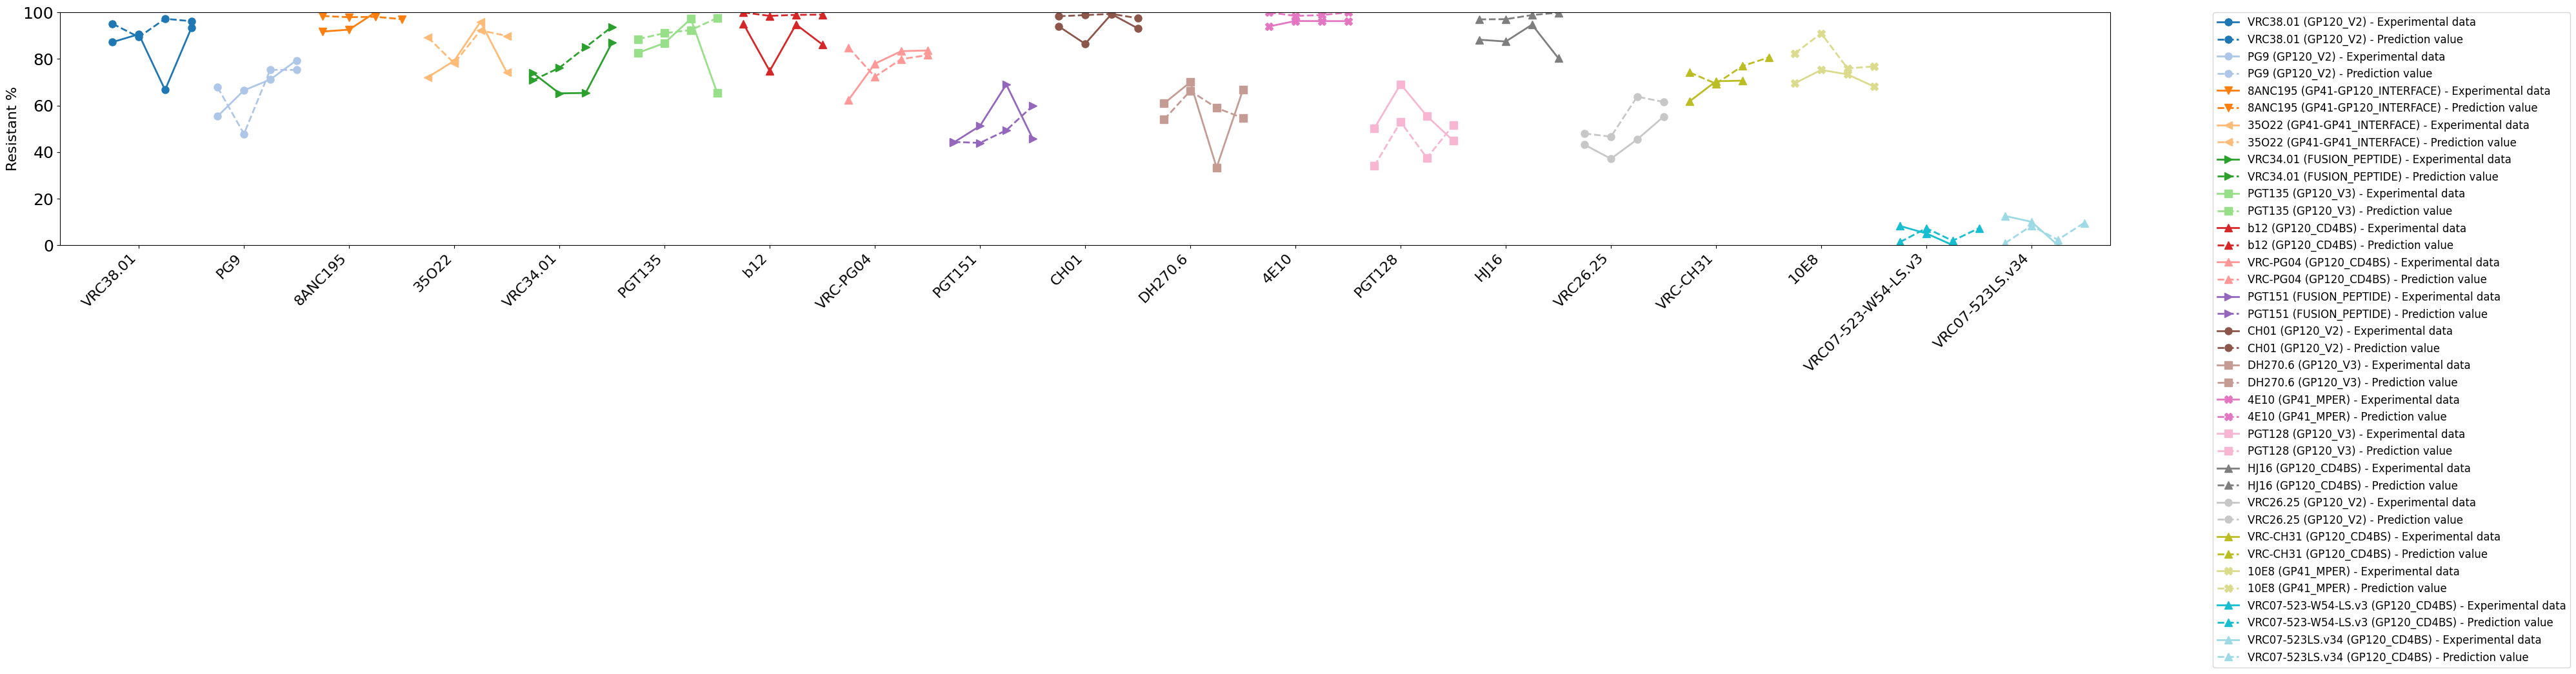

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/antibody_year_trend_threshold_0.2.png

Creating plot for threshold 1.0


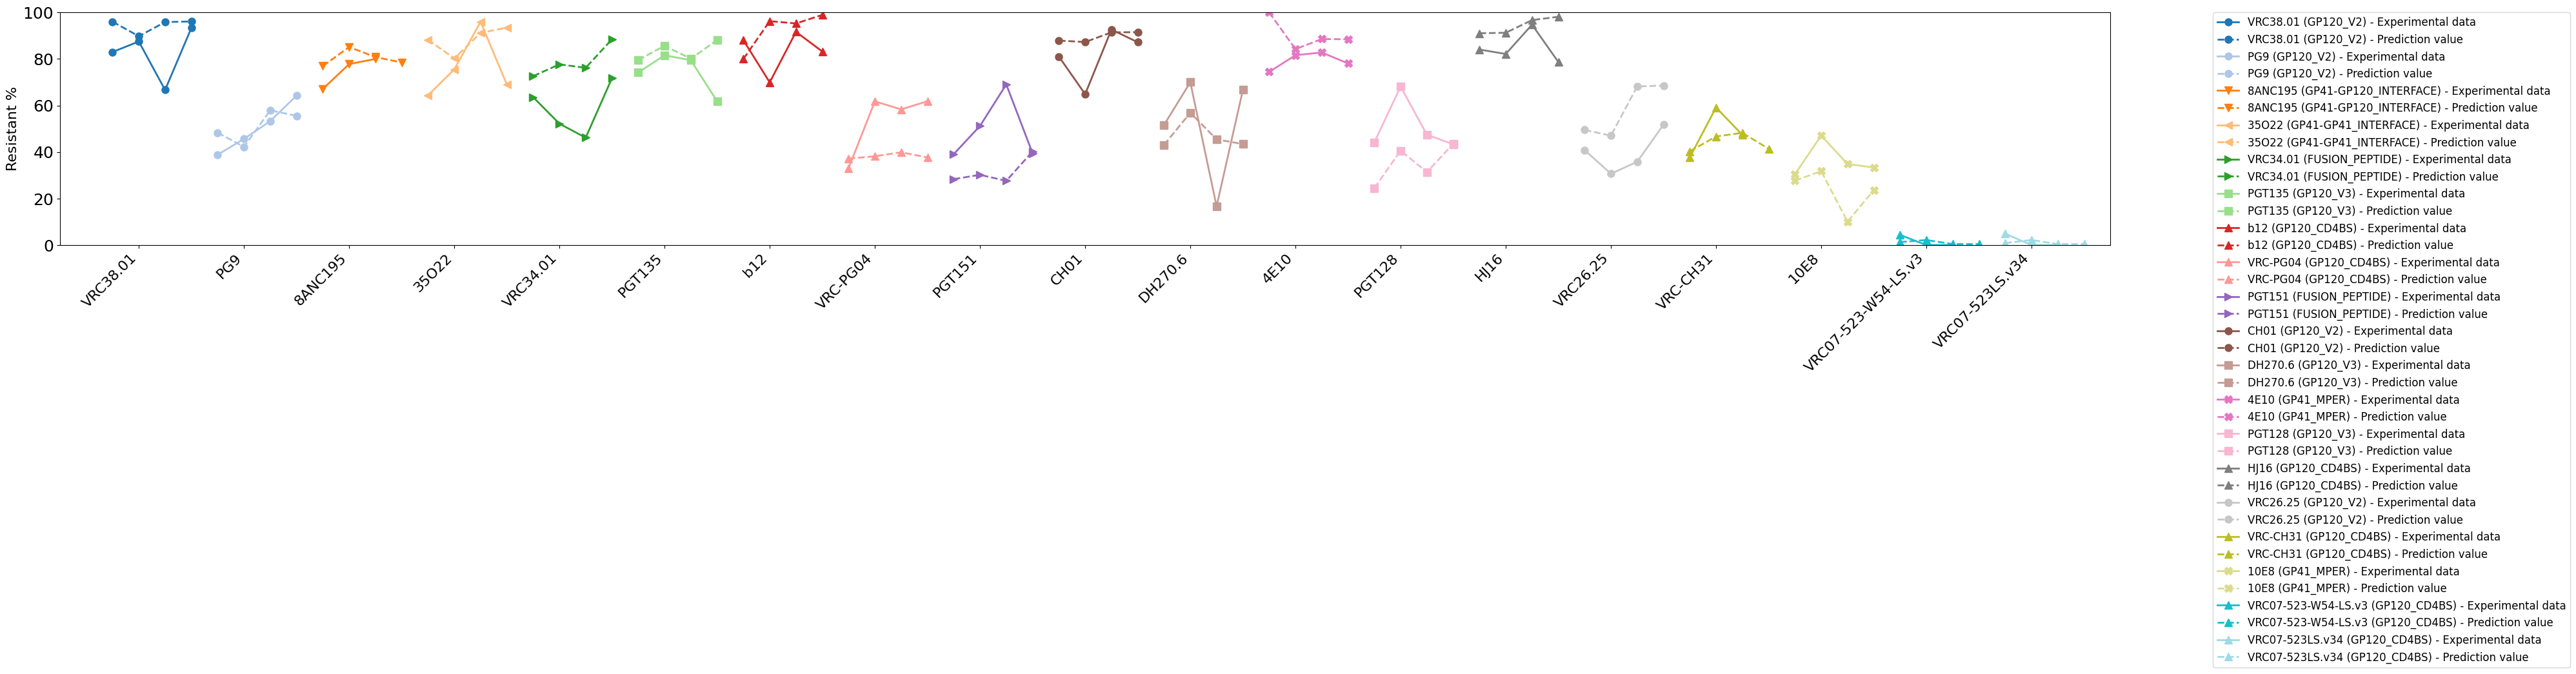

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/antibody_year_trend_threshold_1.0.png

Creating plot for threshold 50.0


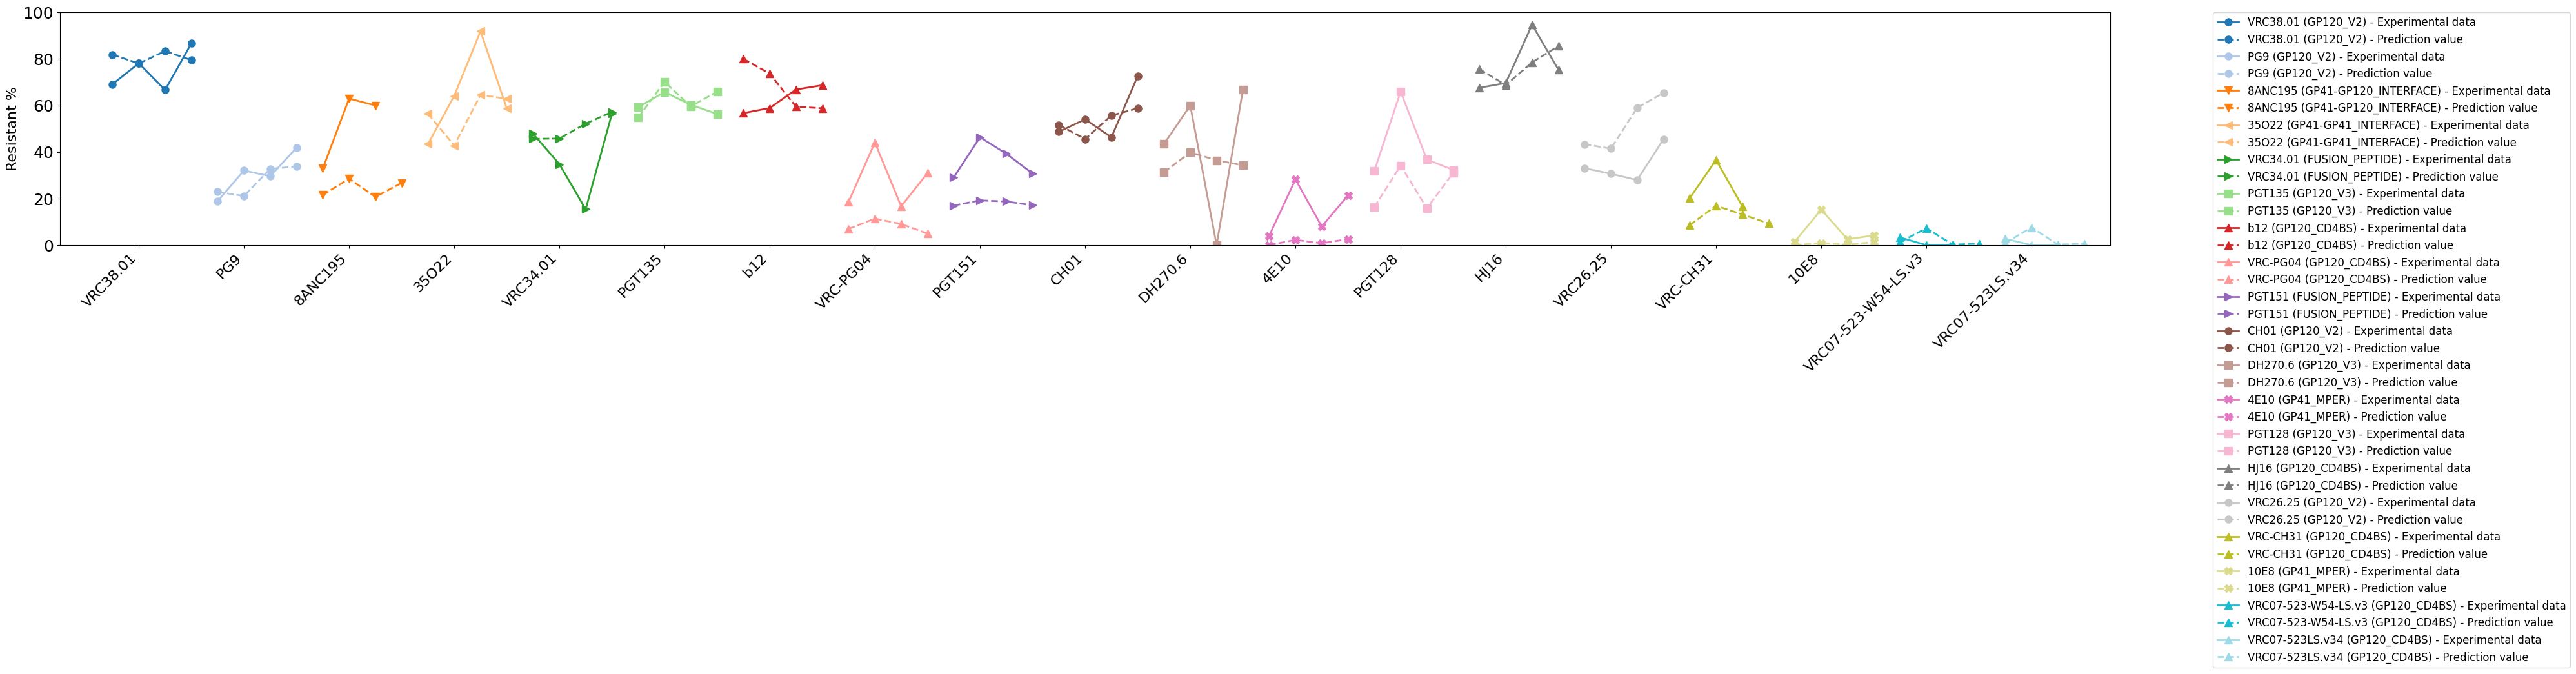

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/antibody_year_trend_threshold_50.0.png


In [7]:
# Filter antibodies to the specified list
target_antibodies_main_fig = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
target_antibodies_suppl_fig = ['VRC38.01', 'PG9', '8ANC195', '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
                     'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

# df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_main_fig)]
df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_suppl_fig)]

# Create 2 subsets from df_filtered
subset1 = df_filtered[df_filtered['GT Label'].notna()]  # GT Label is not NaN
subset2 = df_filtered[df_filtered['GT Label'].isna()]   # GT Label is NaN

print(f"Subset1 (GT Label not NaN) size: {len(subset1)}")
print(f"Subset2 (GT Label is NaN) size: {len(subset2)}")

# Define epitope mapping for all 29 antibodies
epitope_mapping = {
    'PGDM1400': 'GP120_V2',
    'PGT121': 'GP120_V3', 
    'VRC01': 'GP120_CD4BS',
    'SF12': 'GP120_SILENT',
    '10-1074': 'GP120_V3',
    '3BNC117': 'GP120_CD4BS',
    'PGT145': 'GP120_V2',
    'M1214_N1': 'GP120_CD4BS',
    '561_01_18': 'GP120_CD4BS',
    'N6': 'GP120_CD4BS',
    'VRC38.01': 'GP120_V2',
    'PG9': 'GP120_V2',
    '8ANC195': 'GP41-GP120_INTERFACE',
    '35O22': 'GP41-GP41_INTERFACE',
    'VRC34.01': 'FUSION_PEPTIDE',
    'PGT135': 'GP120_V3',
    'b12': 'GP120_CD4BS',
    'VRC-PG04': 'GP120_CD4BS',
    'PGT151': 'FUSION_PEPTIDE',
    'CH01': 'GP120_V2',
    'DH270.6': 'GP120_V3',
    '4E10': 'GP41_MPER',
    'PGT128': 'GP120_V3',
    'HJ16': 'GP120_CD4BS',
    'VRC26.25': 'GP120_V2',
    'VRC-CH31': 'GP120_CD4BS',
    '10E8': 'GP41_MPER',
    'VRC07-523-W54-LS.v3': 'GP120_CD4BS',
    'VRC07-523LS.v34': 'GP120_CD4BS'
}

# Define markers for all epitopes
epitope_markers = {
    'GP120_V2': 'o',
    'GP120_V3': 's',
    'GP120_CD4BS': '^',
    'GP120_SILENT': 'D',
    'GP41-GP120_INTERFACE': 'v',
    'GP41-GP41_INTERFACE': '<',
    'FUSION_PEPTIDE': '>',
    'GP41_MPER': 'X'
}

# Map year groups to x-axis values (merged groups 1 and 2)
year_group_to_x = {
    1: 1,  # Before 2010 (merged groups 1 and 2)
    2: 2,  # 2010-2015
    3: 3,  # 2015-2020
    4: 4   # After 2020
}

# Create separate plots for each threshold
thresholds = df_filtered['Threshold'].unique()

for threshold in thresholds:
    print(f"\nCreating plot for threshold {threshold}")
    
    # Filter data for current threshold
    threshold_subset1 = subset1[subset1['Threshold'] == threshold]
    threshold_subset2 = subset2[subset2['Threshold'] == threshold]
    
    # Calculate resistant percentage for each antibody and year group for both subsets
    results_subset1 = []
    results_subset2 = []
    
    # for antibody in target_antibodies_main_fig:
    for antibody in target_antibodies_suppl_fig:
        # Process subset1 (GT Label not NaN)
        antibody_data1 = threshold_subset1[threshold_subset1['Antibody'] == antibody]
        
        # Merge year groups 1 and 2
        for year_group in [1, 2, 3, 4]:
            group_data = antibody_data1[antibody_data1['Year_Group'] == year_group]
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                # Use merged x-value
                x_value = year_group_to_x[year_group]
                
                results_subset1.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': x_value,
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
        
        # Process subset2 (GT Label is NaN)
        antibody_data2 = threshold_subset2[threshold_subset2['Antibody'] == antibody]
        
        # Merge year groups 1 and 2
        for year_group in [1, 2, 3, 4]:
            group_data = antibody_data2[antibody_data2['Year_Group'] == year_group]
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                # Use merged x-value
                x_value = year_group_to_x[year_group]
                
                results_subset2.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': x_value,
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
    
    if not results_subset1 and not results_subset2:
        print(f"No data for threshold {threshold}")
        continue
        
    results_df1 = pd.DataFrame(results_subset1)
    results_df2 = pd.DataFrame(results_subset2)
    
    # Create the plot
    plt.figure(figsize=(40, 8))
    
    # Get unique antibodies for coloring (each antibody gets unique color)
    # antibodies = target_antibodies_main_fig
    antibodies = target_antibodies_suppl_fig
    colors = plt.cm.tab20(np.linspace(0, 1, len(antibodies)))
    color_dict = dict(zip(antibodies, colors))
    
    # Define the x-axis positions for each antibody with reduced gap
    antibody_positions = {ab: i * 4 for i, ab in enumerate(antibodies)}  # Reduced from 10 to 6
    
    # Plot each antibody with epitope-specific markers and unique colors
    for antibody in antibodies:
        base_pos = antibody_positions[antibody]
        epitope = epitope_mapping[antibody]
        
        # Get data for this antibody from both subsets
        antibody_data1 = results_df1[results_df1['Antibody'] == antibody].sort_values('X_Value')
        antibody_data2 = results_df2[results_df2['Antibody'] == antibody].sort_values('X_Value')
        
        # Calculate x positions for year groups within this antibody
        x_positions1 = [base_pos + x for x in antibody_data1['X_Value']]
        x_positions2 = [base_pos + x for x in antibody_data2['X_Value']]
        
        # Plot subset1 (solid line)
        if len(antibody_data1) > 1:
            plt.plot(x_positions1, antibody_data1['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], linestyle='-', 
                    label=f"{antibody} ({epitope}) - Experimental data")
        
        # Plot subset2 (dashed line)
        if len(antibody_data2) > 1:
            plt.plot(x_positions2, antibody_data2['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], linestyle='--', 
                    label=f"{antibody} ({epitope}) - Prediction value")
    
    # Customize the plot
    # plt.xlabel('Antibody', fontsize=12)
    plt.ylabel('Resistant %', fontsize=16)
    
    # Set x-axis ticks and labels - only antibody names
    plt.xticks([antibody_positions[ab] + 2 for ab in antibodies], antibodies, rotation=45, ha='right', fontsize=16)
    plt.yticks(fontsize=18)
    
    # Set x-axis limits to reduce whitespace
    plt.xlim(antibody_positions[antibodies[0]] - 1, antibody_positions[antibodies[-1]] + 5)
    
    plt.ylim(0, 100)
    
    # Create legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)
    
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/antibody_year_trend_threshold_{threshold}.png"
    plt.savefig(output_filename, dpi=800, bbox_inches='tight')
    plt.show()
    
    print(f"Saved plot: {output_filename}")

#### Old Plot


Creating plot for threshold 0.2


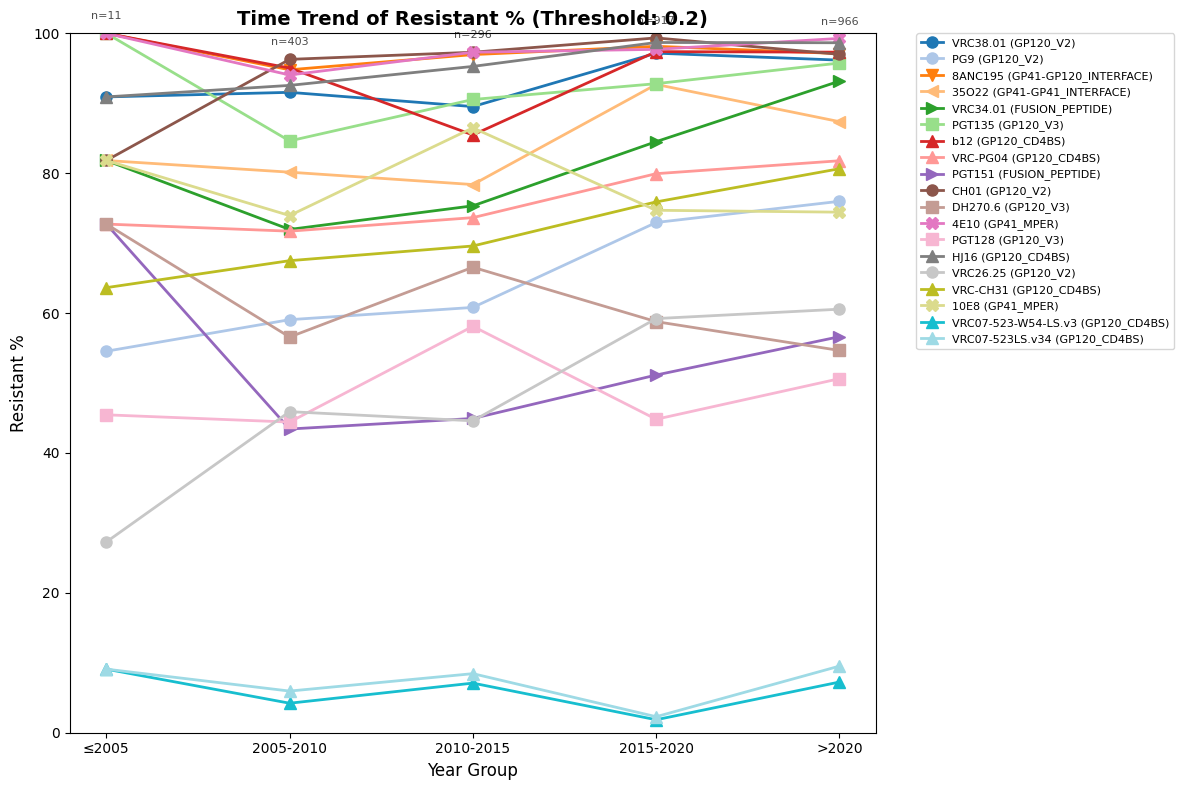

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_0.2.png

Summary for threshold 0.2:
Number of antibodies with data: 19
Total data points: 95

Year group average strain counts:
  Group 1 (2005): 11 strains
  Group 2 (2010): 403 strains
  Group 3 (2015): 296 strains
  Group 4 (2020): 917 strains
  Group 5 (2025): 966 strains

Creating plot for threshold 1.0


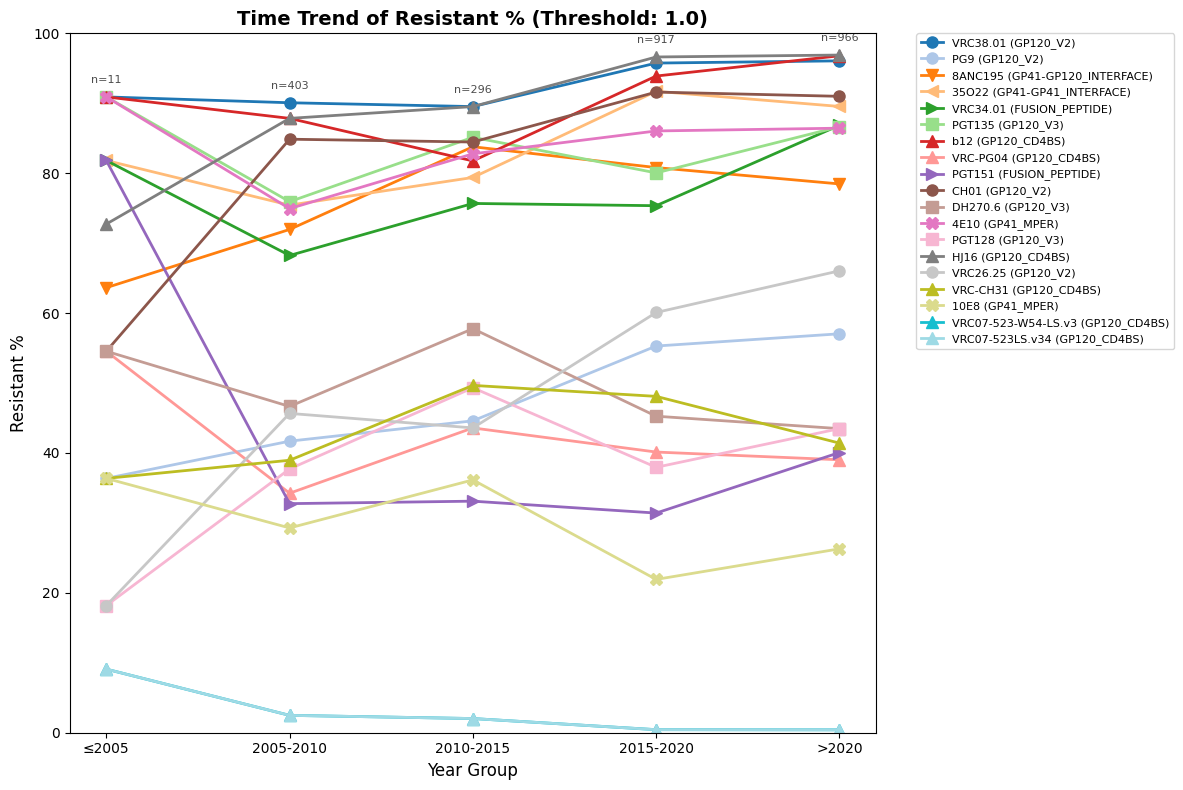

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_1.0.png

Summary for threshold 1.0:
Number of antibodies with data: 19
Total data points: 95

Year group average strain counts:
  Group 1 (2005): 11 strains
  Group 2 (2010): 403 strains
  Group 3 (2015): 296 strains
  Group 4 (2020): 917 strains
  Group 5 (2025): 966 strains

Creating plot for threshold 50.0


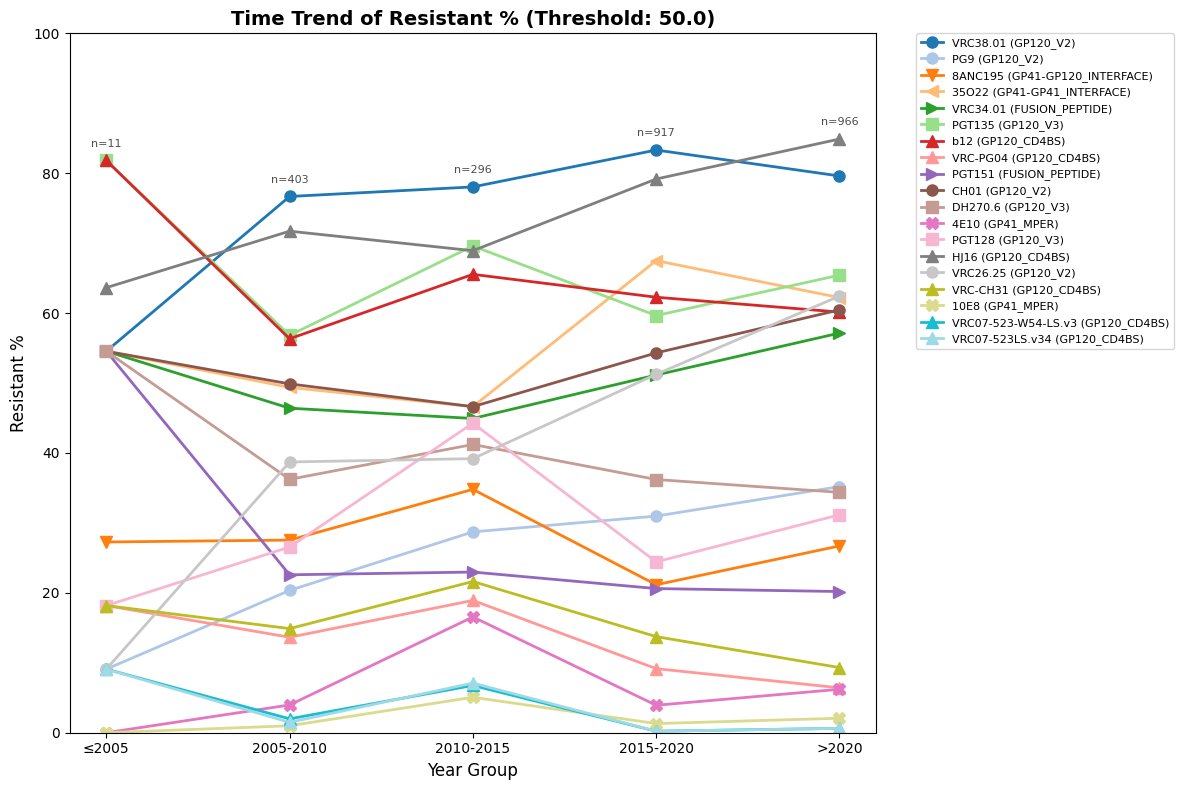

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_50.0.png

Summary for threshold 50.0:
Number of antibodies with data: 19
Total data points: 95

Year group average strain counts:
  Group 1 (2005): 11 strains
  Group 2 (2010): 403 strains
  Group 3 (2015): 296 strains
  Group 4 (2020): 917 strains
  Group 5 (2025): 966 strains

Distribution across year groups:
  Group 1 (2005, ≤2005): 627 observations
  Group 2 (2010, 2005-2010): 22971 observations
  Group 3 (2015, 2010-2015): 16872 observations
  Group 4 (2020, 2015-2020): 52269 observations
  Group 5 (2025, >2020): 55062 observations


In [15]:
# Filter antibodies to the specified list
target_antibodies_main_fig = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
target_antibodies_suppl_fig = ['VRC38.01', 'PG9', '8ANC195', '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
                     'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_main_fig)]
# df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_suppl_fig)]


# Define epitope mapping for all 29 antibodies
epitope_mapping = {
    'PGDM1400': 'GP120_V2',
    'PGT121': 'GP120_V3', 
    'VRC01': 'GP120_CD4BS',
    'SF12': 'GP120_SILENT',
    '10-1074': 'GP120_V3',
    '3BNC117': 'GP120_CD4BS',
    'PGT145': 'GP120_V2',
    'M1214_N1': 'GP120_CD4BS',
    '561_01_18': 'GP120_CD4BS',
    'N6': 'GP120_CD4BS',
    'VRC38.01': 'GP120_V2',
    'PG9': 'GP120_V2',
    '8ANC195': 'GP41-GP120_INTERFACE',
    '35O22': 'GP41-GP41_INTERFACE',
    'VRC34.01': 'FUSION_PEPTIDE',
    'PGT135': 'GP120_V3',
    'b12': 'GP120_CD4BS',
    'VRC-PG04': 'GP120_CD4BS',
    'PGT151': 'FUSION_PEPTIDE',
    'CH01': 'GP120_V2',
    'DH270.6': 'GP120_V3',
    '4E10': 'GP41_MPER',
    'PGT128': 'GP120_V3',
    'HJ16': 'GP120_CD4BS',
    'VRC26.25': 'GP120_V2',
    'VRC-CH31': 'GP120_CD4BS',
    '10E8': 'GP41_MPER',
    'VRC07-523-W54-LS.v3': 'GP120_CD4BS',
    'VRC07-523LS.v34': 'GP120_CD4BS'
}

# Define markers for all epitopes
epitope_markers = {
    'GP120_V2': 'o',
    'GP120_V3': 's',
    'GP120_CD4BS': '^',
    'GP120_SILENT': 'D',
    'GP41-GP120_INTERFACE': 'v',
    'GP41-GP41_INTERFACE': '<',
    'FUSION_PEPTIDE': '>',
    'GP41_MPER': 'X'
}

# Map year groups to x-axis values
year_group_to_x = {
    1: 2005,  # Before 2005 (including 2005)
    2: 2010,  # 2005-2010 (including 2010)
    3: 2015,  # 2010-2015 (including 2015)
    4: 2020,  # 2015-2020 (including 2020)
    5: 2025   # After 2020
}


# Create separate plots for each threshold
thresholds = df_filtered['Threshold'].unique()

for threshold in thresholds:
    print(f"\nCreating plot for threshold {threshold}")
    
    # Filter data for current threshold
    threshold_data = df_filtered[df_filtered['Threshold'] == threshold]
    
    # Calculate resistant percentage for each antibody and year group
    results = []
    
    for antibody in threshold_data['Antibody'].unique():
        antibody_data = threshold_data[threshold_data['Antibody'] == antibody]
        
        for year_group in [1, 2, 3, 4, 5]:
            group_data = antibody_data[antibody_data['Year_Group'] == year_group]
            
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                results.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': year_group_to_x[year_group],
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
    
    if not results:
        print(f"No data for threshold {threshold}")
        continue
        
    results_df = pd.DataFrame(results)
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Get unique antibodies for coloring (each antibody gets unique color)
    antibodies = results_df['Antibody'].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(antibodies)))
    color_dict = dict(zip(antibodies, colors))
    
    # Find antibody with highest resistant percentage in each year group for labeling
    label_positions = {}
    for year_group in [1, 2, 3, 4, 5]:
        year_data = results_df[results_df['Year_Group'] == year_group]
        if len(year_data) > 0:
            max_row = year_data.loc[year_data['Resistant_Percentage'].idxmax()]
            label_positions[year_group] = {
                'antibody': max_row['Antibody'],
                'x_value': max_row['X_Value'],
                'y_value': max_row['Resistant_Percentage'],
                'total_count': max_row['Total_Count']
            }
    
    # Plot each antibody with epitope-specific markers and unique colors
    for antibody in antibodies:
        antibody_data = results_df[results_df['Antibody'] == antibody].sort_values('X_Value')
        epitope = epitope_mapping[antibody]
        
        if len(antibody_data) > 1:
            # Plot line with epitope-specific marker and antibody-specific color
            plt.plot(antibody_data['X_Value'], antibody_data['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], label=f"{antibody} ({epitope})")

            # Add "n=" label only for the antibody with highest percentage in each year group
            for year_group, label_info in label_positions.items():
                if label_info['antibody'] == antibody:
                    plt.annotate(f"n={label_info['total_count']}", 
                               (label_info['x_value'], label_info['y_value']),
                               textcoords="offset points", 
                               xytext=(0,10), 
                               ha='center', 
                               fontsize=8,
                               alpha=0.7)
    
    # Customize the plot
    plt.xlabel('Year Group', fontsize=12)
    plt.ylabel('Resistant %', fontsize=12)
    plt.title(f'Time Trend of Resistant % (Threshold: {threshold})', fontsize=14, fontweight='bold')
    
    # Set x-axis ticks and labels
    plt.xticks([2005, 2010, 2015, 2020, 2025], 
              ['≤2005', '2005-2010', '2010-2015', '2015-2020', '>2020'],
              fontsize=10)
    
    plt.ylim(0, 100)
    
    # Create legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_{threshold}.png"
    plt.savefig(output_filename, dpi=800, bbox_inches='tight')
    plt.show()
    
    print(f"Saved plot: {output_filename}")
    
    # Print summary statistics
    print(f"\nSummary for threshold {threshold}:")
    print(f"Number of antibodies with data: {len(antibodies)}")
    print(f"Total data points: {len(results_df)}")
    
    # Show year group counts
    year_group_counts = results_df.groupby('Year_Group')['Total_Count'].mean().round().astype(int)
    print("\nYear group average strain counts:")
    for year_group, count in year_group_counts.items():
        print(f"  Group {year_group} ({year_group_to_x[year_group]}): {count} strains")

print("\nDistribution across year groups:")
year_group_dist = df_filtered['Year_Group'].value_counts().sort_index()
for year_group, count in year_group_dist.items():
    x_value = year_group_to_x[year_group]
    year_range = {
        1: '≤2005',
        2: "2005-2010",
        3: "2010-2015", 
        4: "2015-2020",
        5: ">2020"
    }[year_group]
    print(f"  Group {year_group} ({x_value}, {year_range}): {count} observations")


Creating plot for threshold 0.2


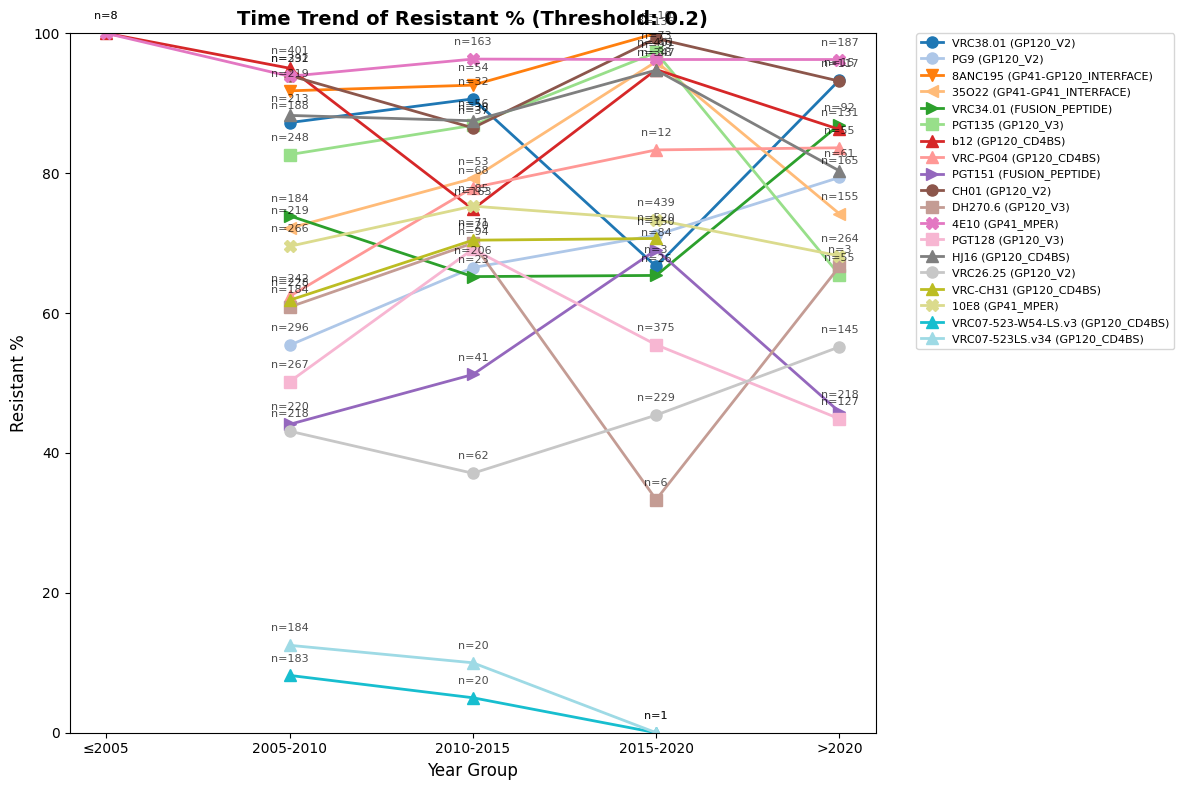

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_0.2.png

Summary for threshold 0.2:
Number of antibodies with data: 19
Total data points: 74

Year group average strain counts:
  Group 1 (2005): 8 strains
  Group 2 (2010): 241 strains
  Group 3 (2015): 69 strains
  Group 4 (2020): 155 strains
  Group 5 (2025): 119 strains

Creating plot for threshold 1.0


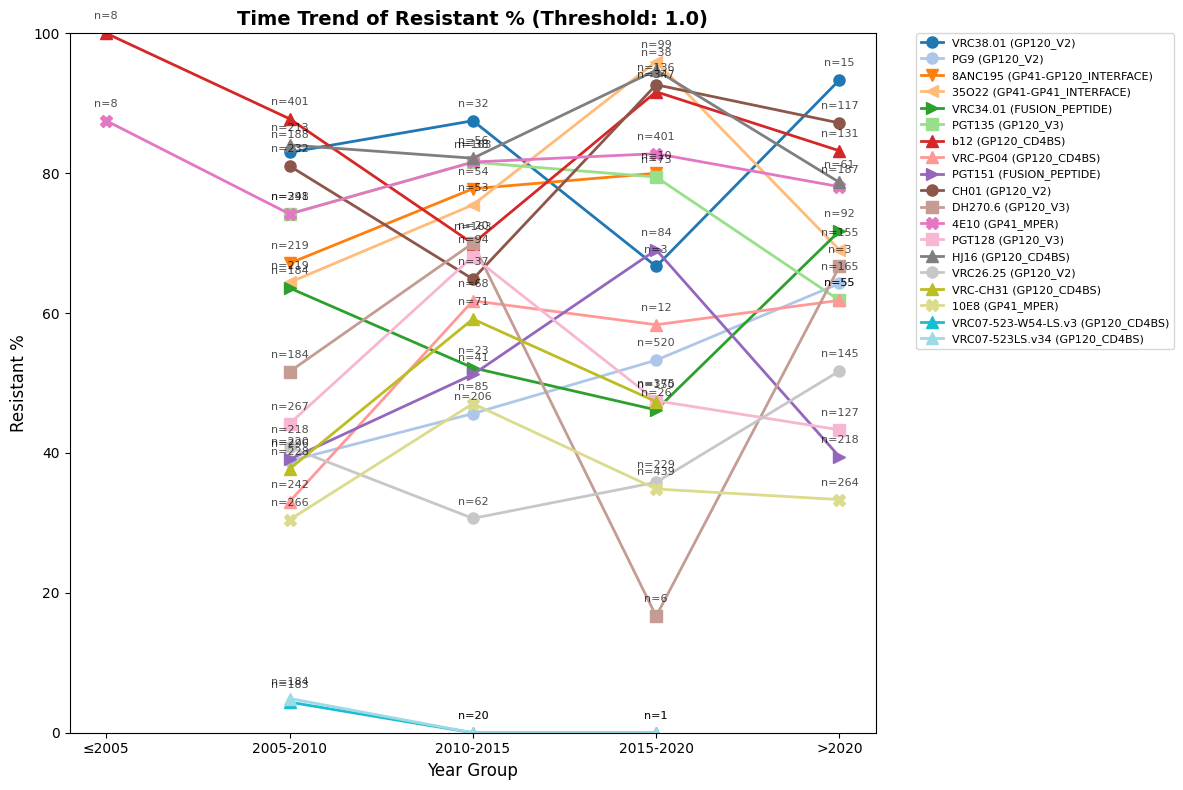

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_1.0.png

Summary for threshold 1.0:
Number of antibodies with data: 19
Total data points: 74

Year group average strain counts:
  Group 1 (2005): 8 strains
  Group 2 (2010): 241 strains
  Group 3 (2015): 69 strains
  Group 4 (2020): 155 strains
  Group 5 (2025): 119 strains

Creating plot for threshold 50.0


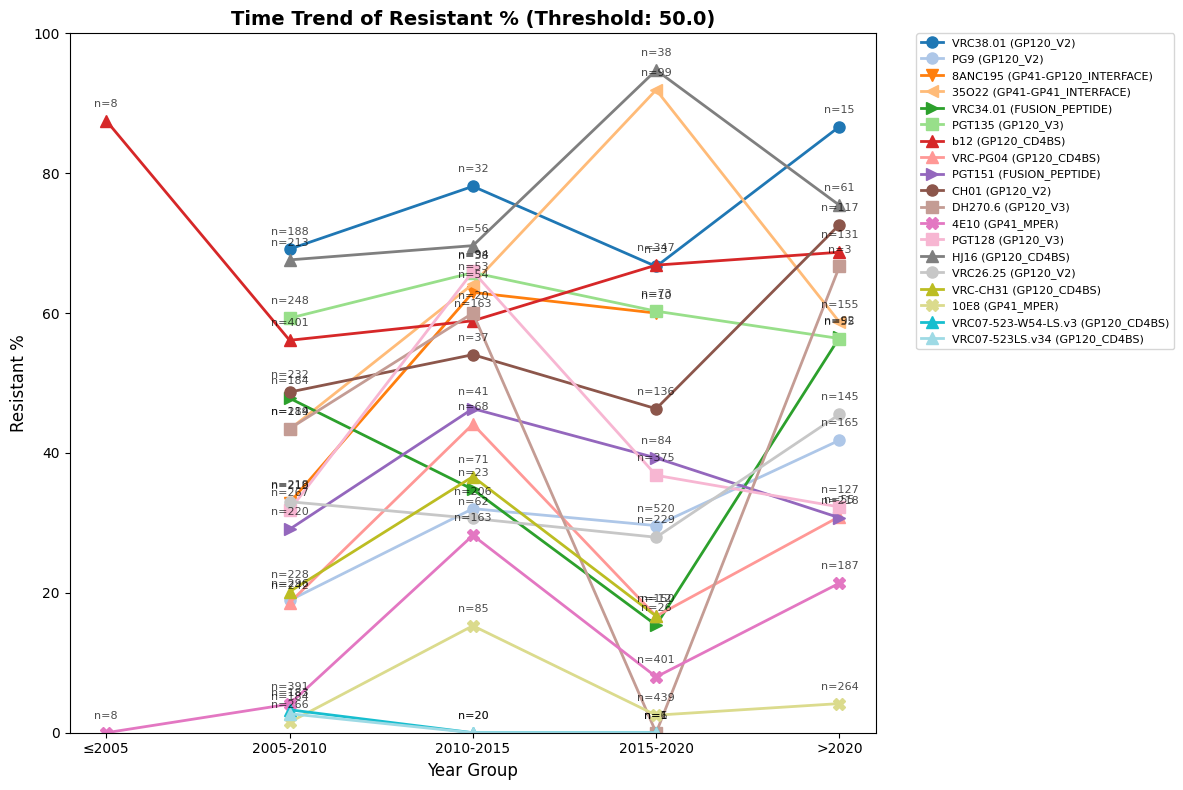

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_50.0.png

Summary for threshold 50.0:
Number of antibodies with data: 19
Total data points: 74

Year group average strain counts:
  Group 1 (2005): 8 strains
  Group 2 (2010): 241 strains
  Group 3 (2015): 69 strains
  Group 4 (2020): 155 strains
  Group 5 (2025): 119 strains

Distribution across year groups:
  Group 1 (2005, ≤2005): 48 observations
  Group 2 (2010, 2005-2010): 13749 observations
  Group 3 (2015, 2010-2015): 3918 observations
  Group 4 (2020, 2015-2020): 8850 observations
  Group 5 (2025, >2020): 5370 observations


In [18]:
# Filter antibodies to the specified list
target_antibodies_main_fig = ['PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 'M1214_N1', '561_01_18', 'N6', '3BNC117', 'PGDM1400']
target_antibodies_suppl_fig = ['VRC38.01', 'PG9', '8ANC195', '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
                     'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']

# df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_main_fig)]
# df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_suppl_fig)]
df_filtered = df_with_years[(df_with_years['Antibody'].isin(target_antibodies_suppl_fig)) & (df_with_years['GT Label'].notna())]

# Define epitope mapping for all 29 antibodies
epitope_mapping = {
    'PGDM1400': 'GP120_V2',
    'PGT121': 'GP120_V3', 
    'VRC01': 'GP120_CD4BS',
    'SF12': 'GP120_SILENT',
    '10-1074': 'GP120_V3',
    '3BNC117': 'GP120_CD4BS',
    'PGT145': 'GP120_V2',
    'M1214_N1': 'GP120_CD4BS',
    '561_01_18': 'GP120_CD4BS',
    'N6': 'GP120_CD4BS',
    'VRC38.01': 'GP120_V2',
    'PG9': 'GP120_V2',
    '8ANC195': 'GP41-GP120_INTERFACE',
    '35O22': 'GP41-GP41_INTERFACE',
    'VRC34.01': 'FUSION_PEPTIDE',
    'PGT135': 'GP120_V3',
    'b12': 'GP120_CD4BS',
    'VRC-PG04': 'GP120_CD4BS',
    'PGT151': 'FUSION_PEPTIDE',
    'CH01': 'GP120_V2',
    'DH270.6': 'GP120_V3',
    '4E10': 'GP41_MPER',
    'PGT128': 'GP120_V3',
    'HJ16': 'GP120_CD4BS',
    'VRC26.25': 'GP120_V2',
    'VRC-CH31': 'GP120_CD4BS',
    '10E8': 'GP41_MPER',
    'VRC07-523-W54-LS.v3': 'GP120_CD4BS',
    'VRC07-523LS.v34': 'GP120_CD4BS'
}

# Define markers for all epitopes
epitope_markers = {
    'GP120_V2': 'o',
    'GP120_V3': 's',
    'GP120_CD4BS': '^',
    'GP120_SILENT': 'D',
    'GP41-GP120_INTERFACE': 'v',
    'GP41-GP41_INTERFACE': '<',
    'FUSION_PEPTIDE': '>',
    'GP41_MPER': 'X'
}

# Map year groups to x-axis values
year_group_to_x = {
    1: 2005,  # Before 2005 (including 2005)
    2: 2010,  # 2005-2010 (including 2010)
    3: 2015,  # 2010-2015 (including 2015)
    4: 2020,  # 2015-2020 (including 2020)
    5: 2025   # After 2020
}


# Create separate plots for each threshold
thresholds = df_filtered['Threshold'].unique()

for threshold in thresholds:
    print(f"\nCreating plot for threshold {threshold}")
    
    # Filter data for current threshold
    threshold_data = df_filtered[df_filtered['Threshold'] == threshold]
    
    # Calculate resistant percentage for each antibody and year group
    results = []
    
    for antibody in threshold_data['Antibody'].unique():
        antibody_data = threshold_data[threshold_data['Antibody'] == antibody]
        
        for year_group in [1, 2, 3, 4, 5]:
            group_data = antibody_data[antibody_data['Year_Group'] == year_group]
            
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                results.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': year_group_to_x[year_group],
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
    
    if not results:
        print(f"No data for threshold {threshold}")
        continue
        
    results_df = pd.DataFrame(results)
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Get unique antibodies for coloring (each antibody gets unique color)
    antibodies = results_df['Antibody'].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(antibodies)))
    color_dict = dict(zip(antibodies, colors))
    
    # Find antibody with highest resistant percentage in each year group for labeling
    label_positions = {}
    for year_group in [1, 2, 3, 4, 5]:
        year_data = results_df[results_df['Year_Group'] == year_group]
        if len(year_data) > 0:
            max_row = year_data.loc[year_data['Resistant_Percentage'].idxmax()]
            label_positions[year_group] = {
                'antibody': max_row['Antibody'],
                'x_value': max_row['X_Value'],
                'y_value': max_row['Resistant_Percentage'],
                'total_count': max_row['Total_Count']
            }
    
    # Plot each antibody with epitope-specific markers and unique colors
    for antibody in antibodies:
        antibody_data = results_df[results_df['Antibody'] == antibody].sort_values('X_Value')
        epitope = epitope_mapping[antibody]
        
        if len(antibody_data) > 1:
            # Plot line with epitope-specific marker and antibody-specific color
            plt.plot(antibody_data['X_Value'], antibody_data['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], label=f"{antibody} ({epitope})")

            # # Add "n=" label only for the antibody with highest percentage in each year group
            # for year_group, label_info in label_positions.items():
            #     if label_info['antibody'] == antibody:
            #         plt.annotate(f"n={label_info['total_count']}", 
            #                    (label_info['x_value'], label_info['y_value']),
            #                    textcoords="offset points", 
            #                    xytext=(0,10), 
            #                    ha='center', 
            #                    fontsize=8,
            #                    alpha=0.7)

            # Add data point labels with counts
            for _, row in antibody_data.iterrows():
                plt.annotate(f"n={row['Total_Count']}", 
                           (row['X_Value'], row['Resistant_Percentage']),
                           textcoords="offset points", 
                           xytext=(0,10), 
                           ha='center', 
                           fontsize=8,
                           alpha=0.7)        
    
    # Customize the plot
    plt.xlabel('Year Group', fontsize=12)
    plt.ylabel('Resistant %', fontsize=12)
    plt.title(f'Time Trend of Resistant % (Threshold: {threshold})', fontsize=14, fontweight='bold')
    
    # Set x-axis ticks and labels
    plt.xticks([2005, 2010, 2015, 2020, 2025], 
              ['≤2005', '2005-2010', '2010-2015', '2015-2020', '>2020'],
              fontsize=10)
    
    plt.ylim(0, 100)
    
    # Create legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)
    
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_oct1_all_strains/curated_data_epitope_with_all_lineage/time_trend_threshold_{threshold}.png"
    plt.savefig(output_filename, dpi=800, bbox_inches='tight')
    plt.show()
    
    print(f"Saved plot: {output_filename}")
    
    # Print summary statistics
    print(f"\nSummary for threshold {threshold}:")
    print(f"Number of antibodies with data: {len(antibodies)}")
    print(f"Total data points: {len(results_df)}")
    
    # Show year group counts
    year_group_counts = results_df.groupby('Year_Group')['Total_Count'].mean().round().astype(int)
    print("\nYear group average strain counts:")
    for year_group, count in year_group_counts.items():
        print(f"  Group {year_group} ({year_group_to_x[year_group]}): {count} strains")

print("\nDistribution across year groups:")
year_group_dist = df_filtered['Year_Group'].value_counts().sort_index()
for year_group, count in year_group_dist.items():
    x_value = year_group_to_x[year_group]
    year_range = {
        1: '≤2005',
        2: "2005-2010",
        3: "2010-2015", 
        4: "2015-2020",
        5: ">2020"
    }[year_group]
    print(f"  Group {year_group} ({x_value}, {year_range}): {count} observations")

#### Find all available Envs from CATNAP (with/without GT data)

In [19]:
import pandas as pd

# Read the file, skipping the first row (header)
df_raw = pd.read_csv("/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/env_all_11-2025.txt", sep='\t',
                 skiprows=1)

# Remove rows where "Sampling Year" is blank
df = df_raw.dropna(subset=['Sampling Year'])

# Identify rows where both "Patient Code" and "PAT id(SSAM)" are blank
blank_both = df['Patient Code'].isna() & df['PAT id(SSAM)'].isna()

# For rows with both IDs blank: keep unique sequences
df_blank_both = df[blank_both].drop_duplicates(subset=['Sequence'])

# For rows with at least one ID present: group by the unique combo and keep one row per group
df_with_ids = df[~blank_both]
df_grouped = df_with_ids.groupby(['Patient Code', 'PAT id(SSAM)']).first().reset_index()

# Combine both datasets
df_processed = pd.concat([df_grouped, df_blank_both], ignore_index=True)

# Handle duplicate sequences by keeping the one with earliest sampling year
df_processed = df_processed.sort_values(['Sequence', 'Sampling Year']).drop_duplicates(subset=['Sequence'], keep='first')

# Sort by "#" column in ascending order and make it the first column
df_processed = df_processed.sort_values('#').reset_index(drop=True)

# Reorder columns to make "#" the first column
cols = ['#'] + [col for col in df_processed.columns if col != '#']
df_processed = df_processed[cols]

# Display info about the processed data
print(f"Original rows: {len(df_raw)}")
print(f"Rows with sampling year: {len(df)}")
print(f"Rows with both IDs blank: {len(df[blank_both])}")
print(f"Rows with at least one ID: {len(df_with_ids)}")
print(f"Processed rows: {len(df_processed)}")
print(f"Unique sequences from blank ID rows: {len(df_blank_both)}")
print(f"Unique patient groups: {len(df_grouped)}")

Original rows: 176698
Rows with sampling year: 165374
Rows with both IDs blank: 61516
Rows with at least one ID: 103858
Processed rows: 69822
Unique sequences from blank ID rows: 60244
Unique patient groups: 9594


In [20]:
df_processed

,#,Patient Code,PAT id(SSAM),Se ID,Accession,Name,Subtype,Country,Sampling Year,HXB2/MAC239 start,HXB2/MAC239 stop,Sequence Length,Organism,Sequence
0,1,LAI,19535.0,149746,A04321,IIIB_LAI,B,FRANCE,1983.0,455,9636,9193,HIV-1,ggtctctcnngttagaccagatttgagcctggnagctctctggcta...
1,3,IN101,14294.0,229443,AB023804,93IN101,C,INDIA,1993.0,1,9702,9680,HIV-1,tggaagggttaatttactccaagaaaaggcaagaaatccttgattt...
2,4,C1_husband,15892.0,114323,AB032740,95TNIH022,01_AE,THAILAND,1995.0,49,9473,9427,HIV-1,gggtctataatacacaaggctttttccctgattggcaaaactacac...
3,5,47,881.0,114322,AB032741,95TNIH047,01_AE,THAILAND,1995.0,49,9464,9430,HIV-1,gggtctataatacacaaggcttctttcctgattggcaaaactacac...
4,6,NJ97-42,24045.0,114321,AB049811,97GH-AG1,02_AG,GHANA,1997.0,1,9690,9748,HIV-1,tggatgggctaatttactccaagaaaagacaagagatccttgatct...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69817,176687,NG083,13804.0,240467,U88826,92NG083_JV10832,G,NIGERIA,1992.0,630,9635,8987,HIV-1,atgaaagcgaaagttaatagggactcgaaaacgaaagttccagaga...
69818,176688,SC141,2462.0,236937,U90934,SC14B,B,UNITED STATES,1984.0,5987,9012,3014,HIV-1,agacagcgacgaacagctcctcaagacagtcagactcatcaagctt...
69819,176691,MAL,578.0,147318,X04415,MAL_MALCG,A1DK,DEM REP OF CONGO,1985.0,455,9637,9229,HIV-1,ggtctctcttgttagaccaggtcgagcccgggagctctctggctag...
69820,176692,CA9,357.0,146488,X96522,CA9,O,CAMEROON,1993.0,6213,8795,2631,HIV-1,atgacagtgactatgaaagtaatggagaagaagaacaggaagttat...


In [21]:
# Final check: Verify all sequences are unique
total_rows = len(df_processed)
unique_sequences = df_processed['Sequence'].nunique()
all_sequences_unique = (total_rows == unique_sequences)

In [23]:
unique_sequences

69822

In [22]:
if not all_sequences_unique:
    print(f"WARNING: Found {total_rows - unique_sequences} duplicate sequences!")
    # Show duplicate sequences if any exist
    duplicate_sequences = df_processed[df_processed.duplicated('Sequence', keep=False)]
    print(f"Duplicate sequences found: {len(duplicate_sequences)}")
    print("Sample of duplicate sequences:")
    print(duplicate_sequences[['#', 'Patient Code', 'PAT id(SSAM)', 'Sequence']])

In [24]:
# Save the processed dataframe
output_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/env_all_11-2025_preprocessed.txt"
df_processed.to_csv(output_path, index=False, sep='\t')

print(f"\nProcessed data saved to: {output_path}")


Processed data saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/env_all_11-2025_preprocessed.txt


In [25]:
# Create FASTA file
fasta_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/env_all_11-2025_preprocessed.fasta"

with open(fasta_path, 'w') as fasta_file:
    for index, row in df_processed.iterrows():
        # Get sequence
        sequence = row['Sequence']
        
        # Create seqId by concatenating specified columns, replacing NaN with "N/A"
        columns_to_include = ['#', 'Patient Code', 'PAT id(SSAM)', 'Se ID', 'Accession', 'Name', 'Subtype', 'Country', 'Sampling Year', 'Organism']
        seq_id_parts = []
        
        for col in columns_to_include:
            value = row[col]
            if pd.isna(value):
                seq_id_parts.append("N/A")
            else:
                # Convert to string and remove any potential problematic characters
                seq_id_parts.append(str(value).replace(' ', '_').replace('|', '_'))
        
        # Join all parts with pipe separator
        seq_id = "|".join(seq_id_parts)
        
        # Write to FASTA file
        fasta_file.write(f">{seq_id}\n")
        fasta_file.write(f"{sequence}\n")

print(f"FASTA file saved to: {fasta_path}")
print(f"Total sequences in FASTA file: {len(df_processed)}")

FASTA file saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/env_all_11-2025_preprocessed.fasta
Total sequences in FASTA file: 69822


# Joseph's PacBio data

## Calculate majority votes from the 10-fold predictions (under cutoff 0.2, only 8 final models for CH01 and 9 final models for 8ANC195; under other thresholds, all 10 final models)

Here, we DON'T compare with the single prediction because we already found (from CATNAP 384 strains) that performance of "all10folds_of_best_repeat" better than "best1_of100"

We only are interested in 3BNC117, VRC01, 10-1074 and PGT121 because Joseph has bNab-rep prediction performance for those 4 abs. We only are interested in cutoff 1 and 50 ug/mL

In [2]:
thres = 1

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return majority voted results"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directory for this specific sample (only all10folds now)
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Joseph_Pacbio_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    expected_count = 10
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    if not all10_files:
        print(f"Error: No files found for {sample_name}-{antibody}")
        return []
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_results = []
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        total_votes = len(states)
        
        # Determine majority prediction
        if sensitive_count > resistant_count:
            majority_pred = 'sensitive'
            confidence = sensitive_count / total_votes
        elif resistant_count > sensitive_count:
            majority_pred = 'resistant'
            confidence = resistant_count / total_votes
        else:
            # Tie case
            majority_pred = 'sensitive/resistant'
            confidence = 0.5
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Majority_Prediction': majority_pred,
            'Sensitive_Votes': sensitive_count,
            'Resistant_Votes': resistant_count,
            'Total_Votes': total_votes,
            'Confidence': round(confidence, 3)
        }
        
        majority_results.append(instance_data)
    
    return majority_results

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Joseph_PacBio_seqs/prediction_results"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "LAT-03-020_PBMC", "LAT-03-025_PBMC", "LAT-03-025_RNA", "LAT-03-044_PBMC", "LAT-03-064_PBMC", 
        "LAT-03-064_RNA", "LAT-03-066_PBMC", "LAT-03-066_RNA"
    ]
    
    # List of antibodies
    antibodies = ['PGT121', 'VRC01', '10-1074', '3BNC117']
    
    # Process all samples and antibodies
    all_majority_results = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample, f"threshold_{thres}")
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                majority_results = process_sample_predictions(sample, antibody, sample_output_dir)
                all_majority_results.extend(majority_results)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframe
    majority_df = pd.DataFrame(all_majority_results)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"majority_voted_results_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All majority voted results
        majority_df.to_excel(writer, sheet_name='All Majority Results', index=False)
        
        # Tab 2: Summary by sample and antibody
        if len(majority_df) > 0:
            summary_stats = majority_df.groupby(['Sample', 'Antibody']).agg({
                'Virus_ID': 'count',
                'Confidence': 'mean'
            }).reset_index()
            summary_stats.columns = ['Sample', 'Antibody', 'Total_Viruses', 'Average_Confidence']
            summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
            summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        
        # Tab 3: Prediction counts
        if len(majority_df) > 0:
            prediction_counts = majority_df.groupby(['Sample', 'Antibody', 'Majority_Prediction']).size().reset_index()
            prediction_counts.columns = ['Sample', 'Antibody', 'Prediction', 'Count']
            prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
    
    print(f"Saved majority voted results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    if len(majority_df) > 0:
        total_instances = len(majority_df)
        print(f"Total virus instances: {total_instances}")
        print(f"Total samples processed: {majority_df['Sample'].nunique()}")
        print(f"Total antibodies processed: {majority_df['Antibody'].nunique()}")
        
        # Print prediction distribution
        print("\n=== PREDICTION DISTRIBUTION ===")
        pred_dist = majority_df['Majority_Prediction'].value_counts()
        for pred, count in pred_dist.items():
            percentage = (count / total_instances) * 100
            print(f"{pred}: {count} ({percentage:.1f}%)")
        
        # Print average confidence
        avg_confidence = majority_df['Confidence'].mean()
        print(f"\nAverage confidence: {avg_confidence:.3f}")
        
        # Print sample and antibody counts
        print("\n=== VIRUS COUNTS BY SAMPLE ===")
        sample_counts = majority_df.groupby('Sample')['Virus_ID'].count().sort_values(ascending=False)
        for sample, count in sample_counts.items():
            print(f"{sample}: {count} viruses")
            
        print("\n=== VIRUS COUNTS BY ANTIBODY ===")
        antibody_counts = majority_df.groupby('Antibody')['Virus_ID'].count().sort_values(ascending=False)
        for antibody, count in antibody_counts.items():
            print(f"{antibody}: {count} viruses")
    else:
        print("No data processed.")

if __name__ == "__main__":
    main()

Processing LAT-03-020_PBMC - PGT121
Processing LAT-03-020_PBMC - VRC01
Processing LAT-03-020_PBMC - 10-1074
Processing LAT-03-020_PBMC - 3BNC117
Processing LAT-03-025_PBMC - PGT121
Processing LAT-03-025_PBMC - VRC01
Processing LAT-03-025_PBMC - 10-1074
Processing LAT-03-025_PBMC - 3BNC117
Processing LAT-03-025_RNA - PGT121
Processing LAT-03-025_RNA - VRC01
Processing LAT-03-025_RNA - 10-1074
Processing LAT-03-025_RNA - 3BNC117
Processing LAT-03-044_PBMC - PGT121
Processing LAT-03-044_PBMC - VRC01
Processing LAT-03-044_PBMC - 10-1074
Processing LAT-03-044_PBMC - 3BNC117
Processing LAT-03-064_PBMC - PGT121
Processing LAT-03-064_PBMC - VRC01
Processing LAT-03-064_PBMC - 10-1074
Processing LAT-03-064_PBMC - 3BNC117
Processing LAT-03-064_RNA - PGT121
Processing LAT-03-064_RNA - VRC01
Processing LAT-03-064_RNA - 10-1074
Processing LAT-03-064_RNA - 3BNC117
Processing LAT-03-066_PBMC - PGT121
Processing LAT-03-066_PBMC - VRC01
Processing LAT-03-066_PBMC - 10-1074
Processing LAT-03-066_PBMC - 3

In [3]:
thres = 50

def process_sample_predictions(sample_name, antibody, sample_output_dir):
    """Process predictions for a single sample and antibody, return majority voted results"""
    print(f"Processing {sample_name} - {antibody}")
    
    # Define directory for this specific sample (only all10folds now)
    all10folds_dir = os.path.join(sample_output_dir, "all10folds_of_best_repeat")
    
    # Get all prediction files for this sample and antibody from all10folds
    pattern = f"Predicted_threshold{thres}_Joseph_Pacbio_{sample_name}_*_{antibody}.txt"
    all10_files = glob.glob(os.path.join(all10folds_dir, pattern))
    
    expected_count = 10
    if len(all10_files) != expected_count:
        print(f"Warning: Found {len(all10_files)} files for {sample_name}-{antibody}, expected {expected_count}")
    
    if not all10_files:
        print(f"Error: No files found for {sample_name}-{antibody}")
        return []
    
    # Read all predictions from all10folds
    all_predictions = defaultdict(list)
    
    for file_path in all10_files:
        try:
            df = pd.read_csv(file_path, sep='\t')
            for _, row in df.iterrows():
                virus_id = row['Virus_ID']
                state = row['State']
                all_predictions[virus_id].append(state)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    
    # Calculate majority vote for each virus
    majority_results = []
    
    for virus_id, states in all_predictions.items():
        sensitive_count = states.count('sensitive')
        resistant_count = states.count('resistant')
        total_votes = len(states)
        
        # Determine majority prediction
        if sensitive_count > resistant_count:
            majority_pred = 'sensitive'
            confidence = sensitive_count / total_votes
        elif resistant_count > sensitive_count:
            majority_pred = 'resistant'
            confidence = resistant_count / total_votes
        else:
            # Tie case
            majority_pred = 'sensitive/resistant'
            confidence = 0.5
        
        instance_data = {
            'Sample': sample_name,
            'Antibody': antibody,
            'Virus_ID': virus_id,
            'Majority_Prediction': majority_pred,
            'Sensitive_Votes': sensitive_count,
            'Resistant_Votes': resistant_count,
            'Total_Votes': total_votes,
            'Confidence': round(confidence, 3)
        }
        
        majority_results.append(instance_data)
    
    return majority_results

def main():
    # Define base directory
    base_dir = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/Joseph_PacBio_seqs/prediction_results"
    output_dir = base_dir
    
    # List of samples
    samples = [
        "LAT-03-020_PBMC", "LAT-03-025_PBMC", "LAT-03-025_RNA", "LAT-03-044_PBMC", "LAT-03-064_PBMC", 
        "LAT-03-064_RNA", "LAT-03-066_PBMC", "LAT-03-066_RNA"
    ]
    
    # List of antibodies
    antibodies = ['PGT121', 'VRC01', '10-1074', '3BNC117']
    
    # Process all samples and antibodies
    all_majority_results = []
    
    for sample in samples:
        sample_output_dir = os.path.join(base_dir, sample, f"threshold_{thres}")
        
        # Check if sample directory exists
        if not os.path.exists(sample_output_dir):
            print(f"Warning: Sample directory not found: {sample_output_dir}")
            continue
            
        for antibody in antibodies:
            try:
                majority_results = process_sample_predictions(sample, antibody, sample_output_dir)
                all_majority_results.extend(majority_results)
            except Exception as e:
                print(f"Error processing {sample}-{antibody}: {e}")
    
    # Create dataframe
    majority_df = pd.DataFrame(all_majority_results)
    
    # Create Excel writer object
    excel_file = os.path.join(output_dir, f"majority_voted_results_threshold_{thres}.xlsx")
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        # Tab 1: All majority voted results
        majority_df.to_excel(writer, sheet_name='All Majority Results', index=False)
        
        # Tab 2: Summary by sample and antibody
        if len(majority_df) > 0:
            summary_stats = majority_df.groupby(['Sample', 'Antibody']).agg({
                'Virus_ID': 'count',
                'Confidence': 'mean'
            }).reset_index()
            summary_stats.columns = ['Sample', 'Antibody', 'Total_Viruses', 'Average_Confidence']
            summary_stats['Average_Confidence'] = summary_stats['Average_Confidence'].round(3)
            summary_stats.to_excel(writer, sheet_name='Summary Stats', index=False)
        
        # Tab 3: Prediction counts
        if len(majority_df) > 0:
            prediction_counts = majority_df.groupby(['Sample', 'Antibody', 'Majority_Prediction']).size().reset_index()
            prediction_counts.columns = ['Sample', 'Antibody', 'Prediction', 'Count']
            prediction_counts.to_excel(writer, sheet_name='Prediction Counts', index=False)
    
    print(f"Saved majority voted results as Excel: {excel_file}")
    
    # Print summary
    print("\n=== SUMMARY ===")
    if len(majority_df) > 0:
        total_instances = len(majority_df)
        print(f"Total virus instances: {total_instances}")
        print(f"Total samples processed: {majority_df['Sample'].nunique()}")
        print(f"Total antibodies processed: {majority_df['Antibody'].nunique()}")
        
        # Print prediction distribution
        print("\n=== PREDICTION DISTRIBUTION ===")
        pred_dist = majority_df['Majority_Prediction'].value_counts()
        for pred, count in pred_dist.items():
            percentage = (count / total_instances) * 100
            print(f"{pred}: {count} ({percentage:.1f}%)")
        
        # Print average confidence
        avg_confidence = majority_df['Confidence'].mean()
        print(f"\nAverage confidence: {avg_confidence:.3f}")
        
        # Print sample and antibody counts
        print("\n=== VIRUS COUNTS BY SAMPLE ===")
        sample_counts = majority_df.groupby('Sample')['Virus_ID'].count().sort_values(ascending=False)
        for sample, count in sample_counts.items():
            print(f"{sample}: {count} viruses")
            
        print("\n=== VIRUS COUNTS BY ANTIBODY ===")
        antibody_counts = majority_df.groupby('Antibody')['Virus_ID'].count().sort_values(ascending=False)
        for antibody, count in antibody_counts.items():
            print(f"{antibody}: {count} viruses")
    else:
        print("No data processed.")

if __name__ == "__main__":
    main()

Processing LAT-03-020_PBMC - PGT121
Processing LAT-03-020_PBMC - VRC01
Processing LAT-03-020_PBMC - 10-1074
Processing LAT-03-020_PBMC - 3BNC117
Processing LAT-03-025_PBMC - PGT121
Processing LAT-03-025_PBMC - VRC01
Processing LAT-03-025_PBMC - 10-1074
Processing LAT-03-025_PBMC - 3BNC117
Processing LAT-03-025_RNA - PGT121
Processing LAT-03-025_RNA - VRC01
Processing LAT-03-025_RNA - 10-1074
Processing LAT-03-025_RNA - 3BNC117
Processing LAT-03-044_PBMC - PGT121
Processing LAT-03-044_PBMC - VRC01
Processing LAT-03-044_PBMC - 10-1074
Processing LAT-03-044_PBMC - 3BNC117
Processing LAT-03-064_PBMC - PGT121
Processing LAT-03-064_PBMC - VRC01
Processing LAT-03-064_PBMC - 10-1074
Processing LAT-03-064_PBMC - 3BNC117
Processing LAT-03-064_RNA - PGT121
Processing LAT-03-064_RNA - VRC01
Processing LAT-03-064_RNA - 10-1074
Processing LAT-03-064_RNA - 3BNC117
Processing LAT-03-066_PBMC - PGT121
Processing LAT-03-066_PBMC - VRC01
Processing LAT-03-066_PBMC - 10-1074
Processing LAT-03-066_PBMC - 3